# 2 — Modelo no-interactuante

Este notebook generaliza el caso single-spin a $N_S$ qubits independientes con

$$
H_S = -\frac{g}{2}\sum_{i=0}^{N_S-1} \hat Z_i,\qquad
H_B = -\frac{h}{2}\sum_{\mu=0}^{N_S-1}\hat Z_\mu,
$$

donde cada qubit del sistema se acopla a su propio auxiliar del baño con $V = \sum_i A_S^{(i)}\otimes A_B^{(i)}$. Como $H_S$ no contiene interacciones qubit-qubit, el estado térmico factoriza:

$$
\sigma_\beta = \bigl(\sigma_\beta^{(1)}\bigr)^{\otimes N_S},\qquad
\sigma_\beta^{(1)} = \frac{e^{(\beta g/2)\hat Z}}{Z_1}.
$$

Esto convierte al modelo NI en el peldaño natural entre el caso single-spin y los modelos interactuantes (Ising, Fermi-Hubbard). Tres preguntas guían el notebook:

1. **¿Reproduce el protocolo el Gibbs factorizado?** Tiene que prepararlo con la misma escala de error $\sim\theta^2$ del caso single-spin, *sin* generar correlaciones espurias entre qubits.
2. **¿Cómo escalan los costes y los errores con $N_S$?** Sirve para saber qué espesor tiene el régimen perturbativo antes de pasar a Ising y a sistemas interactuantes.
3. **¿Qué cambia al introducir interacciones?** Comparamos NI con Ising 1D al mismo $N_S$ para ver aparecer mutual information y modificación del Gibbs.

Las secciones B, C, D son versiones reducidas de las correspondientes del notebook single-spin: aquí no repetimos toda la metodología del backend ISA, sino que mostramos lo justo para confirmar que la implementación se traslada sin sorpresas a $N_S>1$.


In [2]:
# Setup de path
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from tfm_shared.core import *
from tfm_shared.plots import *
from tfm_shared.qiskit_impl import *
from tfm_nonint.model import *

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["figure.dpi"] = 120

Project root: C:\Users\paula\Desktop\tfm
Funciones Qiskit cargadas.


## Caso de referencia y parámetros base

Trabajamos con $N_S = 2$ por defecto: es el tamaño mínimo que permite distinguir entre física genuinamente NI y artefactos. Los parámetros son los mismos que en single-spin para que las comparaciones sean directas.


In [3]:
# Parámetros base del notebook (idénticos a single-spin para que se pueda comparar)
base_nonint_params = dict(
    n_sys=2,
    g=1.0,
    h=1.0,
    beta=1.0,
    theta=0.15,
    delta=0.08,
    MT=30,
    n_cycles=150,
    sys_A="ZYmix",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    seed=1234,
    rewind=False,
)

# Estados iniciales típicos para N_S=2
N_S_default = base_nonint_params["n_sys"]

initial_states = {
    "I/d":     maximally_mixed(N_S_default),
    "|+>^N":   all_plus(N_S_default),
    "|0>^N":   pure_dm(np.array([1] + [0]*(2**N_S_default - 1), dtype=complex)),
}

print("Parámetros base:", base_nonint_params)
print("\nEstados iniciales disponibles:", list(initial_states.keys()))

Parámetros base: {'n_sys': 2, 'g': 1.0, 'h': 1.0, 'beta': 1.0, 'theta': 0.15, 'delta': 0.08, 'MT': 30, 'n_cycles': 150, 'sys_A': 'ZYmix', 'bath_A': 'Y', 'randomize': False, 'randomization_lambda': 0.0, 'seed': 1234, 'rewind': False}

Estados iniciales disponibles: ['I/d', '|+>^N', '|0>^N']


In [4]:
# Caso de referencia: ejecución y verificación numérica del Gibbs factorizado
out_ref = run_nonint_case(
    base_nonint_params,
    rho0=maximally_mixed(N_S_default),
    compute_fp=True,
    fp_mode="superop",
)

Hs_ref     = out_ref["Hs"]
rho_g_full = out_ref["rho_g"]
sigma_fac  = factorized_gibbs(N_S_default,
                              g=base_nonint_params["g"],
                              beta=base_nonint_params["beta"])

print("Hs =")
print(np.round(np.array(Hs_ref.to_matrix(), dtype=complex), 6))

print("\nVerificación: Gibbs total vs Gibbs factorizado (debe ser ~0):")
print(f"  D_tr(rho_g_full, sigma_fac) = {trace_distance_dm(rho_g_full, sigma_fac):.3e}")
print(f"  ||rho_g_full - sigma_fac||_F = {np.linalg.norm(rho_g_full - sigma_fac):.3e}")

print(f"\nE_Gibbs   = {out_ref['Eg']:.6f}")
print(f"E_fp      = {out_ref['Efp']:.6f}")
print(f"|E_fp - E_Gibbs| = {abs(out_ref['Efp'] - out_ref['Eg']):.3e}")
print(f"D_tr(rho_fp, rho_g_full) = "
      f"{trace_distance_dm(out_ref['rho_fp'], rho_g_full):.3e}")
print(f"D_tr(rho_fp, sigma_fac)  = "
      f"{trace_distance_dm(out_ref['rho_fp'], sigma_fac):.3e}")
print(f"I(A:Abar) en rho_fp     = "
      f"{mutual_information_halves(out_ref['rho_fp'], N_S_default):.3e}")

Hs =
[[-1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]

Verificación: Gibbs total vs Gibbs factorizado (debe ser ~0):
  D_tr(rho_g_full, sigma_fac) = 1.804e-16
  ||rho_g_full - sigma_fac||_F = 2.371e-16

E_Gibbs   = -0.462117
E_fp      = -0.463273
|E_fp - E_Gibbs| = 1.156e-03
D_tr(rho_fp, rho_g_full) = 1.151e-03
D_tr(rho_fp, sigma_fac)  = 1.151e-03
I(A:Abar) en rho_fp     = 2.220e-16


# A. Capa exacta

## A.1 Dashboards del canal exacto

### A.1.1 Visión global desde varios estados iniciales $\rho_0$

Igual que en single-spin: comprobamos que distintos estados iniciales convergen al mismo régimen estacionario y que la energía por qubit y la distancia a Gibbs cuentan la misma historia.


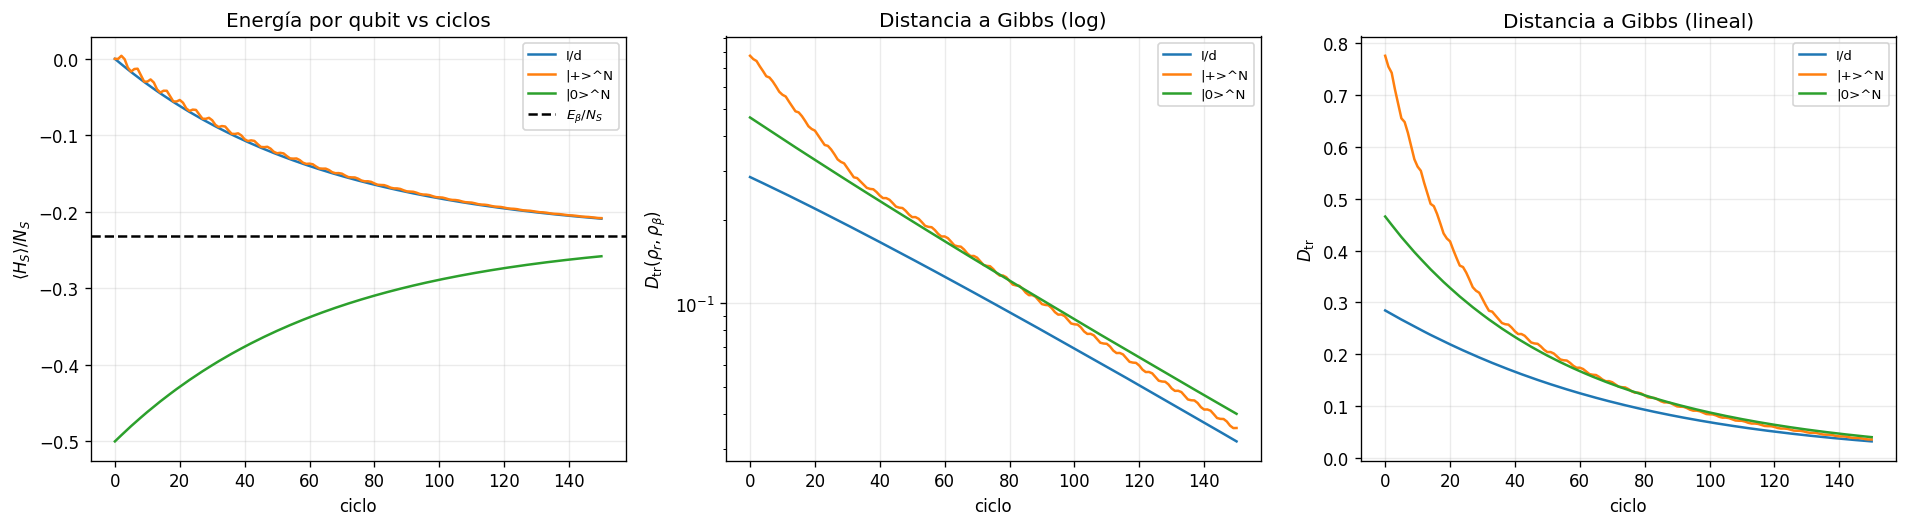

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
steps = np.arange(base_nonint_params["n_cycles"] + 1)

for name, rho0 in initial_states.items():
    out = run_nonint_case(base_nonint_params, rho0=rho0, compute_fp=False)
    res = out["res"]
    rho_g = out["rho_g"]
    dists = [trace_distance_dm(rho, rho_g) for rho in res["rhos"]]

    axes[0].plot(steps, np.array(res["energies"]) / N_S_default, label=name)
    axes[1].plot(steps, dists, label=name)
    axes[2].plot(steps, dists, label=name)

axes[0].axhline(out["Eg"] / N_S_default, ls="--", color="k", label=r"$E_\beta / N_S$")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$\langle H_S \rangle / N_S$")
axes[0].set_title("Energía por qubit vs ciclos")

axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho_r, \rho_\beta)$")
axes[1].set_title("Distancia a Gibbs (log)")
axes[1].set_yscale("log")

axes[2].set_xlabel("ciclo")
axes[2].set_ylabel(r"$D_{\rm tr}$")
axes[2].set_title("Distancia a Gibbs (lineal)")

for ax in axes:
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### A.1.2 Caso detallado desde $\rho_0 = I/d$

Mostramos las energías por qubit superpuestas: la simetría qubit a qubit del modelo NI implica que las trayectorias deben ser indistinguibles.


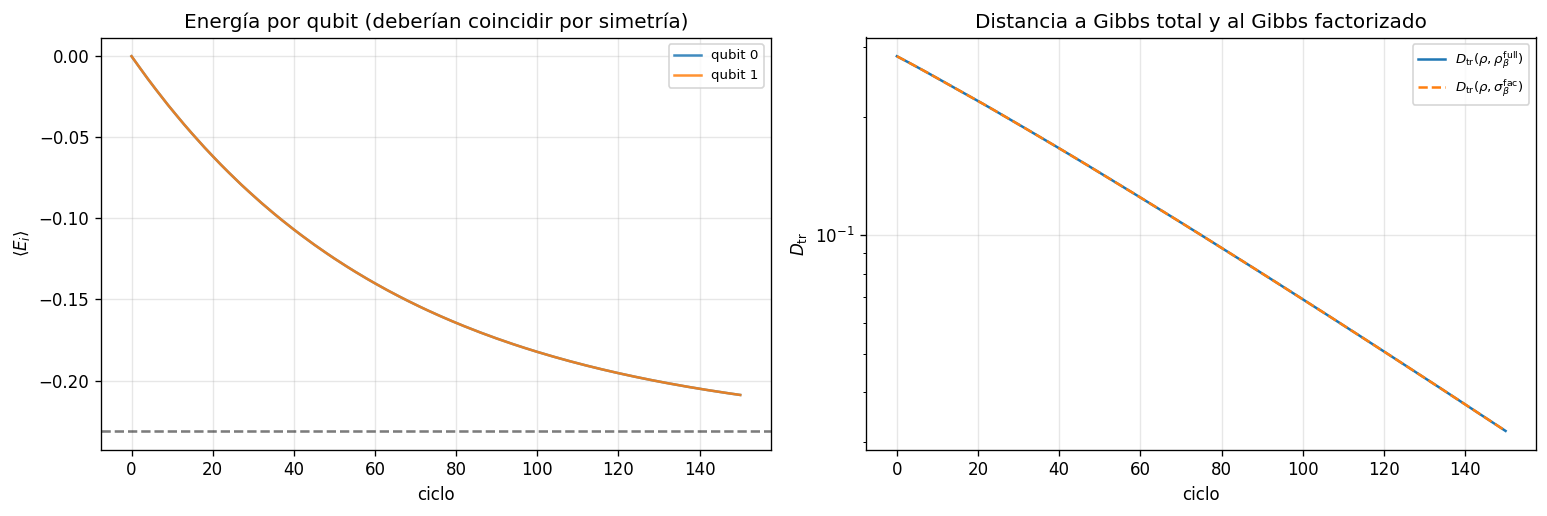

,E_fp_per_qubit,E_beta_per_qubit,|E_fp - E_beta|/N_S,"D_tr(fp, full)","D_tr(fp, fac)",I(A:Abar)_fp
0,-0.231636,-0.231059,0.000578,0.001151,0.001151,0.0


In [6]:
rho0_mm = maximally_mixed(N_S_default)

out_mm = run_nonint_case(base_nonint_params, rho0=rho0_mm, compute_fp=True, fp_mode="superop")

energies_per_q = np.array([
    per_qubit_energy(rho, n_sys=N_S_default, g=base_nonint_params["g"])
    for rho in out_mm["res"]["rhos"]
])

sigma_fac_ref = factorized_gibbs(N_S_default, g=base_nonint_params["g"], beta=base_nonint_params["beta"])
E_beta_per_q = per_qubit_energy(sigma_fac_ref, n_sys=N_S_default, g=base_nonint_params["g"])

steps = np.arange(out_mm["res"]["energies"].size)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for i in range(N_S_default):
    axes[0].plot(steps, energies_per_q[:, i], label=f"qubit {i}", alpha=0.85)
for i in range(N_S_default):
    axes[0].axhline(E_beta_per_q[i], ls="--", color="k", alpha=0.3)
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$\langle E_i \rangle$")
axes[0].set_title("Energía por qubit (deberían coincidir por simetría)")
axes[0].legend(fontsize=8)

dists_full = [trace_distance_dm(r, out_mm["rho_g"]) for r in out_mm["res"]["rhos"]]
dists_fac  = [trace_distance_dm(r, sigma_fac_ref) for r in out_mm["res"]["rhos"]]
axes[1].plot(steps, dists_full, label=r"$D_{\rm tr}(\rho, \rho_\beta^{\rm full})$")
axes[1].plot(steps, dists_fac, "--", label=r"$D_{\rm tr}(\rho, \sigma_\beta^{\rm fac})$")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$D_{\rm tr}$")
axes[1].set_title("Distancia a Gibbs total y al Gibbs factorizado")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

df_summary = pd.DataFrame([{
    "E_fp_per_qubit":       out_mm["Efp"] / N_S_default,
    "E_beta_per_qubit":     out_mm["Eg"] / N_S_default,
    "|E_fp - E_beta|/N_S":  abs(out_mm["Efp"] - out_mm["Eg"]) / N_S_default,
    "D_tr(fp, full)":       trace_distance_dm(out_mm["rho_fp"], out_mm["rho_g"]),
    "D_tr(fp, fac)":        trace_distance_dm(out_mm["rho_fp"], sigma_fac_ref),
    "I(A:Abar)_fp":         mutual_information_halves(out_mm["rho_fp"], N_S_default),
}])
display(df_summary.round(8))

## A.2 Operadores de acoplo $A_S, A_B$

Como $H_S = -(g/2)\sum_i Z_i$ es diagonal en la base computacional, el comportamiento del canal depende de cómo se relaciona $A_S$ con $Z$:

- $A_S = Y$ (anticonmuta con $Z$) — induce transiciones $|0\rangle \leftrightarrow |1\rangle$ en cada qubit y termaliza poblaciones.
- $A_S = Z$ — conmuta con $H_S$, no transfiere energía al baño y solo dephasea coherencias en base de energía.
- $A_S = (Z + Y)/\sqrt{2}$ (`ZYmix`, default del `base_nonint_params`) — combina ambos efectos y es la opción razonable.

La comparación reproduce el resultado de NB01 (traza energía/$N_S$, coherencia total y bias en log para los tres operadores), confirmando que el canal NI es single-spin replicado $N_S$ veces.

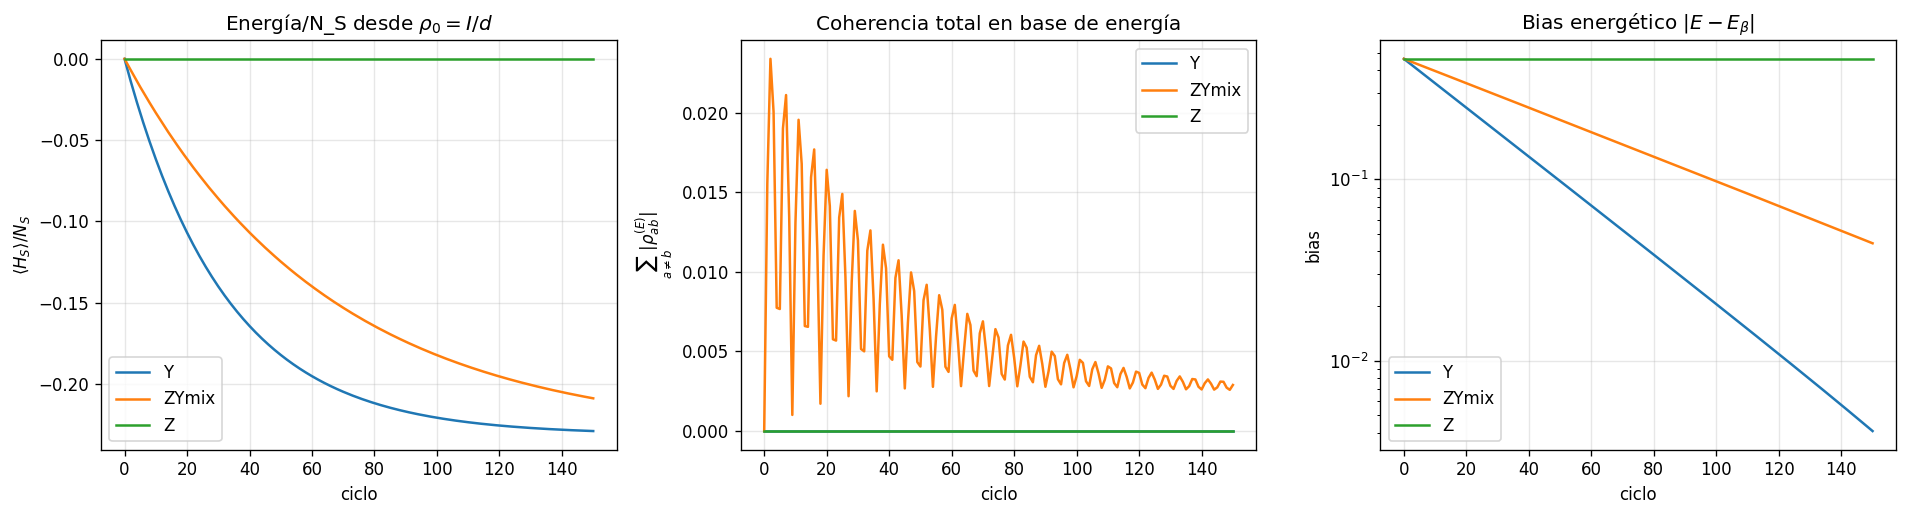

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ops = ["Y", "ZYmix", "Z"]

for op in ops:
    p = dict(base_nonint_params, sys_A=op)
    out = run_nonint_case(p, rho0=maximally_mixed(N_S_default), compute_fp=True, fp_mode="superop")

    axes[0].plot(np.array(out["res"]["energies"]) / N_S_default, label=op)

    coh_traj = np.array([
        coherence_norm_in_energy_basis(rho, out["Hs"], norm="l1")
        for rho in out["res"]["rhos"]
    ])
    axes[1].plot(coh_traj, label=op)

    bias = np.abs(np.array(out["res"]["energies"]) - out["Eg"])
    axes[2].plot(bias, label=op)

axes[0].set_title(r"Energía/N_S desde $\rho_0 = I/d$")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$\langle H_S \rangle / N_S$")
axes[0].legend()

axes[1].set_title("Coherencia total en base de energía")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$\sum_{a\neq b} |\rho^{(E)}_{ab}|$")
axes[1].legend()

axes[2].set_title(r"Bias energético $|E - E_\beta|$")
axes[2].set_xlabel("ciclo")
axes[2].set_ylabel("bias")
axes[2].set_yscale("log")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### A.2.2 Acoplos heterogéneos: un operador distinto por qubit

El punto anterior reproduce el comportamiento de single-spin replicado $N_S$ veces. 
La pregunta específica de $N_S > 1$ es: ¿el canal factoriza de verdad qubit por 
qubit, o hay acoplamientos cruzados no deseados?

Para probarlo aplicamos **distintos $A_S$ a distintos qubits**: por ejemplo `Y` al 
qubit 0 y `Z` al qubit 1. La predicción del canal factorizado es radical: el qubit 
0 debe termalizar a $\langle E_0 \rangle \to -\tfrac{g}{2}\tanh(\beta g/2)$ (Gibbs 
de single-spin) mientras que el qubit 1 debe quedarse plano en 
$\langle E_1 \rangle = 0$ (porque Z conmuta con $H_S$ y no transfiere energía). 
Si el canal tuviera acoplos cruzados, esta separación no sería limpia.

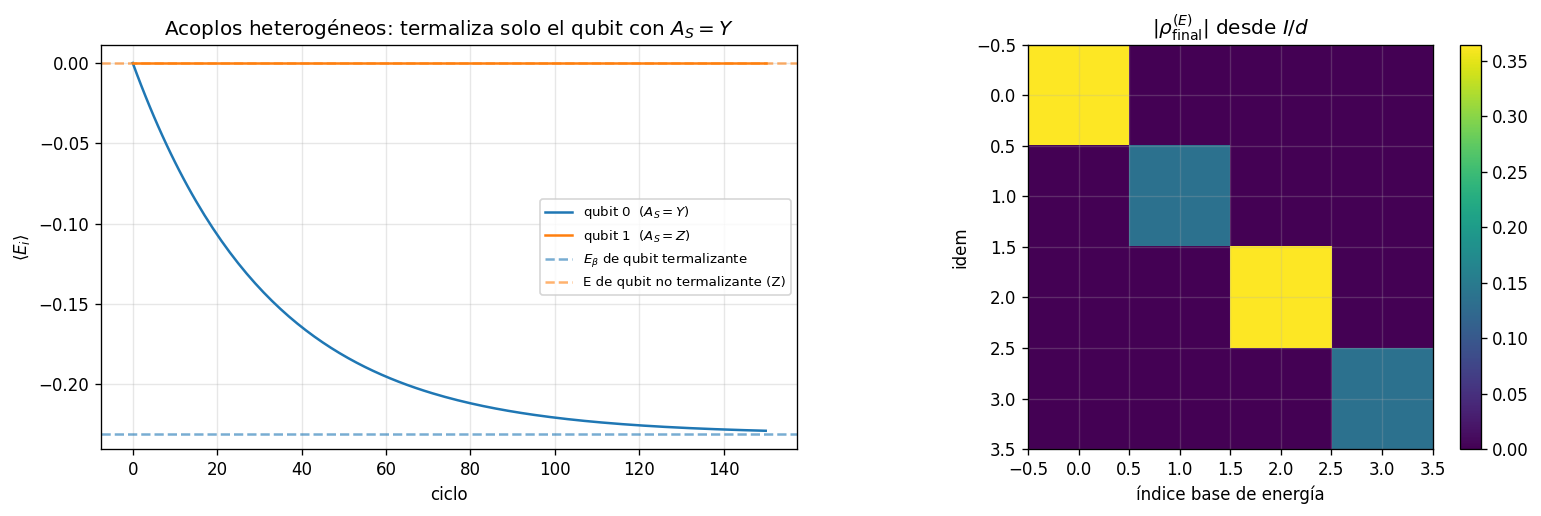

Predicción qubit termalizante (Y): E_i = -0.231059
Medido qubit 0 (Y):                E_0 = -0.229017
Predicción qubit no termalizante (Z): E_i = 0.0
Medido qubit 1 (Z):                   E_1 = -0.000000


In [3]:
# A.2.2 — acoplos heterogéneos por qubit.
# build_nonint_cfg toma sys_A como str y lo replica para todos los qubits.
# Para heterogéneo tenemos que llamar a build_nonint_cfg directo con coupling_specs
# manuales. Hacemos una variante minimalista aquí para no tocar el módulo.

from tfm_shared.core import ProtocolConfig, default_bath_terms
from tfm_single_spin.model import one_qubit_pauli_terms

def build_nonint_cfg_heterogeneous(sys_As, bath_A="Y", **base_kwargs):
    """sys_As es una lista de strings de longitud n_sys, uno por qubit."""
    n_sys = len(sys_As)
    bath_terms_q0 = one_qubit_pauli_terms(bath_A)
    coupling_specs = []
    for i, op_i in enumerate(sys_As):
        sys_terms_q0 = one_qubit_pauli_terms(op_i)
        sys_terms_i  = [(c, {i: list(ops.values())[0]}) for (c, ops) in sys_terms_q0]
        bath_terms_i = [(c, {i: list(ops.values())[0]}) for (c, ops) in bath_terms_q0]
        coupling_specs.append({"sys_terms": sys_terms_i, "bath_terms": bath_terms_i})

    return ProtocolConfig(
        n_sys=n_sys, n_bath=n_sys,
        system_terms=[(-0.5 * base_kwargs["g"], {i: "Z"}) for i in range(n_sys)],
        bath_terms=default_bath_terms(n_sys, h=base_kwargs["h"]),
        coupling_specs=coupling_specs,
        beta=base_kwargs["beta"], h_filter=base_kwargs["h"],
        theta=base_kwargs["theta"], delta=base_kwargs["delta"],
        MT=base_kwargs["MT"], n_cycles=base_kwargs["n_cycles"],
        randomize=base_kwargs.get("randomize", False),
        randomization_lambda=base_kwargs.get("randomization_lambda", 0.0),
        seed=base_kwargs.get("seed", 1234),
        rewind=base_kwargs.get("rewind", False),
    )

# Caso: qubit 0 acoplado con Y (termalizante), qubit 1 con Z (solo dephasea)
sys_As_hetero = ["Y", "Z"]
base_kw = {k: base_nonint_params[k] for k in
           ["g","h","beta","theta","delta","MT","n_cycles"]}
cfg_het = build_nonint_cfg_heterogeneous(sys_As_hetero, bath_A="Y", **base_kw)

from tfm_shared.core import run_protocol_case
out_het = run_protocol_case(cfg_het, rho0=maximally_mixed(N_S_default),
                            compute_fp=True, fp_mode="superop")

# Energías por qubit a lo largo de la trayectoria
E_per_q = np.array([
    per_qubit_energy(rho, n_sys=N_S_default, g=base_nonint_params["g"])
    for rho in out_het["res"]["rhos"]
])

# Referencias: Gibbs single-spin (qubit aislado a beta=1) y "cero" (qubit sin cambio)
g_val, beta_val = base_nonint_params["g"], base_nonint_params["beta"]
E_gibbs_single = -0.5 * g_val * np.tanh(beta_val * g_val / 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for i, op_i in enumerate(sys_As_hetero):
    axes[0].plot(E_per_q[:, i], label=f"qubit {i}  ($A_S={op_i}$)")
axes[0].axhline(E_gibbs_single, ls="--", color="tab:blue", alpha=0.6,
                label=r"$E_\beta$ de qubit termalizante")
axes[0].axhline(0.0, ls="--", color="tab:orange", alpha=0.6,
                label="E de qubit no termalizante (Z)")
axes[0].set_xlabel("ciclo"); axes[0].set_ylabel(r"$\langle E_i \rangle$")
axes[0].set_title("Acoplos heterogéneos: termaliza solo el qubit con $A_S = Y$")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Punto fijo en base de energía (debe ser casi diagonal y con valores predecibles)
rho_final_het = out_het["res"]["rhos"][-1]
_, rho_final_e = energy_basis_matrix(rho_final_het, out_het["Hs"])

im = axes[1].imshow(np.abs(rho_final_e), cmap="viridis")
axes[1].set_title(r"$|\rho_{\rm final}^{(E)}|$ desde $I/d$")
axes[1].set_xlabel("índice base de energía"); axes[1].set_ylabel("idem")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

# Tabla numérica
print(f"Predicción qubit termalizante (Y): E_i = {E_gibbs_single:.6f}")
print(f"Medido qubit 0 (Y):                E_0 = {E_per_q[-1, 0]:.6f}")
print(f"Predicción qubit no termalizante (Z): E_i = 0.0")
print(f"Medido qubit 1 (Z):                   E_1 = {E_per_q[-1, 1]:.6f}")

El resultado confirma que la thermalización es local y selectiva. El qubit acoplado con $A_S=Y$ intercambia energía con el baño y se aproxima a su valor térmico, mientras que el qubit acoplado con $A_S=Z$ conserva sus poblaciones porque $[Z,H_S]=0$. El estado final desde $I/d$ es compatible con $\rho_\beta\otimes I/2$: un qubit thermalizado y el otro no thermalizado. Esto descarta thermalización cruzada espuria en el modelo no interactuante.

## A.3 Escalado $\theta^2$ — resultado central del paper

Verificamos que el bias del punto fijo escala como $\theta^2$ también para $N_S > 1$. Como cada qubit es independiente, esperamos *exactamente* el mismo escalado que en single-spin (sin amplificación ni atenuación con $N_S$).


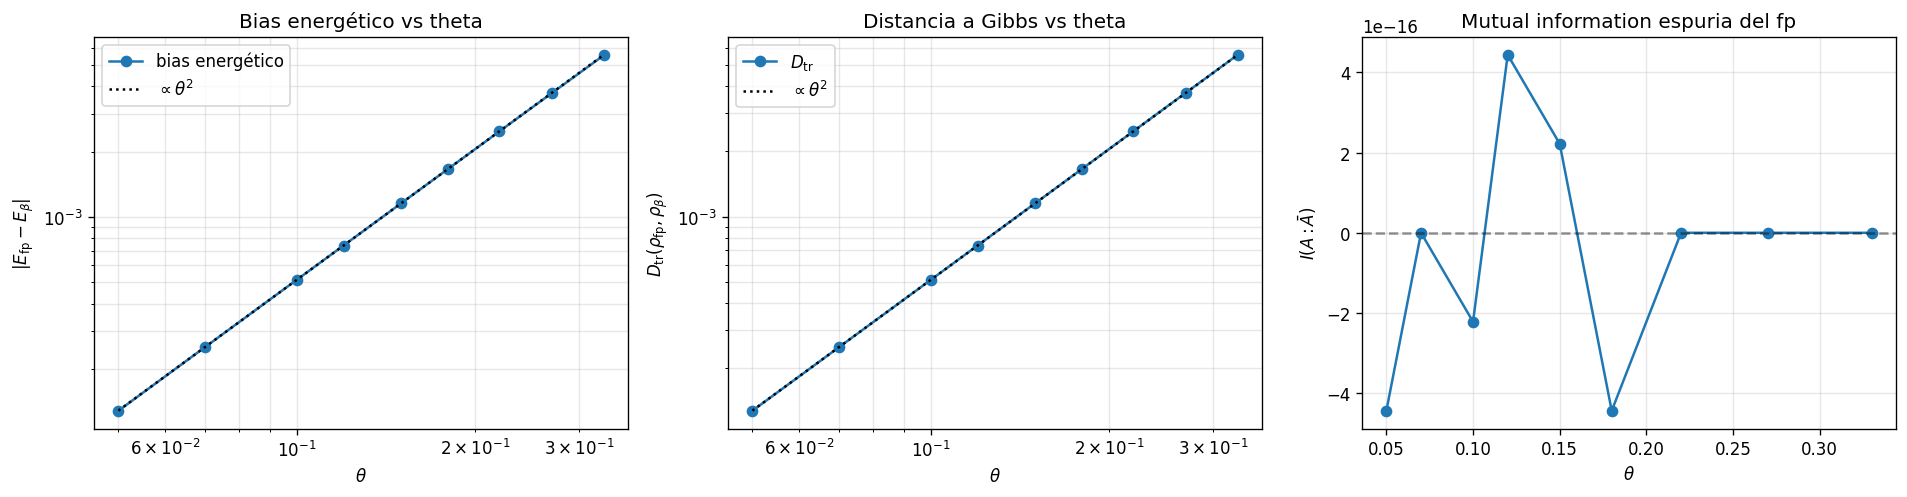

,theta,theta2,E_bias,Dtr_fp,I_mutual
0,0.05,0.0025,0.000128,0.000128,-0.0
1,0.07,0.0049,0.000252,0.000250,0.0
2,0.10,0.0100,0.000514,0.000511,-0.0
3,0.12,0.0144,0.000740,0.000737,0.0
4,0.15,0.0225,0.001156,0.001151,0.0
5,0.18,0.0324,0.001664,0.001659,-0.0
6,0.22,0.0484,0.002484,0.002478,0.0
7,0.27,0.0729,0.003735,0.003733,0.0
8,0.33,0.1089,0.005562,0.005573,0.0


In [8]:
theta_grid = np.array([0.05, 0.07, 0.10, 0.12, 0.15, 0.18, 0.22, 0.27, 0.33])

rows = []
for th in theta_grid:
    p = dict(base_nonint_params, theta=float(th))
    out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                          compute_fp=True, fp_mode="superop")
    rows.append({
        "theta":     float(th),
        "theta2":    float(th**2),
        "E_bias":    float(abs(out["Efp"] - out["Eg"])),
        "Dtr_fp":    float(trace_distance_dm(out["rho_fp"], out["rho_g"])),
        "I_mutual":  float(mutual_information_halves(out["rho_fp"], N_S_default)),
    })

df_th = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].loglog(df_th["theta"], df_th["E_bias"], "o-", label="bias energético")
axes[0].loglog(df_th["theta"],
               df_th["E_bias"].iloc[2] * (df_th["theta"]/df_th["theta"].iloc[2])**2,
               "k:", label=r"$\propto\theta^2$")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel(r"$|E_{\rm fp} - E_\beta|$")
axes[0].set_title("Bias energético vs theta")
axes[0].legend()

axes[1].loglog(df_th["theta"], df_th["Dtr_fp"], "o-", label=r"$D_{\rm tr}$")
axes[1].loglog(df_th["theta"],
               df_th["Dtr_fp"].iloc[2] * (df_th["theta"]/df_th["theta"].iloc[2])**2,
               "k:", label=r"$\propto\theta^2$")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel(r"$D_{\rm tr}(\rho_{\rm fp}, \rho_\beta)$")
axes[1].set_title("Distancia a Gibbs vs theta")
axes[1].legend()

axes[2].plot(df_th["theta"], df_th["I_mutual"], "o-")
axes[2].axhline(0, ls="--", color="k", alpha=0.4)
axes[2].set_xlabel(r"$\theta$")
axes[2].set_ylabel(r"$I(A:\bar A)$")
axes[2].set_title(r"Mutual information espuria del fp")

for ax in axes:
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

display(df_th.round(8))

 En el régimen perturbativo, el bias y la distancia traza decaen como $\theta^2$ con la misma constante que en single-spin. La mutual information del punto fijo se mantiene microscópica (numéricamente compatible con cero) — el protocolo no introduce correlaciones espurias entre qubits, lo cual es la propiedad estructural que separa NI del caso interactuante.

## A.4 Barridos mínimos: parámetros, ventana temporal y resonancias heredadas

En el modelo no interactuante el canal factoriza qubit a qubit. Por tanto, no tiene sentido repetir todos los análisis de single spin con el mismo nivel de detalle. En esta sección solo conservamos los barridos que aportan información específica para $N_S>1$:

1. comprobar que los parámetros físicos producen la misma dependencia intensiva por qubit;
2. verificar que el sesgo sigue controlado por $\theta$;
3. localizar las resonancias en la ventana temporal $T=M_T\delta$;
4. confirmar que las resonancias coinciden con las de single spin cuando se normaliza la energía por qubit.

El objetivo de A.4 no es reoptimizar el protocolo, sino demostrar que el modelo no interactuante hereda el comportamiento single-spin de forma factorizada.

### A.4.1 Barridos 1D de parámetros

Hacemos un barrido rápido de $\beta$, $\theta$, $h$, $g$, $\delta$ y $M_T$. La magnitud representada es intensiva, $\langle H_S\rangle/N_S$, para poder comparar directamente con single spin y con sistemas de mayor tamaño. En un modelo no interactuante, las curvas deben reproducir el comportamiento single-spin sin generar nuevas escalas colectivas.

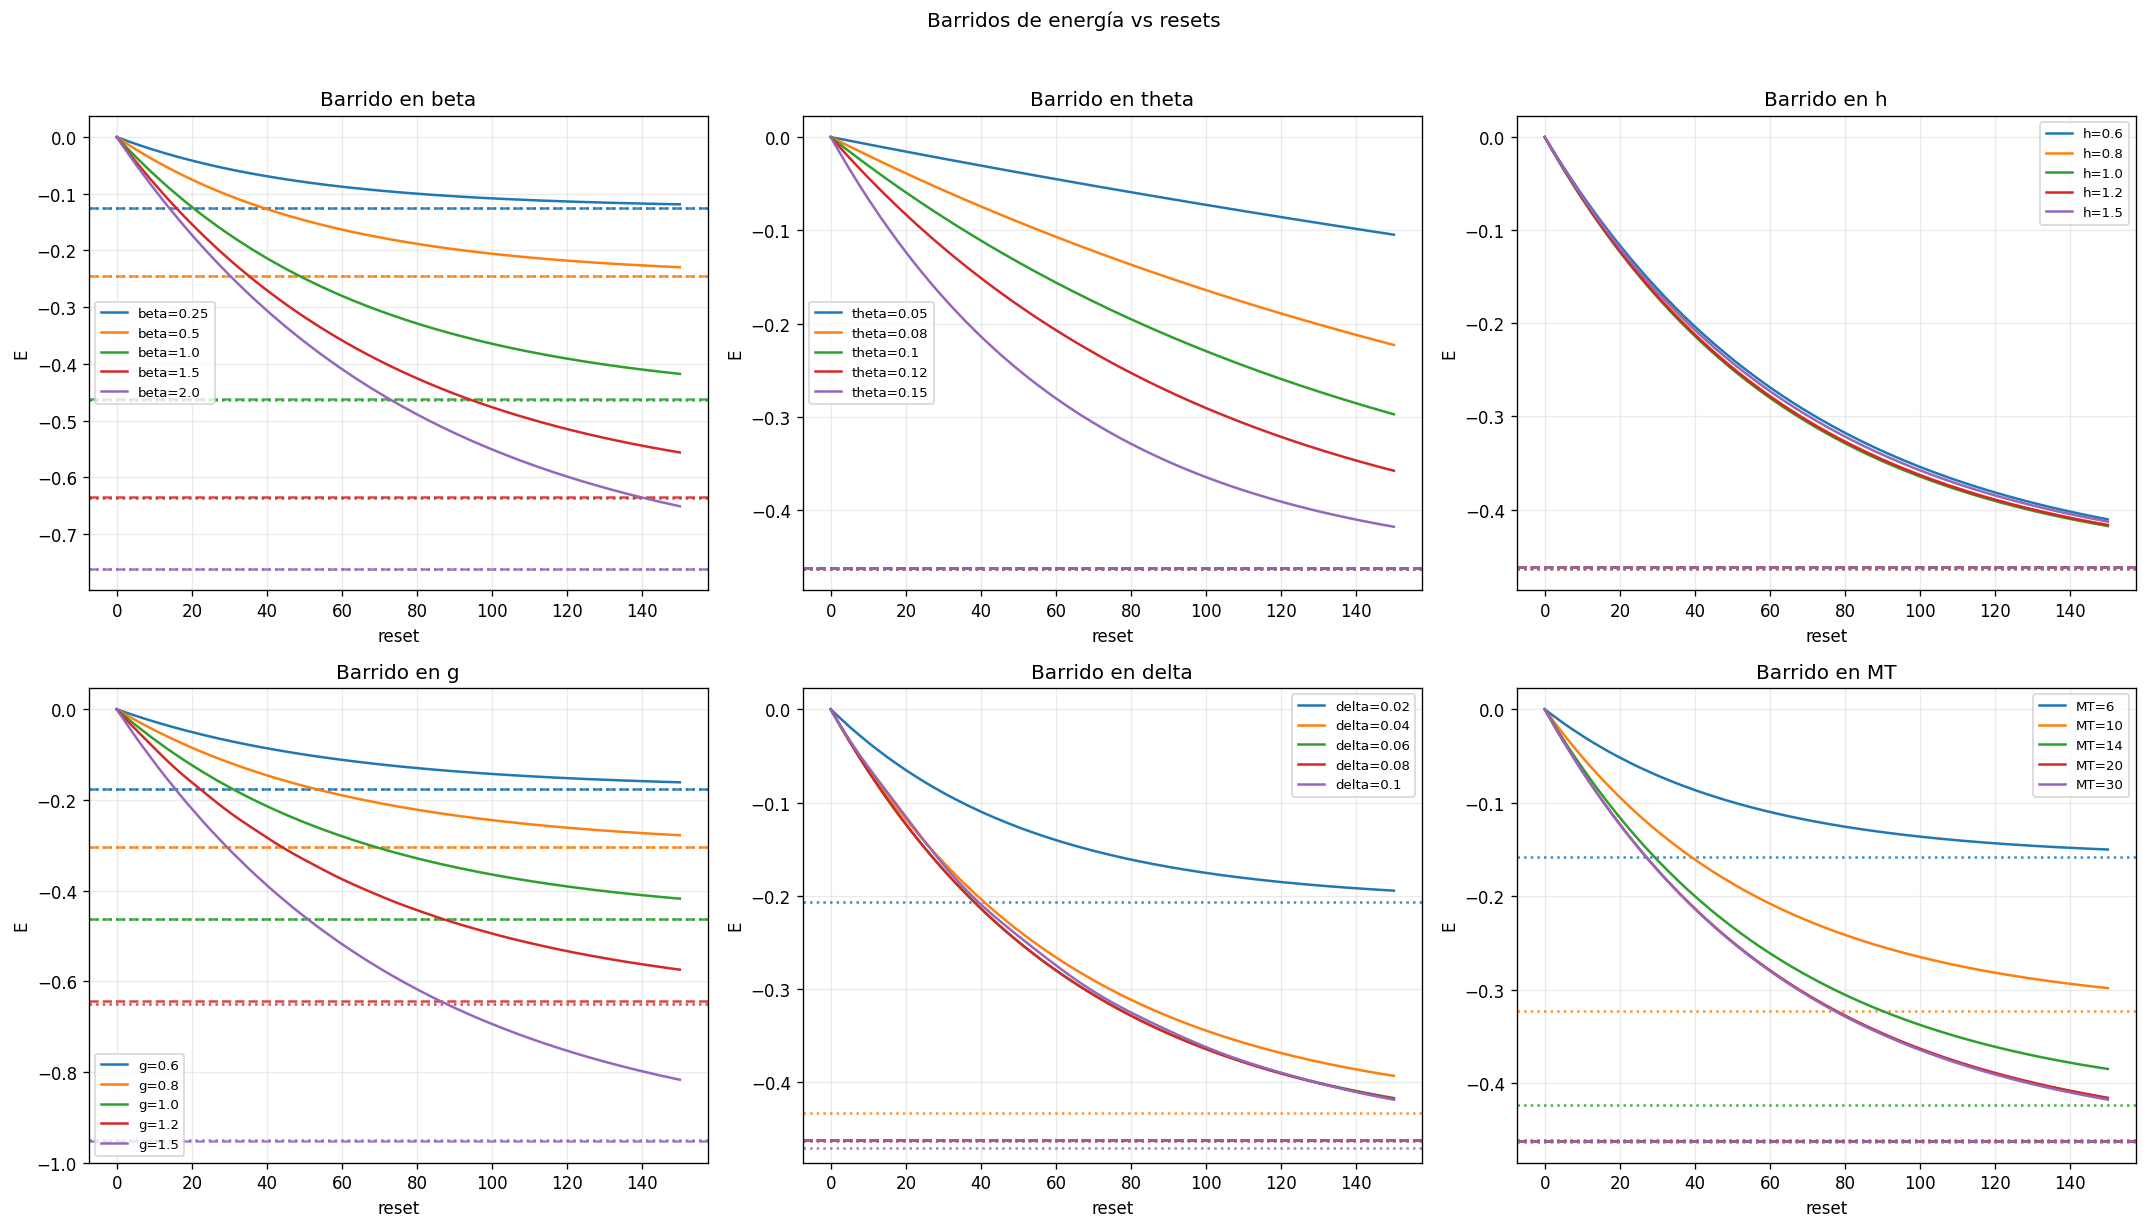

TABLAS RESUMEN DE BARRIDOS

--- Sweep: beta ---


,beta,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.25,-0.118627,-0.124353,-0.124642,0.005726,0.000289,0.999983,0.003214,1.000000,0.000214
1,0.50,-0.229577,-0.244919,-0.245572,0.015341,0.000654,0.999875,0.009498,1.000000,0.000539
2,1.00,-0.417749,-0.462117,-0.463273,0.044368,0.001156,0.998779,0.031956,0.999998,0.001151
3,1.50,-0.556284,-0.635149,-0.636364,0.078865,0.001215,0.995176,0.062941,0.999997,0.001500
4,2.00,-0.651223,-0.761594,-0.762649,0.110371,0.001055,0.987801,0.094193,0.999997,0.001700



--- Sweep: theta ---


,theta,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.05,-0.104624,-0.462117,-0.462245,0.357493,0.000128,0.931515,0.229398,1.000000,0.000128
1,0.08,-0.222840,-0.462117,-0.462446,0.239278,0.000329,0.967761,0.160615,1.000000,0.000327
2,0.10,-0.297176,-0.462117,-0.462631,0.164941,0.000514,0.984147,0.113784,1.000000,0.000511
3,0.12,-0.357718,-0.462117,-0.462857,0.104399,0.000740,0.993455,0.073602,0.999999,0.000737
4,0.15,-0.417749,-0.462117,-0.463273,0.044368,0.001156,0.998779,0.031956,0.999998,0.001151



--- Sweep: h ---


...

,g,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.6,-0.161046,-0.174788,-0.174890,0.013742,0.000102,0.999715,0.014658,1.000000,0.000209
1,0.8,-0.277844,-0.303959,-0.304318,0.026115,0.000359,0.999386,0.022261,1.000000,0.000465
2,1.0,-0.417749,-0.462117,-0.463273,0.044368,0.001156,0.998779,0.031956,0.999998,0.001151
3,1.2,-0.574378,-0.644459,-0.650314,0.070081,0.005854,0.997689,0.044164,0.999970,0.005050
4,1.5,-0.817343,-0.952723,-0.949372,0.135380,0.003352,0.993747,0.071784,0.999991,0.002793



--- Sweep: delta ---


,delta,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,0.02,-0.194550,-0.462117,-0.206573,0.267568,0.255544,0.960183,0.177710,0.963491,0.170493
1,0.04,-0.393291,-0.462117,-0.433374,0.068826,0.028743,0.997102,0.049135,0.999483,0.020813
2,0.06,-0.417128,-0.462117,-0.462158,0.044989,0.000041,0.998745,0.032390,1.000000,0.000471
3,0.08,-0.417749,-0.462117,-0.463273,0.044368,0.001156,0.998779,0.031956,0.999998,0.001151
4,0.10,-0.418902,-0.462117,-0.470428,0.043215,0.008310,0.998798,0.031672,0.999917,0.008200



--- Sweep: MT ---


,MT,Efinal,Egibbs,Efp,|Efinal-Eg|,|Efp-Eg|,"F(final,Gibbs)","Dtr(final,Gibbs)","F(fp,Gibbs)","Dtr(fp,Gibbs)"
0,6,-0.150030,-0.462117,-0.158179,0.312087,0.303938,0.946839,0.203804,0.949408,0.199102
1,10,-0.298390,-0.462117,-0.322661,0.163728,0.139456,0.984371,0.112994,0.988527,0.097090
2,14,-0.384928,-0.462117,-0.423413,0.077189,0.038704,0.996371,0.054943,0.999068,0.027925
3,20,-0.415767,-0.462117,-0.460444,0.046350,0.001674,0.998669,0.033353,0.999998,0.001326
4,30,-0.417749,-0.462117,-0.463273,0.044368,0.001156,0.998779,0.031956,0.999998,0.001151


In [5]:
# A.4.1 — barrido 1D de los seis parámetros, rejilla 2x3

sweep_map_nonint = {
    "beta":  [0.25, 0.5, 1.0, 1.5, 2.0],
    "theta": [0.05, 0.08, 0.10, 0.12, 0.15],
    "h":     [0.6, 0.8, 1.0, 1.2, 1.5],
    "g":     [0.6, 0.8, 1.0, 1.2, 1.5],
    "delta": [0.02, 0.04, 0.06, 0.08, 0.10],
    "MT":    [6, 10, 14, 20, 30],
}

tables_nonint = plot_energy_sweep_grid(
    run_nonint_case,
    base_nonint_params,
    sweep_map_nonint,
    rho0=maximally_mixed(N_S_default),
    figsize=(18, 10),
)

### A.4.2 Heatmaps físicos en $(\theta,\beta)$ y $(\theta,h)$

Reducimos los mapas 2D a dos planos físicamente informativos:

- $(\theta,\beta)$: comprueba que el sesgo perturbativo aumenta con $\theta$ y que la dependencia térmica se hereda qubit a qubit.
- $(\theta,h)$: explora la sensibilidad al gap del baño y a la posición del filtro espectral.

No repetimos aquí un barrido exhaustivo en $(\theta,\delta)$, porque esa dependencia ya se estudia de forma más clara mediante $T=M_T\delta$ y las resonancias temporales de A.4.3.

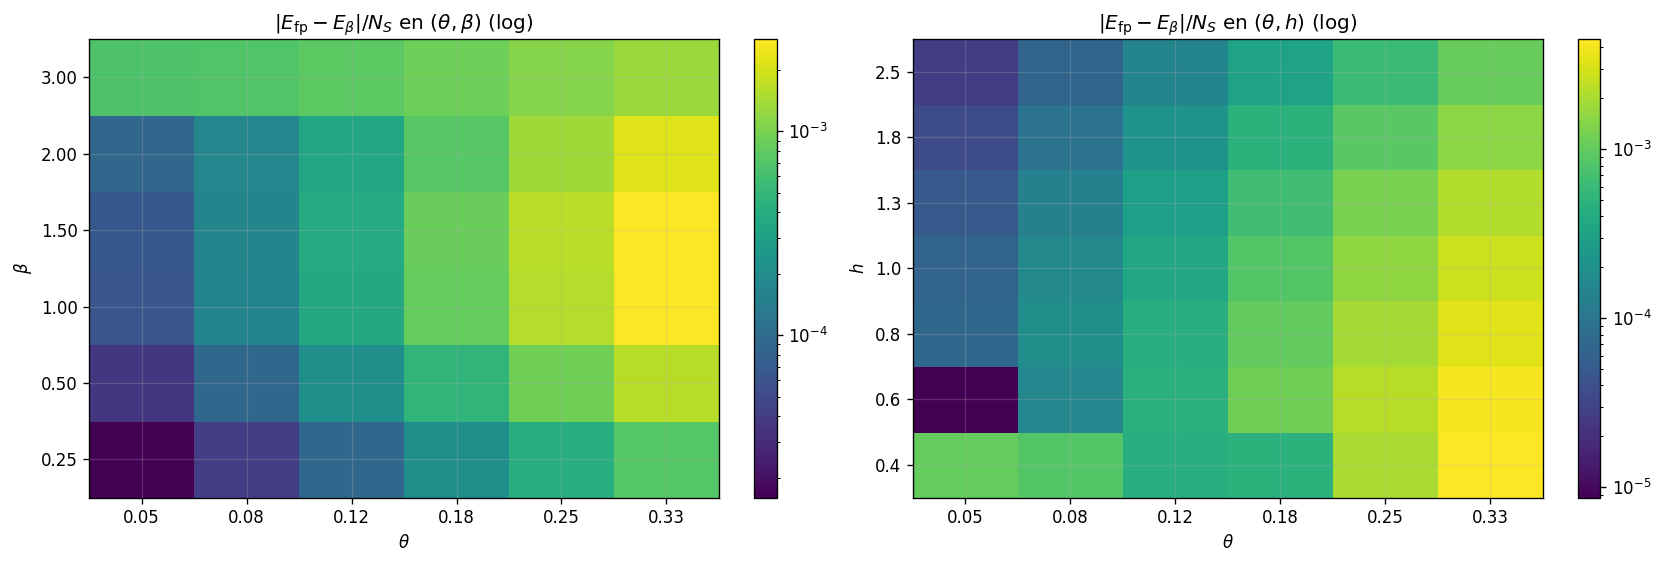

In [12]:
# A.4.2 — heatmaps (theta, beta) y (theta, h) en escala logarítmica
from matplotlib.colors import LogNorm

theta_grid_2d = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.33])
beta_grid_2d  = np.array([0.25, 0.5, 1.0, 1.5, 2.0, 3.0])
h_grid_2d     = np.array([0.4, 0.6, 0.8, 1.0, 1.3, 1.8, 2.5])

Z_tb = np.zeros((len(beta_grid_2d), len(theta_grid_2d)))
Z_th = np.zeros((len(h_grid_2d),    len(theta_grid_2d)))

for i, th in enumerate(theta_grid_2d):
    for j, b in enumerate(beta_grid_2d):
        p = dict(base_nonint_params, theta=float(th), beta=float(b))
        out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                              compute_fp=True, fp_mode="superop")
        Z_tb[j, i] = abs(out["Efp"] - out["Eg"]) / N_S_default
    for k, hv in enumerate(h_grid_2d):
        p = dict(base_nonint_params, theta=float(th), h=float(hv))
        out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                              compute_fp=True, fp_mode="superop")
        Z_th[k, i] = abs(out["Efp"] - out["Eg"]) / N_S_default

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

im0 = axes[0].imshow(
    Z_tb, aspect="auto", origin="lower",
    norm=LogNorm(vmin=max(Z_tb.min(), 1e-6), vmax=Z_tb.max()),
    cmap="viridis",
)
axes[0].set_xticks(range(len(theta_grid_2d)))
axes[0].set_xticklabels([f"{x:.2f}" for x in theta_grid_2d])
axes[0].set_yticks(range(len(beta_grid_2d)))
axes[0].set_yticklabels([f"{x:.2f}" for x in beta_grid_2d])
axes[0].set_xlabel(r"$\theta$"); axes[0].set_ylabel(r"$\beta$")
axes[0].set_title(r"$|E_{\rm fp}-E_\beta|/N_S$ en $(\theta,\beta)$ (log)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    Z_th, aspect="auto", origin="lower",
    norm=LogNorm(vmin=max(Z_th.min(), 1e-6), vmax=Z_th.max()),
    cmap="viridis",
)
axes[1].set_xticks(range(len(theta_grid_2d)))
axes[1].set_xticklabels([f"{x:.2f}" for x in theta_grid_2d])
axes[1].set_yticks(range(len(h_grid_2d)))
axes[1].set_yticklabels([f"{x:.1f}" for x in h_grid_2d])
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel(r"$h$")
axes[1].set_title(r"$|E_{\rm fp}-E_\beta|/N_S$ en $(\theta,h)$ (log)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout(); plt.show()

Los heatmaps muestran que el error se organiza principalmente por $\theta$, como en single spin. La dependencia con $\beta$ y $h$ modifica la escala de la señal térmica, pero no introduce estructuras colectivas nuevas. Esto es consistente con la factorización exacta del modelo no interactuante.

### A.4.2b Dependencia térmica: energía intensiva y error frente a $\beta$

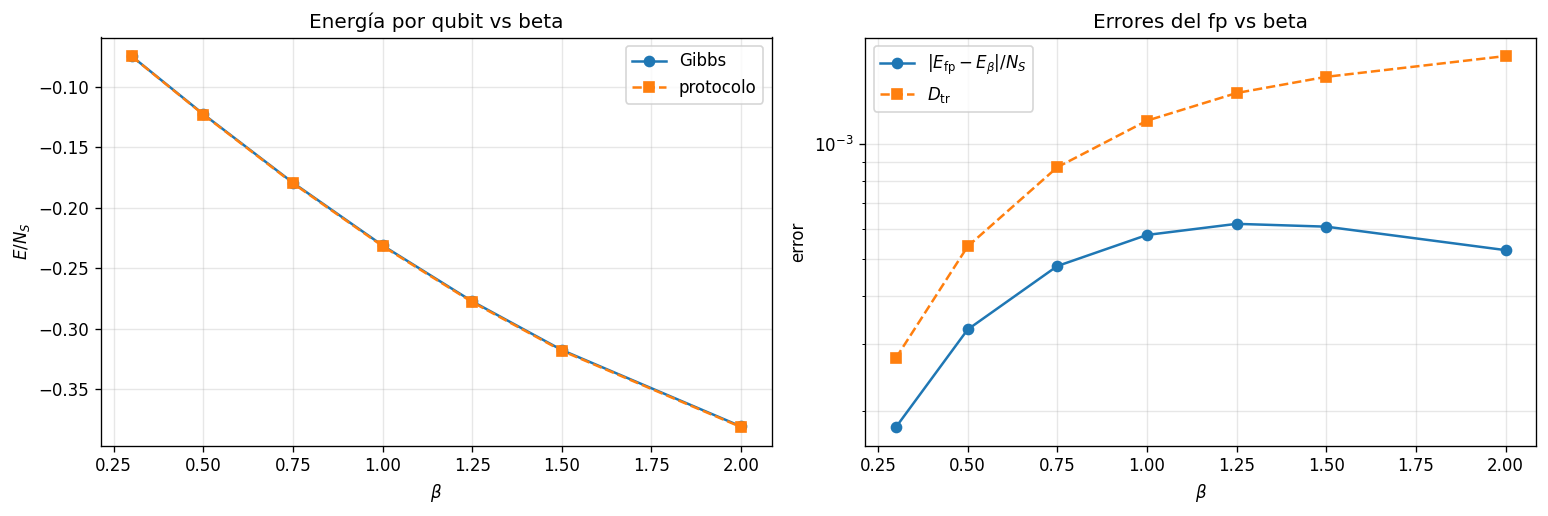

,beta,Egibbs/N_S,Efp/N_S,|E_fp - Eg|/N_S,Dtr_fp
0,0.30,-0.074443,-0.074624,0.000181,0.000275
1,0.50,-0.122459,-0.122786,0.000327,0.000539
2,0.75,-0.179179,-0.179658,0.000479,0.000870
3,1.00,-0.231059,-0.231636,0.000578,0.001151
4,1.25,-0.277300,-0.277918,0.000618,0.001360
5,1.50,-0.317574,-0.318182,0.000608,0.001500
6,2.00,-0.380797,-0.381324,0.000527,0.001700


In [9]:
beta_grid = np.array([0.3, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0])

rows = []
for b in beta_grid:
    p = dict(base_nonint_params, beta=float(b))
    out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                          compute_fp=True, fp_mode="superop")
    rows.append({
        "beta":  float(b),
        "Egibbs/N_S":  out["Eg"] / N_S_default,
        "Efp/N_S":     out["Efp"] / N_S_default,
        "|E_fp - Eg|/N_S": abs(out["Efp"] - out["Eg"]) / N_S_default,
        "Dtr_fp":      trace_distance_dm(out["rho_fp"], out["rho_g"]),
    })
df_beta = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(df_beta["beta"], df_beta["Egibbs/N_S"], "o-", label="Gibbs")
axes[0].plot(df_beta["beta"], df_beta["Efp/N_S"],    "s--", label="protocolo")
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel(r"$E/N_S$")
axes[0].set_title("Energía por qubit vs beta")
axes[0].legend()

axes[1].plot(df_beta["beta"], df_beta["|E_fp - Eg|/N_S"], "o-", label=r"$|E_{\rm fp} - E_\beta|/N_S$")
axes[1].plot(df_beta["beta"], df_beta["Dtr_fp"],          "s--", label=r"$D_{\rm tr}$")
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel("error")
axes[1].set_title("Errores del fp vs beta")
axes[1].set_yscale("log")
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()
display(df_beta.round(8))

El barrido en $\beta$ confirma que el protocolo reproduce la curva térmica intensiva $E(\beta)/N_S$ del modelo no interactuante. El error aumenta al bajar la temperatura, como es esperable porque el Gibbs se vuelve más polarizado y la preparación exige mayor precisión poblacional. Este resultado complementa los heatmaps de A.4.2 con una lectura unidimensional más directa.

### A.4.3 Ventana temporal: resonancias en $(\theta,M_T)$

El parámetro relevante de la discretización temporal es la ventana efectiva $T=M_T\delta$. Como el modelo no interactuante tiene la misma frecuencia de Bohr local que single spin, $\omega=g$, las resonancias aparecen cuando:

$$
T\omega = k\pi.
$$

El heatmap en $(\theta,M_T)$ permite distinguir ventanas resonantes, donde el protocolo se degrada, y valles inter-resonantes, donde el filtro temporal funciona mejor.

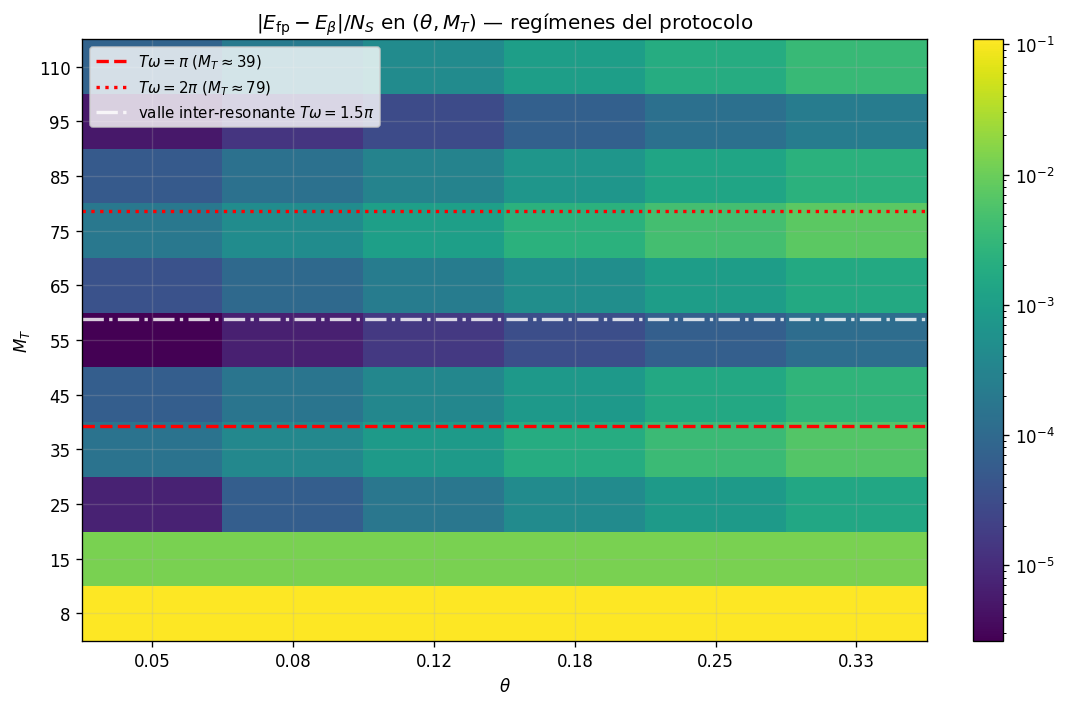

Primera resonancia   $T = \pi$  →  MT ≈ 39.3
Segunda resonancia   $T = 2\pi$ →  MT ≈ 78.5
Primer valle         $T = 1.5\pi$ →  MT ≈ 58.9


In [11]:
# A.4.3 — heatmap (MT, theta): visualiza regímenes resonantes vs limpios
from matplotlib.colors import LogNorm

MT_grid = np.array([8, 15, 25, 35, 45, 55, 65, 75, 85, 95, 110])
theta_grid_res = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.33])

Z_mt = np.zeros((len(MT_grid), len(theta_grid_res)))

for j, th in enumerate(theta_grid_res):
    for i, MT_v in enumerate(MT_grid):
        p = dict(base_nonint_params, theta=float(th), MT=int(MT_v),
                 n_cycles=200)
        out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                              compute_fp=True, fp_mode="superop")
        Z_mt[i, j] = abs(out["Efp"] - out["Eg"]) / N_S_default

# Calcular las líneas de resonancia T*omega = k*pi
# T = MT * delta, omega = g = 1
delta_used = base_nonint_params["delta"]
g_used     = base_nonint_params["g"]
MT_res1 = np.pi / (delta_used * g_used)            # primera resonancia
MT_res2 = 2 * np.pi / (delta_used * g_used)        # segunda resonancia

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    Z_mt, aspect="auto", origin="lower",
    norm=LogNorm(vmin=max(Z_mt.min(), 1e-6), vmax=Z_mt.max()),
    cmap="viridis",
    extent=[-0.5, len(theta_grid_res)-0.5, -0.5, len(MT_grid)-0.5],
)
ax.set_xticks(range(len(theta_grid_res)))
ax.set_xticklabels([f"{x:.2f}" for x in theta_grid_res])
ax.set_yticks(range(len(MT_grid)))
ax.set_yticklabels(MT_grid)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel(r"$M_T$")
ax.set_title(r"$|E_{\rm fp}-E_\beta|/N_S$ en $(\theta, M_T)$ — regímenes del protocolo")

# Superponer líneas de resonancia (interpoladas al índice del grid)
from numpy import interp
def mt_to_index(mt_val, mt_grid):
    return interp(mt_val, mt_grid, np.arange(len(mt_grid)))

y_res1 = mt_to_index(MT_res1, MT_grid)
y_res2 = mt_to_index(MT_res2, MT_grid)

ax.axhline(y_res1, color="red",  lw=2, ls="--",
           label=rf"$T\omega = \pi$ ($M_T \approx {MT_res1:.0f}$)")
ax.axhline(y_res2, color="red",  lw=2, ls=":",
           label=rf"$T\omega = 2\pi$ ($M_T \approx {MT_res2:.0f}$)")

# Marcar las valles
y_valle1 = mt_to_index(1.5 * np.pi / (delta_used * g_used), MT_grid)
ax.axhline(y_valle1, color="white", lw=2, ls="-.", alpha=0.8,
           label=r"valle inter-resonante $T\omega = 1.5\pi$")

ax.legend(loc="upper left", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()

print(f"Primera resonancia   $T = \\pi$  →  MT ≈ {MT_res1:.1f}")
print(f"Segunda resonancia   $T = 2\\pi$ →  MT ≈ {MT_res2:.1f}")
print(f"Primer valle         $T = 1.5\\pi$ →  MT ≈ {1.5*MT_res1:.1f}")

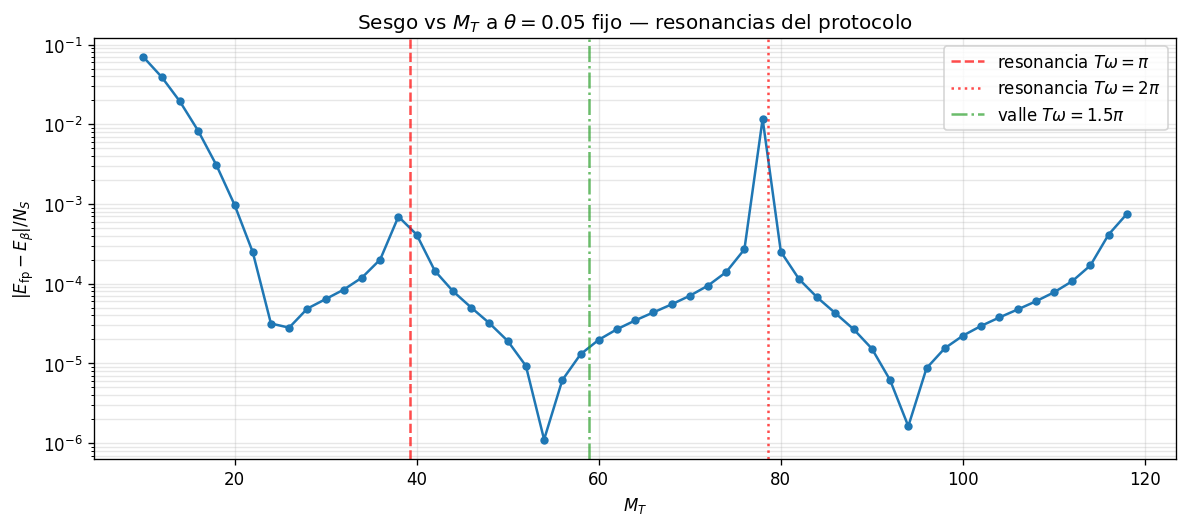

In [12]:
# A.4.3.b — barrido 1D de MT a theta fijo pequeño, para resaltar resonancias
MT_fine = np.arange(10, 120, 2)
theta_fixed = 0.05

bias_mt = []
for MT_v in MT_fine:
    p = dict(base_nonint_params, theta=theta_fixed, MT=int(MT_v),
             n_cycles=250)
    out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                          compute_fp=True, fp_mode="superop")
    bias_mt.append(abs(out["Efp"] - out["Eg"]) / N_S_default)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogy(MT_fine, bias_mt, "o-", ms=4)

ax.axvline(MT_res1, color="red",  ls="--", alpha=0.7,
           label=rf"resonancia $T\omega = \pi$")
ax.axvline(MT_res2, color="red",  ls=":", alpha=0.7,
           label=rf"resonancia $T\omega = 2\pi$")
ax.axvline(1.5 * MT_res1, color="tab:green", ls="-.", alpha=0.7,
           label=r"valle $T\omega = 1.5\pi$")

ax.set_xlabel(r"$M_T$"); ax.set_ylabel(r"$|E_{\rm fp}-E_\beta|/N_S$")
ax.set_title(rf"Sesgo vs $M_T$ a $\theta={theta_fixed}$ fijo — resonancias del protocolo")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

Las resonancias dependen de la ventana efectiva $T=M_T\delta$. En el modelo no interactuante no aparecen frecuencias colectivas nuevas: las ventanas resonantes son las mismas que en single spin, replicadas qubit a qubit. Por eso A.4.3 se interpreta como diagnóstico temporal, no como nueva física colectiva.

**Para los notebooks siguientes**: en Ising 1D y 2D aparecerán múltiples 
frecuencias $\omega_{ab}$ del sistema, lo que genera múltiples condiciones 
de resonancia. El patrón del heatmap $(\theta, M_T)$ se volverá más complejo 
—con varias bandas de resonancia superpuestas— y el valle óptimo será más 
estrecho. La elección $M_T$ tendrá que reoptimizarse caso por caso.

### A.4.4 Comparación con single spin: resonancias heredadas

En el modelo no interactuante con acoplos locales, el canal factoriza qubit a qubit. Por tanto, las transiciones efectivas que contribuyen al filtro son las locales, con frecuencia $\omega=g$, igual que en single spin. Las transiciones que requerirían invertir varios qubits simultáneamente no aparecen como nuevas frecuencias colectivas del canal factorizado.

Así, las resonancias temporales se esperan en los mismos valores que en NB01:

$$
M_T^{\rm res}=\frac{k\pi}{g\delta},\qquad k=1,2,3,\ldots
$$

Con $g=1$ y $\delta=0.08$, esto da $M_T\simeq39,79,118,\ldots$, independientemente de $N_S$. La comparación single-spin vs NI verifica precisamente esto: las bandas resonantes se heredan qubit a qubit. En modelos interactuantes, como Ising, el canal ya no factoriza y aparecen frecuencias adicionales; esa es la diferencia que se estudiará en NB03.

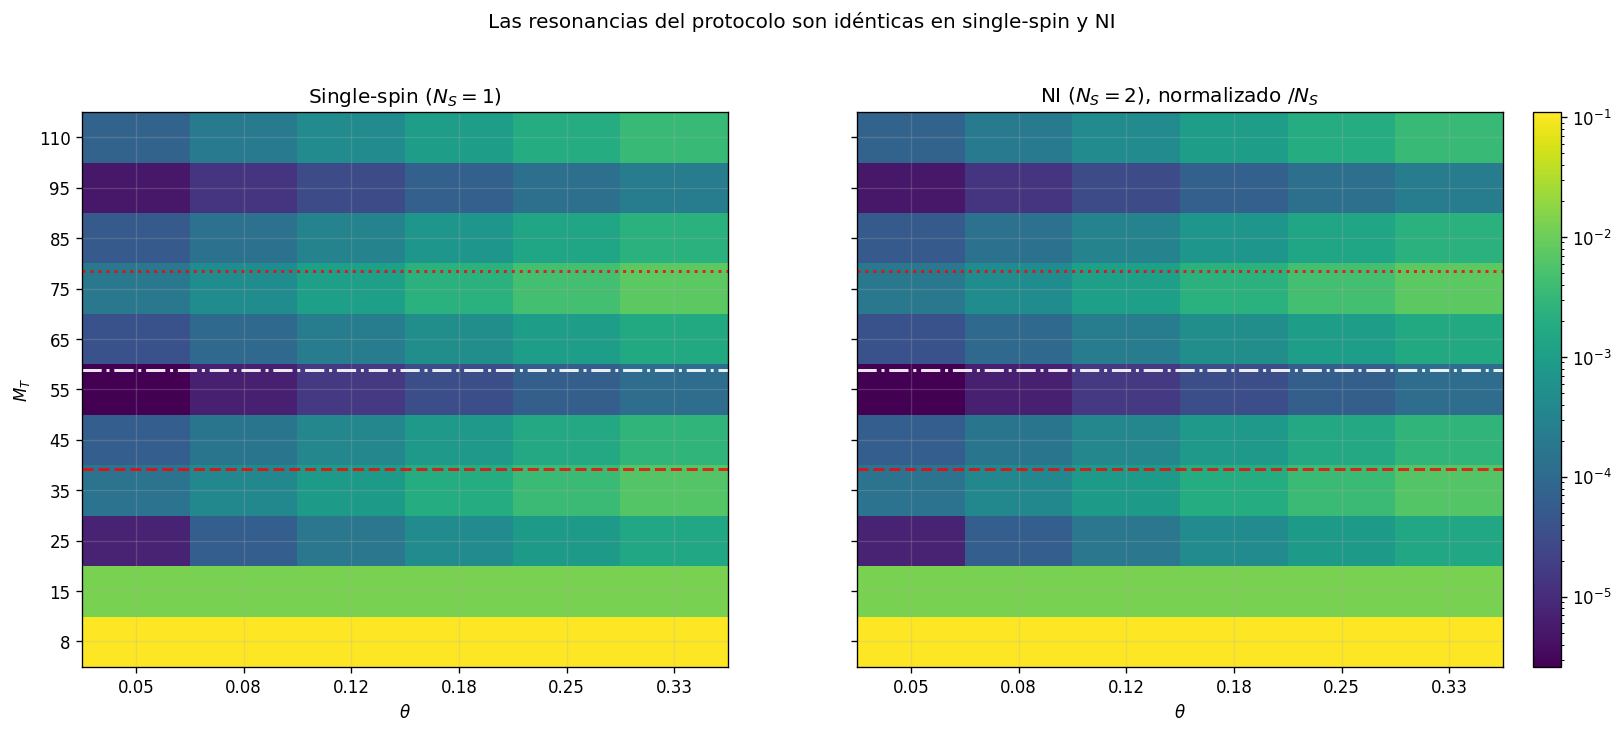

Max |Z_ss - Z_ni| = 5.614e-12
Mean |Z_ss - Z_ni| = 6.432e-13
Si ambos números son pequeños (≤10^-5), la factorización del canal NI
está confirmada empíricamente: las resonancias y el sesgo por qubit
son idénticos al caso single-spin.


In [14]:
# A.3.3 — comparación visual single-spin vs NI en el mismo heatmap
from tfm_single_spin.model import run_single_spin_case

base_single_params = dict(
    g=1.0,
    h=1.0,
    beta=1.0,
    theta=0.15,
    delta=0.08,
    MT=30,
    n_cycles=150,
    sys_A= "ZYmix",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    seed=1234,
    rewind=False,
)

MT_grid_cmp  = np.array([8, 15, 25, 35, 45, 55, 65, 75, 85, 95, 110])
theta_grid_cmp = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.33])

Z_ss = np.zeros((len(MT_grid_cmp), len(theta_grid_cmp)))
Z_ni = np.zeros((len(MT_grid_cmp), len(theta_grid_cmp)))

for j, th in enumerate(theta_grid_cmp):
    for i, MT_v in enumerate(MT_grid_cmp):
        # Single-spin
        p_ss = dict(base_single_params,
                    theta=float(th), MT=int(MT_v), n_cycles=200)
        out_ss = run_single_spin_case(p_ss, rho0=maximally_mixed(1),
                                       compute_fp=True, fp_mode="superop")
        Z_ss[i, j] = abs(out_ss["Efp"] - out_ss["Eg"])  # sin /N_S porque N_S=1

        # NI con N_S=2
        p_ni = dict(base_nonint_params,
                    theta=float(th), MT=int(MT_v), n_cycles=200)
        out_ni = run_nonint_case(p_ni, rho0=maximally_mixed(N_S_default),
                                  compute_fp=True, fp_mode="superop")
        Z_ni[i, j] = abs(out_ni["Efp"] - out_ni["Eg"]) / N_S_default

# Misma escala colorbar para ambos
v_min = min(Z_ss.min(), Z_ni.min())
v_max = max(Z_ss.max(), Z_ni.max())

# Posiciones resonantes
delta_used = base_single_params["delta"]
g_used     = base_single_params["g"]
MT_res1 = np.pi / (delta_used * g_used)
MT_res2 = 2 * np.pi / (delta_used * g_used)
MT_val1 = 1.5 * np.pi / (delta_used * g_used)

def mt_to_idx(mt_val): return interp(mt_val, MT_grid_cmp, np.arange(len(MT_grid_cmp)))
y_res1, y_res2, y_val1 = mt_to_idx(MT_res1), mt_to_idx(MT_res2), mt_to_idx(MT_val1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, Z, title in [
    (axes[0], Z_ss, r"Single-spin ($N_S = 1$)"),
    (axes[1], Z_ni, rf"NI ($N_S = {N_S_default}$), normalizado $/N_S$"),
]:
    im = ax.imshow(
        Z, aspect="auto", origin="lower",
        norm=LogNorm(vmin=max(v_min, 1e-6), vmax=v_max),
        cmap="viridis",
    )
    ax.set_xticks(range(len(theta_grid_cmp)))
    ax.set_xticklabels([f"{x:.2f}" for x in theta_grid_cmp])
    ax.set_yticks(range(len(MT_grid_cmp)))
    ax.set_yticklabels(MT_grid_cmp)
    ax.set_xlabel(r"$\theta$")
    ax.set_title(title)

    ax.axhline(y_res1, color="red",   lw=1.8, ls="--", alpha=0.8)
    ax.axhline(y_res2, color="red",   lw=1.8, ls=":",  alpha=0.8)
    ax.axhline(y_val1, color="white", lw=1.8, ls="-.", alpha=0.9)

axes[0].set_ylabel(r"$M_T$")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
fig.suptitle("Las resonancias del protocolo son idénticas en single-spin y NI", y=1.02)
plt.show()

# Cuantificar diferencia numérica
diff = np.abs(Z_ss - Z_ni)
print(f"Max |Z_ss - Z_ni| = {diff.max():.3e}")
print(f"Mean |Z_ss - Z_ni| = {diff.mean():.3e}")
print("Si ambos números son pequeños (≤10^-5), la factorización del canal NI")
print("está confirmada empíricamente: las resonancias y el sesgo por qubit")
print("son idénticos al caso single-spin.")

Los mapas single-spin y no interactuante coinciden al normalizar por qubit. Esto confirma que las resonancias de NB02 no son colectivas: son las resonancias locales de single spin heredadas por cada qubit independiente.

## A.5 Randomización y rewind: resonancias y correlaciones espurias


Cuando el reset time $T=M_T\,\delta$ se acerca a un múltiplo de $\pi/\omega_{ab}$ 
(donde $\omega_{ab}$ es una frecuencia de Bohr del sistema), el protocolo 
unrandomized puede tener resonancias accidentales que impiden el dephasing de 
coherencias. El paper de Abanin & Lloyd lo resuelve con una randomización del tiempo de reset; 
alternativamente, el rewind del paper de Hahn aplica 
$U_S^{-(2M_T+1)}$ después del ciclo para compensar fase.

En NI las frecuencias de Bohr de $H_S$ son $\omega_{ab} \in \{0, \pm g\}$ por 
qubit, y coinciden qubit a qubit. Por tanto los patrones de resonancia son 
esencialmente los del single-spin, replicados $N_S$ veces. Esta sección confirma 
que randomización y rewind funcionan correctamente sobre el canal $N_S$-qubit.



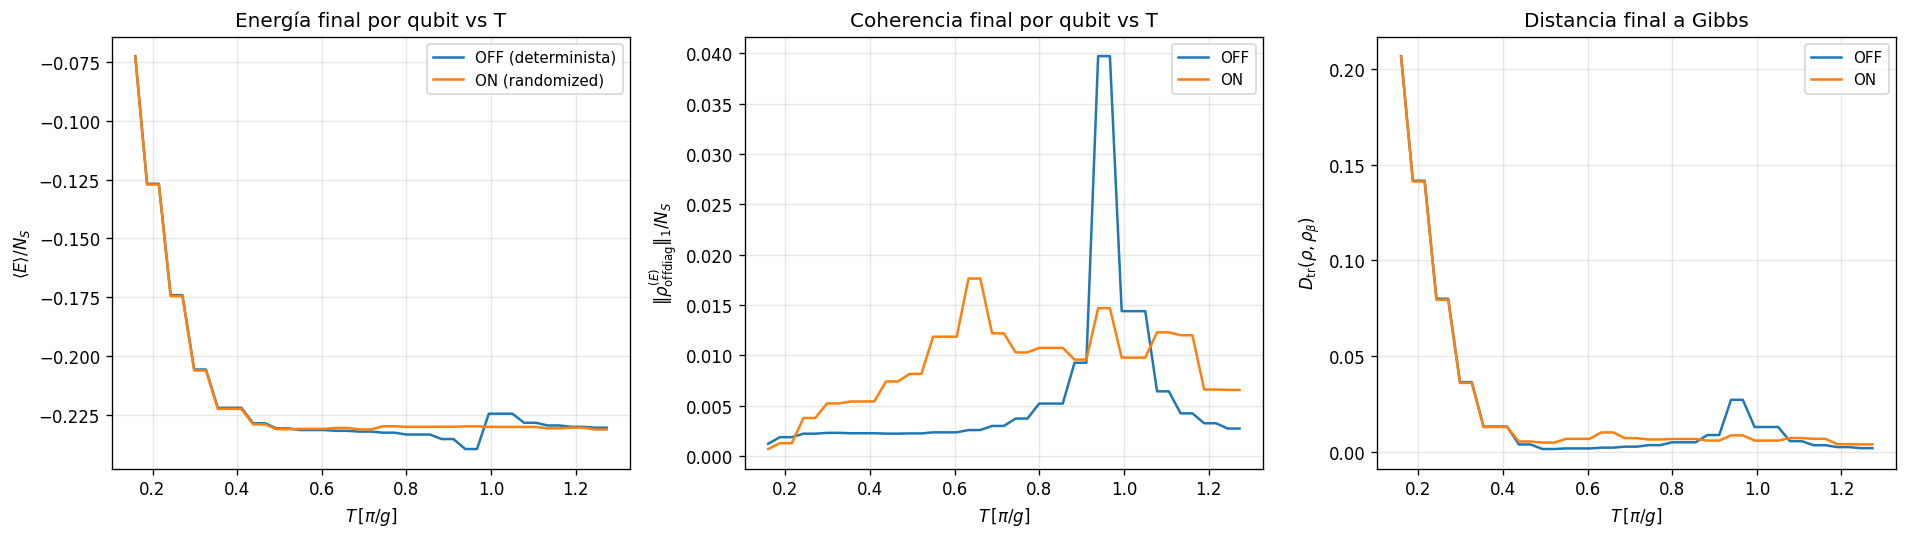

In [7]:
# A.5.1 — Fig 2b-like: barrido en T = MT*delta, randomize OFF vs ON

rho0_A5 = maximally_mixed(N_S_default)

params_A5 = dict(base_nonint_params)
params_A5.update({
    "beta":     1.0,
    "theta":    0.25,
    "delta":    0.20,     # delta grande para que T = MT*delta barra bien
    "n_cycles": 200,
})

g_A5 = params_A5["g"]
delta_A5 = params_A5["delta"]
T_grid = np.linspace(0.5, 4.0, 41) / g_A5
x_grid = T_grid * g_A5 / np.pi    # eje en unidades de pi/g

pop_off, coh_off, dist_off = [], [], []
pop_on,  coh_on,  dist_on  = [], [], []
seeds = [101, 202, 303]

for T_val in T_grid:
    MT_val = max(int(round(T_val / delta_A5)), 1)

    # OFF: determinista
    p_off = dict(params_A5, MT=MT_val,
                 randomize=False, randomization_lambda=0.0)
    out_off = run_nonint_case(p_off, rho0=rho0_A5, compute_fp=False)
    rho_f = out_off["res"]["rhos"][-1]
    pop_off.append(expect(out_off["Hs"], rho_f) / N_S_default)
    coh_off.append(coherence_norm_in_energy_basis(rho_f, out_off["Hs"]) / N_S_default)
    dist_off.append(trace_distance_dm(rho_f, out_off["rho_g"]))

    # ON: promedio sobre seeds
    p_list, c_list, d_list = [], [], []
    for sd in seeds:
        p_on = dict(params_A5, MT=MT_val,
                    randomize=True, randomization_lambda=1.0, seed=sd)
        out_on = run_nonint_case(p_on, rho0=rho0_A5, compute_fp=False)
        rho_f_on = out_on["res"]["rhos"][-1]
        p_list.append(expect(out_on["Hs"], rho_f_on) / N_S_default)
        c_list.append(coherence_norm_in_energy_basis(rho_f_on, out_on["Hs"]) / N_S_default)
        d_list.append(trace_distance_dm(rho_f_on, out_on["rho_g"]))
    pop_on.append(np.mean(p_list))
    coh_on.append(np.mean(c_list))
    dist_on.append(np.mean(d_list))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(x_grid, pop_off, label="OFF (determinista)")
axes[0].plot(x_grid, pop_on,  label="ON (randomized)")
axes[0].set_xlabel(r"$T\,[\pi/g]$"); axes[0].set_ylabel(r"$\langle E\rangle/N_S$")
axes[0].set_title("Energía final por qubit vs T")
axes[0].legend(fontsize=9)

axes[1].plot(x_grid, coh_off, label="OFF")
axes[1].plot(x_grid, coh_on,  label="ON")
axes[1].set_xlabel(r"$T\,[\pi/g]$")
axes[1].set_ylabel(r"$\|\rho^{(E)}_{\rm offdiag}\|_1 / N_S$")
axes[1].set_title("Coherencia final por qubit vs T")
axes[1].legend(fontsize=9)

axes[2].plot(x_grid, dist_off, label="OFF")
axes[2].plot(x_grid, dist_on,  label="ON")
axes[2].set_xlabel(r"$T\,[\pi/g]$")
axes[2].set_ylabel(r"$D_{\rm tr}(\rho, \rho_\beta)$")
axes[2].set_title("Distancia final a Gibbs")
axes[2].legend(fontsize=9)

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

La randomización temporal suaviza la estructura resonante heredada de single spin. En el modelo no interactuante esto confirma que la mitigación actúa localmente, sin introducir física colectiva nueva.

### A.5.2 Zoom resonante: randomización OFF vs ON


Como validación adicional, hacemos un barrido fino alrededor de una ventana resonante usando directamente el notebook, sin recurrir a archivos pickle. El parámetro de control es

$$
x \equiv \frac{T_{\rm eff} g}{\pi}, \qquad T_{\rm eff}=M_T\delta,
$$

de modo que $x \approx 2$ corresponde a una región resonante. Comparamos el protocolo sin randomización y con randomización temporal, promediando esta última sobre varias semillas.

Este bloque se deja como apéndice porque no cambia la conclusión principal del notebook: en el modelo no interactuante, las resonancias se heredan qubit a qubit. Su papel aquí es solo mostrar con más resolución que la randomización suaviza la estructura fina cerca de la resonancia.

In [13]:
# ============================================================
# Apéndice A.1 — zoom resonante OFF vs ON (sin pickle)
# ============================================================
import gc
BASE_NONINT_PARAMS = dict(
    n_sys=2,
    g=1.0,
    h=1.0,
    beta=1.0,
    theta=0.15,
    delta=0.08,
    MT=30,
    n_cycles=150,
    sys_A="ZYmix",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    seed=1234,
    rewind=False,
)

def run_zoom_resonant_randomization() -> list[dict]:
    n_sys = 2
    params = dict(
        BASE_NONINT_PARAMS,
        n_sys=n_sys,
        theta=0.25,
        delta=0.20,
        n_cycles=250,
    )

    xgrid = make_xgrid(1.8, 2.2, 13)
    seed_list = [101, 202, 303]

    # Estado inicial sensible a coherencias/resonancias
    rho0_plus = plus_density_matrix(n_sys)

    rows = []

    for x in xgrid:
        MT = x_to_MT(x, g=params["g"], delta=params["delta"])
        print(f"[zoom] x={x:.3f}, MT={MT}", flush=True)

        # OFF
        p_off = dict(params, MT=MT, randomize=False, randomization_lambda=0.0)
        out_off = run_nonint_case(p_off, rho0=rho0_plus, compute_fp=False)
        rho_off = out_off["res"]["rhos"][-1]
        met_off = rho_metrics_nonint(rho_off, out_off["Hs"], out_off["rho_g"])

        # ON (promedio sobre semillas)
        E_on = []
        coh_on = []
        dist_on = []

        for seed in seed_list:
            p_on = dict(
                params,
                MT=MT,
                randomize=True,
                randomization_lambda=1.0,
                seed=seed,
            )
            out_on = run_nonint_case(p_on, rho0=rho0_plus, compute_fp=False)
            rho_on = out_on["res"]["rhos"][-1]
            met_on = rho_metrics_nonint(rho_on, out_on["Hs"], out_on["rho_g"])

            E_on.append(float(met_on["E"]))
            coh_on.append(float(met_on["coh_l1"]))
            dist_on.append(float(met_on["D_to_gibbs"]))

            del out_on
            gc.collect()

        rows.append(
            {
                "x_Teff_g_over_pi": float(x),
                "MT": int(MT),
                "E_off_per_sys": float(met_off["E"]) / n_sys,
                "coh_off": float(met_off["coh_l1"]),
                "dist_off": float(met_off["D_to_gibbs"]),
                "E_on_mean_per_sys": float(np.mean(E_on)) / n_sys,
                "E_on_std_per_sys": float(np.std(E_on, ddof=1)) / n_sys,
                "coh_on_mean": float(np.mean(coh_on)),
                "coh_on_std": float(np.std(coh_on, ddof=1)),
                "dist_on_mean": float(np.mean(dist_on)),
                "dist_on_std": float(np.std(dist_on, ddof=1)),
                "n_seeds": len(seed_list),
            }
        )

        del out_off
        gc.collect()

    print(f"[zoom] rows={len(rows)}", flush=True)
    return rows

In [14]:
rows_zoom = run_zoom_resonant_randomization()

df_zoom = (
    pd.DataFrame(rows_zoom)
    .sort_values("x_Teff_g_over_pi")
    .reset_index(drop=True)
)

display(df_zoom.round(6))

[zoom] x=1.800, MT=28
[zoom] x=1.833, MT=29
[zoom] x=1.867, MT=29
[zoom] x=1.900, MT=30
[zoom] x=1.933, MT=30
[zoom] x=1.967, MT=31
[zoom] x=2.000, MT=31
[zoom] x=2.033, MT=32
[zoom] x=2.067, MT=32
[zoom] x=2.100, MT=33
[zoom] x=2.133, MT=34
[zoom] x=2.167, MT=34
[zoom] x=2.200, MT=35
[zoom] rows=13


,x_Teff_g_over_pi,MT,E_off_per_sys,coh_off,dist_off,E_on_mean_per_sys,E_on_std_per_sys,coh_on_mean,coh_on_std,dist_on_mean,dist_on_std,n_seeds
0,1.800000,28,-0.232930,0.008119,0.003727,-0.230311,0.000297,0.033359,0.005430,0.009373,0.001547,3
1,1.833333,29,-0.233911,0.011931,0.005595,-0.230705,0.000273,0.027038,0.012058,0.007493,0.003363,3
2,1.866667,29,-0.233911,0.011931,0.005595,-0.230705,0.000273,0.027038,0.012058,0.007493,0.003363,3
3,1.900000,30,-0.236771,0.024241,0.011292,-0.230510,0.001108,0.010106,0.012144,0.003650,0.002865,3
4,1.933333,30,-0.236771,0.024241,0.011292,-0.230510,0.001108,0.010106,0.012144,0.003650,0.002865,3
5,1.966667,31,-0.174373,0.236450,0.102302,-0.230989,0.000324,0.013964,0.001746,0.003926,0.000404,3
6,2.000000,31,-0.174373,0.236450,0.102302,-0.230989,0.000324,0.013964,0.001746,0.003926,0.000404,3
7,2.033333,32,-0.226523,0.021069,0.009242,-0.231007,0.000447,0.014203,0.007334,0.004039,0.002095,3
8,2.066667,32,-0.226523,0.021069,0.009242,-0.231007,0.000447,0.014203,0.007334,0.004039,0.002095,3
9,2.100000,33,-0.228974,0.011145,0.004578,-0.230893,0.000615,0.012617,0.006607,0.003662,0.001957,3


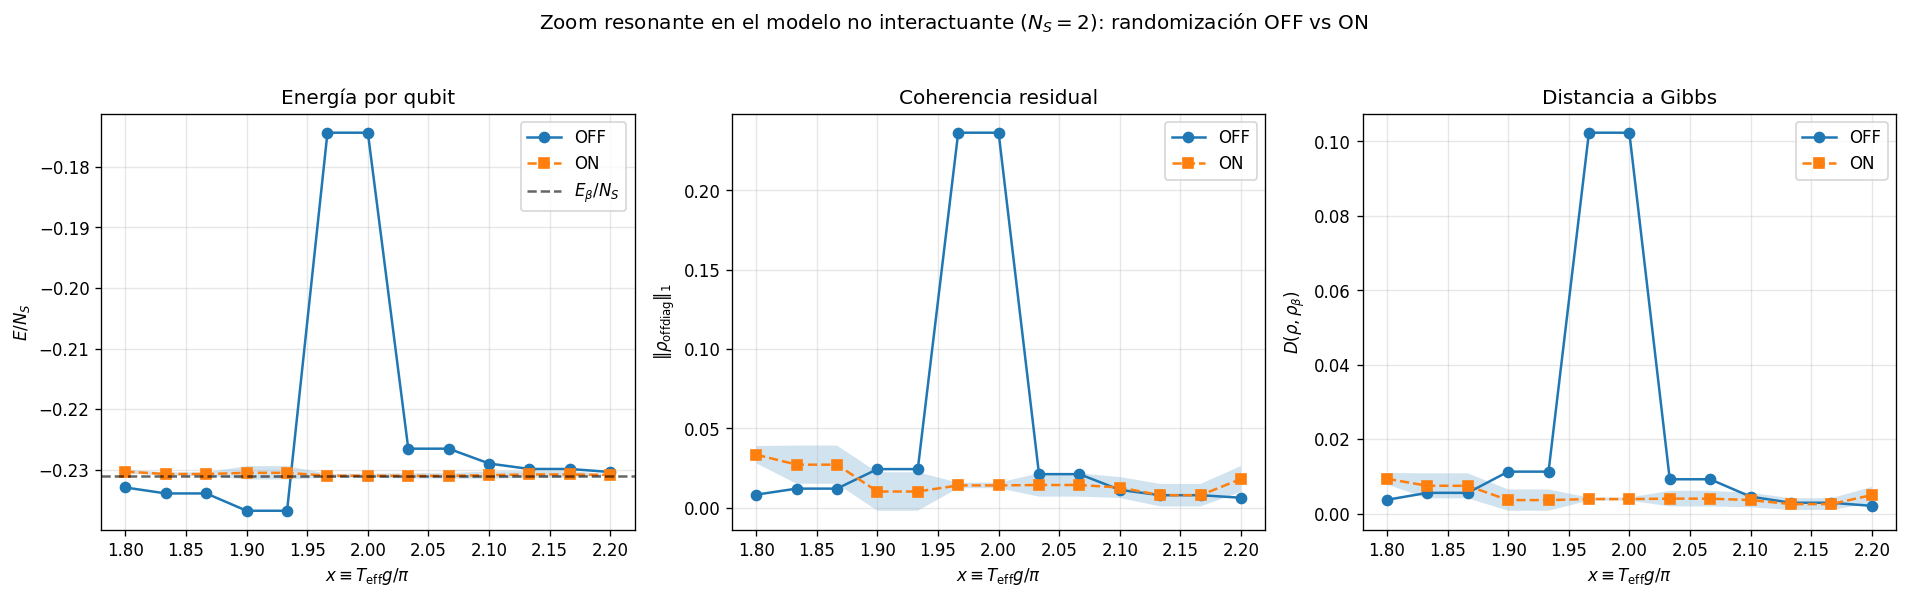

In [15]:
N_S_zoom = 2
beta_zoom = BASE_NONINT_PARAMS["beta"]
g_zoom = BASE_NONINT_PARAMS["g"]

# Energía térmica por qubit para referencia
E_beta_1q = -0.5 * g_zoom * np.tanh(0.5 * beta_zoom * g_zoom)
E_beta_per_sys = E_beta_1q

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# Panel 1: energía
axes[0].plot(df_zoom["x_Teff_g_over_pi"], df_zoom["E_off_per_sys"], "o-", label="OFF")
axes[0].plot(df_zoom["x_Teff_g_over_pi"], df_zoom["E_on_mean_per_sys"], "s--", label="ON")
axes[0].fill_between(
    df_zoom["x_Teff_g_over_pi"],
    df_zoom["E_on_mean_per_sys"] - df_zoom["E_on_std_per_sys"],
    df_zoom["E_on_mean_per_sys"] + df_zoom["E_on_std_per_sys"],
    alpha=0.2,
)
axes[0].axhline(E_beta_per_sys, ls="--", color="k", alpha=0.6, label=r"$E_\beta/N_S$")
axes[0].set_xlabel(r"$x \equiv T_{\rm eff} g/\pi$")
axes[0].set_ylabel(r"$E/N_S$")
axes[0].set_title(r"Energía por qubit")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: coherencia
axes[1].plot(df_zoom["x_Teff_g_over_pi"], df_zoom["coh_off"], "o-", label="OFF")
axes[1].plot(df_zoom["x_Teff_g_over_pi"], df_zoom["coh_on_mean"], "s--", label="ON")
axes[1].fill_between(
    df_zoom["x_Teff_g_over_pi"],
    df_zoom["coh_on_mean"] - df_zoom["coh_on_std"],
    df_zoom["coh_on_mean"] + df_zoom["coh_on_std"],
    alpha=0.2,
)
axes[1].set_xlabel(r"$x \equiv T_{\rm eff} g/\pi$")
axes[1].set_ylabel(r"$\|\rho_{\rm offdiag}\|_1$")
axes[1].set_title("Coherencia residual")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Panel 3: distancia a Gibbs
axes[2].plot(df_zoom["x_Teff_g_over_pi"], df_zoom["dist_off"], "o-", label="OFF")
axes[2].plot(df_zoom["x_Teff_g_over_pi"], df_zoom["dist_on_mean"], "s--", label="ON")
axes[2].fill_between(
    df_zoom["x_Teff_g_over_pi"],
    df_zoom["dist_on_mean"] - df_zoom["dist_on_std"],
    df_zoom["dist_on_mean"] + df_zoom["dist_on_std"],
    alpha=0.2,
)
axes[2].set_xlabel(r"$x \equiv T_{\rm eff} g/\pi$")
axes[2].set_ylabel(r"$D(\rho,\rho_\beta)$")
axes[2].set_title("Distancia a Gibbs")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(
    rf"Zoom resonante en el modelo no interactuante ($N_S={N_S_zoom}$): randomización OFF vs ON",
    y=1.03,
    fontsize=12,
)
plt.tight_layout()
plt.show()

El zoom confirma con más resolución la estructura resonante del protocolo. Cerca de $x=T_{\rm eff}g/\pi \approx 2$, la versión sin randomización presenta una dependencia más fina con la ventana temporal, visible tanto en la coherencia residual como en la distancia a Gibbs. La randomización temporal promediada sobre semillas suaviza esa estructura y reduce la sensibilidad fina a la resonancia. Este resultado se deja como apéndice porque no introduce física nueva respecto a NB01: simplemente confirma que, en el modelo no interactuante, las resonancias también se heredan qubit a qubit.

### A.5.3 Rewind en $N_S > 1$: ¿induce correlaciones espurias?

La comparación previa entre las cuatro variantes (sin nada / solo random / solo rewind / ambos) era a nivel de observables globales — energía por qubit y distancia traza — y solo confirma la factorización del canal. Pero hay una pregunta que single-spin no puede responder: cuando el rewind degrada el fp, ¿induce correlaciones espurias entre qubits?

En NI la referencia $\sigma_\beta$ factoriza exactamente, así que cualquier correlación en el fp del protocolo es responsabilidad del propio protocolo. La medimos con cuatro métricas complementarias:

- $I(A:\bar A)$ — mutual information entre mitades del sistema; debe ser cero si el canal sigue factorizando.
- $D_{\rm tr}(\rho_{\rm fp}, \rho_1 \otimes \cdots \otimes \rho_N)$ — distancia entre el fp y su versión factorizada por trazas parciales; cuantifica la parte no-factorizable.
- $|E_0 - E_1|$ — asimetría qubit-a-qubit; debe ser cero por simetría con acoplos homogéneos.
- Escalado a $N_S = 1, 2, 3$ — para ver si el efecto es constante por qubit o crece con el tamaño.

La predicción ingenua, basada en la divergencia $\zeta_{ab} \propto (\delta L)^{-1}$ de la Ec. 53, es que `solo rewind` debería disparar $I(A:\bar A)$ y la no-factorizabilidad — pero esto solo si $\Delta\hat G$ no factoriza.

,N_S,variante,Efp/N_S,Dtr_global,I(A:Abar),"Dtr(fp, factorizado)",asimetría σ(E_i)
0,1,sin nada,-0.222128,0.008954,0.0,0.000000,0.0
1,1,solo random,-0.221849,0.009383,0.0,0.000000,0.0
2,1,solo rewind,-0.108615,0.170104,0.0,0.000000,0.0
3,1,ambos,-0.220631,0.010436,0.0,0.000000,0.0
4,2,sin nada,-0.222128,0.012993,0.0,0.000023,0.0
5,2,solo random,-0.221849,0.013557,0.0,0.000042,0.0
6,2,solo rewind,-0.108615,0.204292,0.0,0.000000,0.0
7,2,ambos,-0.220631,0.015133,0.0,0.000028,0.0
8,3,sin nada,-0.222128,0.014143,0.0,0.000039,0.0
9,3,solo random,-0.221849,0.014718,0.0,0.000085,0.0


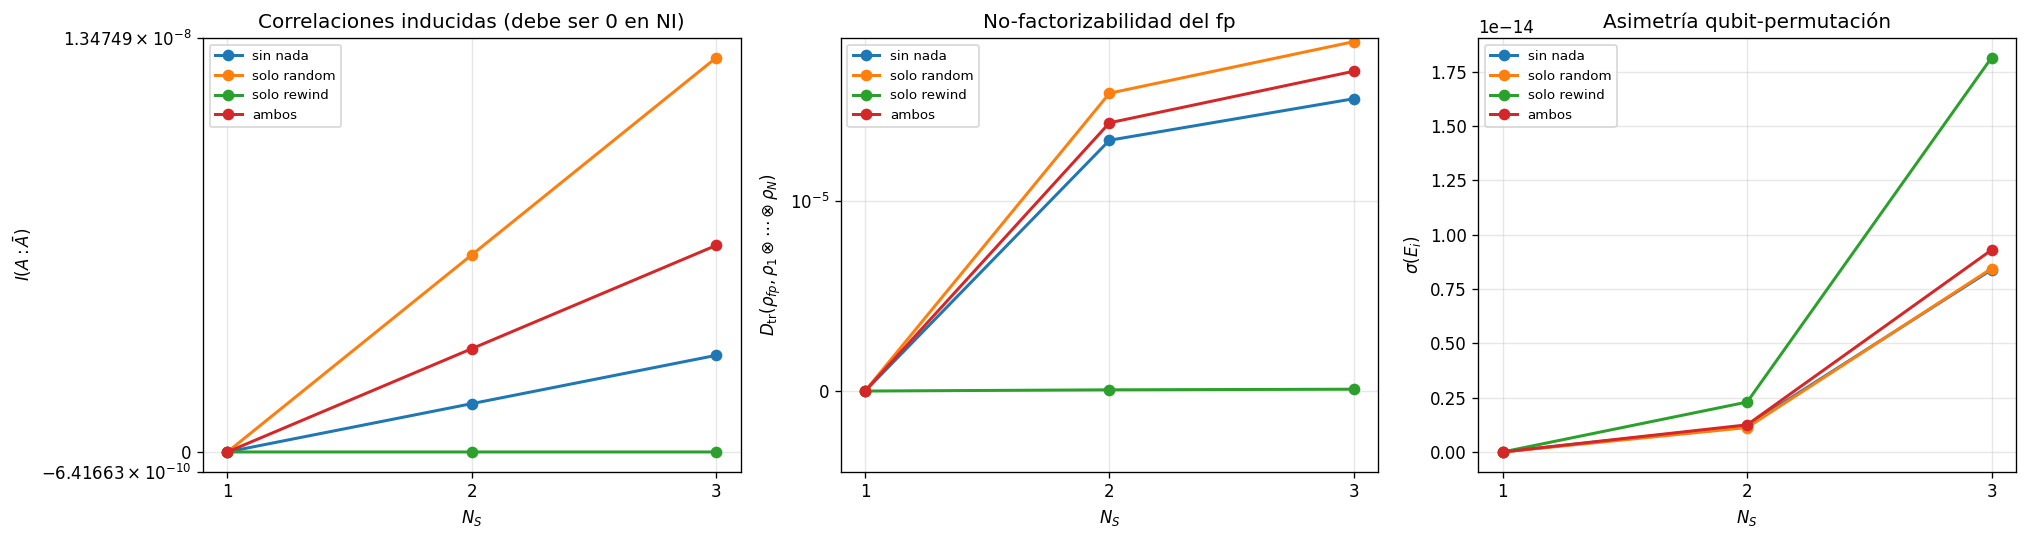

In [15]:
# A.5.2 — rewind: propagación de correlaciones y escalado con N_S
#
# Añadimos al análisis anterior dos métricas específicas de N_S > 1:
#   - I(A:Abar) del fixed point   (debería ser 0 en NI factorizado)
#   - D_tr(rho_fp, rho_1 ⊗ rho_2) (no-factorizabilidad del fp)
# y repetimos para N_S = 1, 2, 3.

variants = {
    "sin nada":    dict(randomize=False, randomization_lambda=0.0, rewind=False),
    "solo random": dict(randomize=True,  randomization_lambda=1.0, rewind=False),
    "solo rewind": dict(randomize=False, randomization_lambda=0.0, rewind=True),
    "ambos":       dict(randomize=True,  randomization_lambda=1.0, rewind=True),
}

N_S_list_var = [1, 2, 3]
rows_scale = []

for N_S_v in N_S_list_var:
    rho0_v = maximally_mixed(N_S_v)
    p_study = dict(base_nonint_params, n_sys=N_S_v, n_cycles=250)

    for name, extra in variants.items():
        p = dict(p_study); p.update(extra)
        out = run_nonint_case(p, rho0=rho0_v, compute_fp=False)

        # Fixed point aproximado: promedio tardío
        rhos = out["res"]["rhos"]
        rho_fp = project_to_physical_dm(sum(rhos[-80:]) / 80)

        # Métricas globales
        E_fp = expect(out["Hs"], rho_fp)
        D_tr = trace_distance_dm(rho_fp, out["rho_g"])

        # Métricas específicas de N_S > 1: correlaciones espurias
        if N_S_v >= 2:
            I_mut = mutual_information_halves(rho_fp, N_S_v)

            # Distancia a rho_1 ⊗ rho_2 (... ⊗ rho_N)
            # Trazamos parcialmente cada qubit por separado, tensorizamos
            def single_qubit_reduced(rho, n_sys, i):
                # Traza todos los qubits excepto el i
                d = 2
                keep_qubits = [i]
                trace_qubits = [j for j in range(n_sys) if j != i]
                # Implementación simple vía reshape
                dims = [2] * n_sys
                # Reshape a (2,)*n_sys×(2,)*n_sys
                rho_t = rho.reshape(dims + dims)
                # Trazamos en orden descendente para que los ejes no se renumeren
                for q in sorted(trace_qubits, reverse=True):
                    rho_t = np.trace(rho_t, axis1=q, axis2=q + len(dims))
                    dims = dims[:q] + dims[q+1:]
                return rho_t.reshape(d, d)

            reduced = [single_qubit_reduced(rho_fp, N_S_v, i) for i in range(N_S_v)]
            rho_factored = reduced[0]
            for r in reduced[1:]:
                rho_factored = np.kron(rho_factored, r)

            D_fac = trace_distance_dm(rho_fp, rho_factored)

            # Asimetría: desviación estándar de las energías por qubit
            Es_q = per_qubit_energy(rho_fp, n_sys=N_S_v, g=base_nonint_params["g"])
            asym = float(np.std(Es_q))
        else:
            I_mut = 0.0; D_fac = 0.0; asym = 0.0

        rows_scale.append({
            "N_S":        N_S_v,
            "variante":   name,
            "Efp/N_S":    E_fp / N_S_v,
            "Dtr_global": D_tr,
            "I(A:Abar)":  I_mut,
            "Dtr(fp, factorizado)": D_fac,
            "asimetría σ(E_i)": asym,
        })

df_scale = pd.DataFrame(rows_scale)
display(df_scale.round(6))

# --- Plots: una columna por métrica, una fila por variante ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

variants_order = ["sin nada", "solo random", "solo rewind", "ambos"]
colors_var = {"sin nada": "tab:blue", "solo random": "tab:orange",
              "solo rewind": "tab:green", "ambos": "tab:red"}

for metric, ax, ylabel, title in [
    ("I(A:Abar)",          axes[0], r"$I(A:\bar A)$",
     "Correlaciones inducidas (debe ser 0 en NI)"),
    ("Dtr(fp, factorizado)", axes[1], r"$D_{\rm tr}(\rho_{fp}, \rho_1\otimes\cdots\otimes\rho_N)$",
     "No-factorizabilidad del fp"),
    ("asimetría σ(E_i)",   axes[2], r"$\sigma(E_i)$",
     "Asimetría qubit-permutación"),
]:
    for var in variants_order:
        sub = df_scale[df_scale["variante"] == var]
        ax.plot(sub["N_S"], sub[metric], "o-",
                color=colors_var[var], label=var, lw=1.8, ms=6)
    ax.set_xlabel(r"$N_S$"); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(N_S_list_var)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# En panel 1 log si tiene sentido
if (df_scale["I(A:Abar)"] > 1e-8).any():
    axes[0].set_yscale("symlog", linthresh=1e-5)
if (df_scale["Dtr(fp, factorizado)"] > 1e-8).any():
    axes[1].set_yscale("symlog", linthresh=1e-5)

plt.tight_layout(); plt.show()

El rewind puede desplazar el estado respecto a Gibbs, pero no genera mutual information física entre qubits independientes. La degradación es local: cambia el punto fijo de cada qubit, no introduce correlaciones espurias.

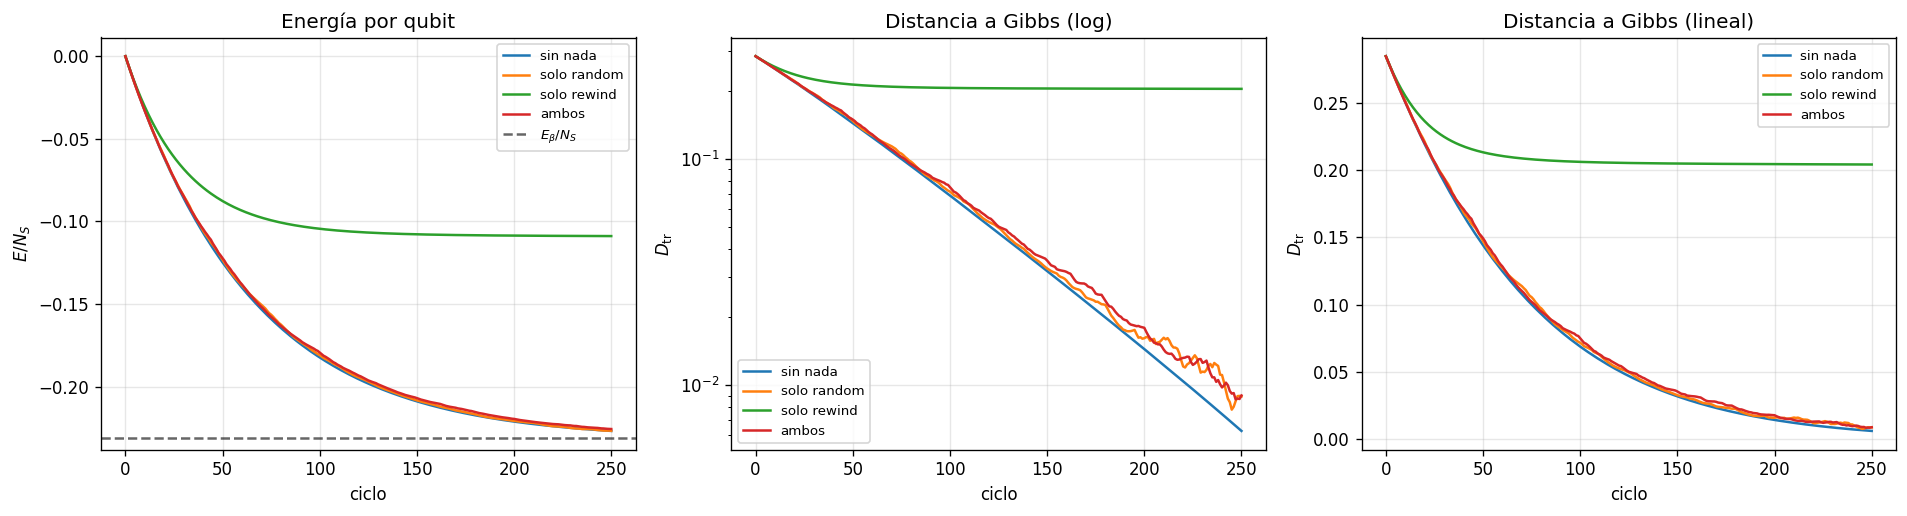

,variante,Efp/N_S,Eg/N_S,|Efp-Eg|/N_S,"Dtr(fp,Gibbs)",coh(fp)/N_S
0,sin nada,-0.220144,-0.231059,0.010914,0.015835,0.001310
1,solo random,-0.219780,-0.231059,0.011278,0.016447,0.003067
2,solo rewind,-0.108499,-0.231059,0.122560,0.204366,0.263911
3,ambos,-0.218549,-0.231059,0.012510,0.018120,0.001179


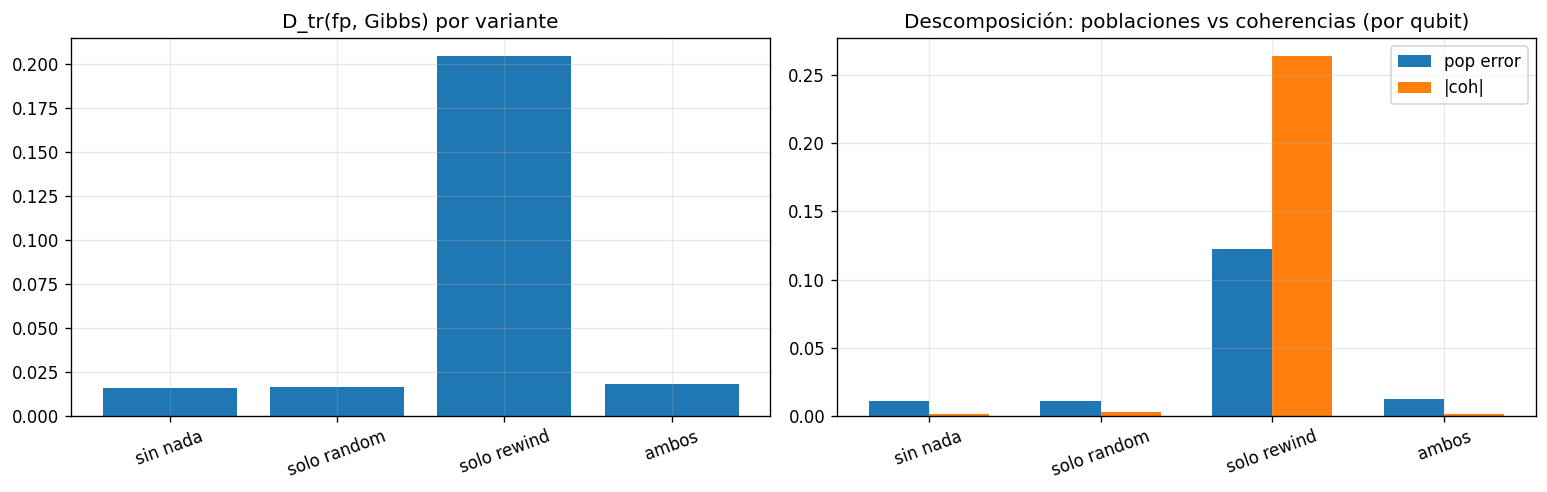

In [8]:
# A.5.2 — comparación de las cuatro variantes del protocolo

variants = {
    "sin nada":    dict(randomize=False, randomization_lambda=0.0, rewind=False),
    "solo random": dict(randomize=True,  randomization_lambda=1.0, rewind=False),
    "solo rewind": dict(randomize=False, randomization_lambda=0.0, rewind=True),
    "ambos":       dict(randomize=True,  randomization_lambda=1.0, rewind=True),
}

rho0_A52 = maximally_mixed(N_S_default)
p_study = dict(base_nonint_params, n_cycles=250)

rows_var = []
trajs_var = {}

for name, extra in variants.items():
    p = dict(p_study); p.update(extra)
    out = run_nonint_case(p, rho0=rho0_A52, compute_fp=False)
    rhos = out["res"]["rhos"]
    rho_fp = project_to_physical_dm(sum(rhos[-100:]) / 100)

    E_fp = expect(out["Hs"], rho_fp)
    coh = coherence_norm_in_energy_basis(rho_fp, out["Hs"])
    D_traj = np.array([trace_distance_dm(r, out["rho_g"]) for r in rhos])

    rows_var.append({
        "variante":       name,
        "Efp/N_S":        E_fp / N_S_default,
        "Eg/N_S":         out["Eg"] / N_S_default,
        "|Efp-Eg|/N_S":   abs(E_fp - out["Eg"]) / N_S_default,
        "Dtr(fp,Gibbs)":  trace_distance_dm(rho_fp, out["rho_g"]),
        "coh(fp)/N_S":    coh / N_S_default,
    })
    trajs_var[name] = {
        "energies": np.array(out["res"]["energies"]) / N_S_default,
        "D_traj":   D_traj,
    }

df_var = pd.DataFrame(rows_var)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for name, tr in trajs_var.items():
    axes[0].plot(tr["energies"], label=name)
    axes[1].plot(tr["D_traj"],  label=name)
    axes[2].plot(tr["D_traj"],  label=name)

axes[0].axhline(rows_var[0]["Eg/N_S"], ls="--", color="k", alpha=0.6,
                label=r"$E_\beta/N_S$")
axes[0].set_title("Energía por qubit"); axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$E/N_S$"); axes[0].legend(fontsize=8)

axes[1].set_yscale("log")
axes[1].set_title("Distancia a Gibbs (log)")
axes[1].set_xlabel("ciclo"); axes[1].set_ylabel(r"$D_{\rm tr}$")
axes[1].legend(fontsize=8)

axes[2].set_title("Distancia a Gibbs (lineal)")
axes[2].set_xlabel("ciclo"); axes[2].set_ylabel(r"$D_{\rm tr}$")
axes[2].legend(fontsize=8)

for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

display(df_var.round(8))

# Barras comparativas resumen
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(df_var["variante"], df_var["Dtr(fp,Gibbs)"])
axes[0].set_title("D_tr(fp, Gibbs) por variante")
axes[0].tick_params(axis="x", rotation=20)

x = np.arange(len(df_var)); w = 0.35
axes[1].bar(x - w/2, df_var["|Efp-Eg|/N_S"], width=w, label="pop error")
axes[1].bar(x + w/2, df_var["coh(fp)/N_S"], width=w, label="|coh|")
axes[1].set_xticks(x); axes[1].set_xticklabels(df_var["variante"], rotation=20)
axes[1].set_title("Descomposición: poblaciones vs coherencias (por qubit)")
axes[1].legend()

for ax in axes: ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

La comparación de las cuatro variantes es una confirmación 
numérica directa del argumento central de la Sección V del paper: el protocolo 
en imagen de Schrödinger (variante "sin nada") es significativamente mejor que 
el rewind completo propuesto por Hahn
("solo rewind" implementa $Q_{\rm rew} = U_S^{-(2M_T+1)}\,Q$).

Datos:
- "sin nada" y "solo random" tienen $D_{\rm tr}(fp, Gibbs) \approx 0.016$.
- "solo rewind" da $D_{\rm tr} \approx 0.205$, **más de 10 veces peor**, con 
  coherencias residuales también 100× mayores.
- "ambos" recupera el rendimiento de "sin nada": la randomización destruye las 
  resonancias que hacen explotar el rewind.

Esto confirma la Ec. 53 del paper: en el límite de rewind completo, la 
corrección perturbativa a las coherencias diverge como $\zeta_{ab} \propto 
(\delta L)^{-1}$. El protocolo Lloyd-Abanin en imagen de Schrödinger evita esta 
divergencia por construcción; el rewind la induce.

**Implicación para implementación**: los notebooks de Ising, Fermi-Hubbard...
usarán el protocolo base (`randomize=False`, `rewind=False`) como 
opción por defecto. La randomización se reserva para regímenes donde se 
identifiquen resonancias específicas.

## A.6 Relajación en NI: regímenes operativos y test Mpemba colectivo

### A.6.1 Tiempo operativo de llegada $n^*(\theta)$ a distintas temperaturas

En NB01 ya estudiamos los regímenes del protocolo mediante punto fijo, gap espectral y tiempo de mezcla. Aquí hacemos un control más simple en el modelo no interactuante: medimos el número de ciclos $n^*$ necesarios para reducir la distancia a Gibbs hasta una fracción fija de la distancia inicial.

Como el canal NI factoriza qubit a qubit, no esperamos nuevos regímenes colectivos. Este barrido solo comprueba que el comportamiento operativo $n^*(\theta)$ se hereda de single spin y que la ventana útil sigue siendo intermedia: $\theta$ pequeño es preciso pero lento, mientras que $\theta$ grande converge rápido pero deja más sesgo residual.

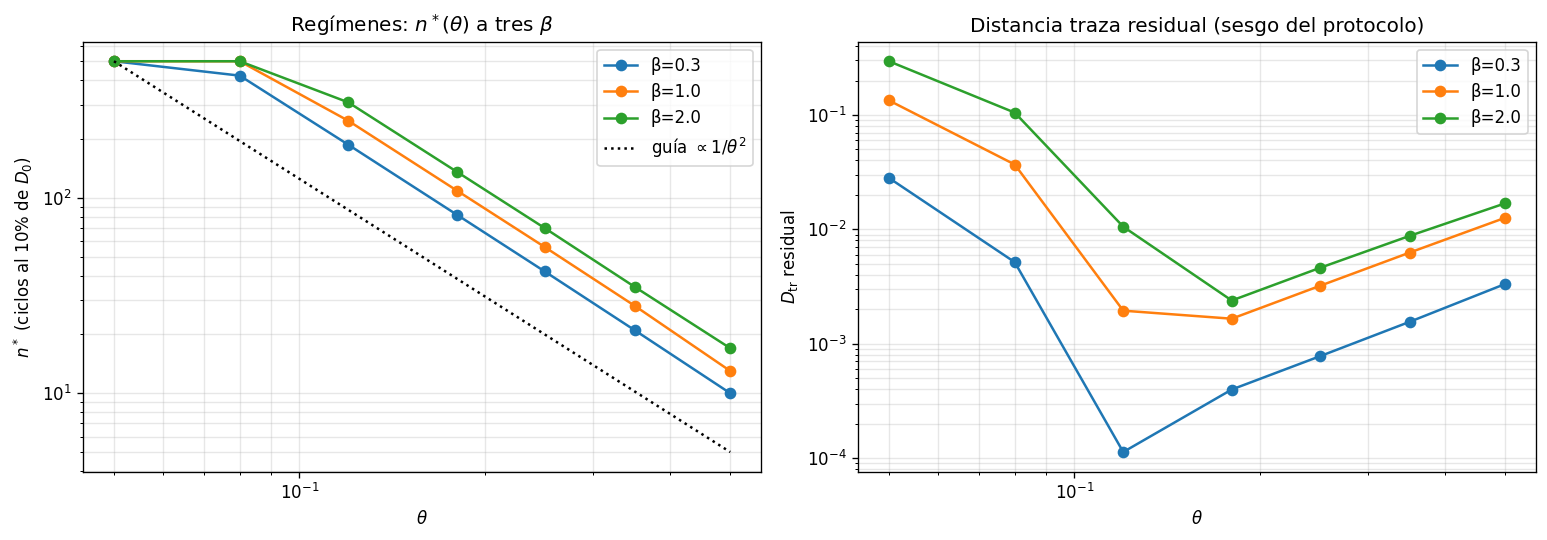

beta,0.3,1.0,2.0
theta,,,
0.05,500,500,500
0.08,422,500,500
0.12,187,248,308
0.18,82,109,136
0.25,42,56,70
0.35,21,28,35
0.50,10,13,17


In [9]:
# A.6.1 — n*(theta) a tres beta: régimen perturbativo / intermedio / fuerte

betas_regime = [0.3, 1.0, 2.0]
theta_regime = np.array([0.05, 0.08, 0.12, 0.18, 0.25, 0.35, 0.50])

rows_reg = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for b in betas_regime:
    n_stars = []
    for th in theta_regime:
        p = dict(base_nonint_params,
                 beta=b, theta=float(th), n_cycles=500)
        out = run_nonint_case(p, rho0=maximally_mixed(N_S_default),
                              compute_fp=False)
        D_traj = np.array([trace_distance_dm(r, out["rho_g"])
                           for r in out["res"]["rhos"]])
        D0 = D_traj[0]
        target = 0.1 * D0              # criterio: bajar al 10% de la distancia inicial
        below = np.where(D_traj < target)[0]
        n_star = int(below[0]) if len(below) > 0 else p["n_cycles"]
        n_stars.append(n_star)

        rows_reg.append({
            "beta": b, "theta": float(th),
            "n_star": n_star, "D_final": float(D_traj[-1]),
        })

    axes[0].plot(theta_regime, n_stars, "o-", label=f"β={b}")

# Guía ~1/theta^2 anclada al punto más perturbativo de beta=1
base_row = [r for r in rows_reg if r["beta"] == 1.0 and r["theta"] == 0.05]
if base_row:
    th0 = base_row[0]["theta"]; n0 = base_row[0]["n_star"]
    axes[0].plot(theta_regime, n0 * (th0 / theta_regime)**2, "k:",
                 label=r"guía $\propto 1/\theta^2$")

axes[0].set_xlabel(r"$\theta$"); axes[0].set_ylabel(r"$n^*$ (ciclos al 10% de $D_0$)")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Regímenes: $n^*(\\theta)$ a tres $\\beta$")
axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

# Panel 2: D_final vs theta (para ver régimen fuerte donde el bias crece)
df_reg = pd.DataFrame(rows_reg)
for b in betas_regime:
    sub = df_reg[df_reg["beta"] == b]
    axes[1].plot(sub["theta"], sub["D_final"], "o-", label=f"β={b}")
axes[1].set_xlabel(r"$\theta$"); axes[1].set_ylabel(r"$D_{\rm tr}$ residual")
axes[1].set_yscale("log"); axes[1].set_xscale("log")
axes[1].set_title("Distancia traza residual (sesgo del protocolo)")
axes[1].legend(); axes[1].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

display(
    df_reg.pivot(index="theta", columns="beta", values="n_star").round(0)
)

El panel izquierdo muestra la tendencia esperada: al aumentar $\theta$, el tiempo de llegada baja aproximadamente como una ley perturbativa compatible con $1/\theta^2$ en la ventana útil. El panel derecho muestra el sesgo residual a presupuesto fijo de ciclos: para $\theta$ demasiado pequeño no se llega a tiempo, y para $\theta$ grande domina el sesgo del protocolo. Por tanto, en NI se reproduce el mismo compromiso que en single spin, sin aparecer una escala colectiva nueva.

### A.6.2 Test de temperaturas iniciales: ausencia de Mpemba colectivo en NI

En single spin el test de Mpemba es negativo. Aquí repetimos la prueba en dimensión mayor, $d=2^{N_S}$, para comprobar si el aumento de dimensión basta para generar una relajación anómala. En el modelo no interactuante no debería ocurrir, porque el canal factoriza qubit a qubit.

Fijamos una temperatura objetivo $\beta_{\rm target}$ y comparamos estados iniciales térmicos con distintas $\beta_{\rm init}$. Habría efecto Mpemba si un estado inicialmente más alejado del equilibrio llegase antes que otro más cercano.

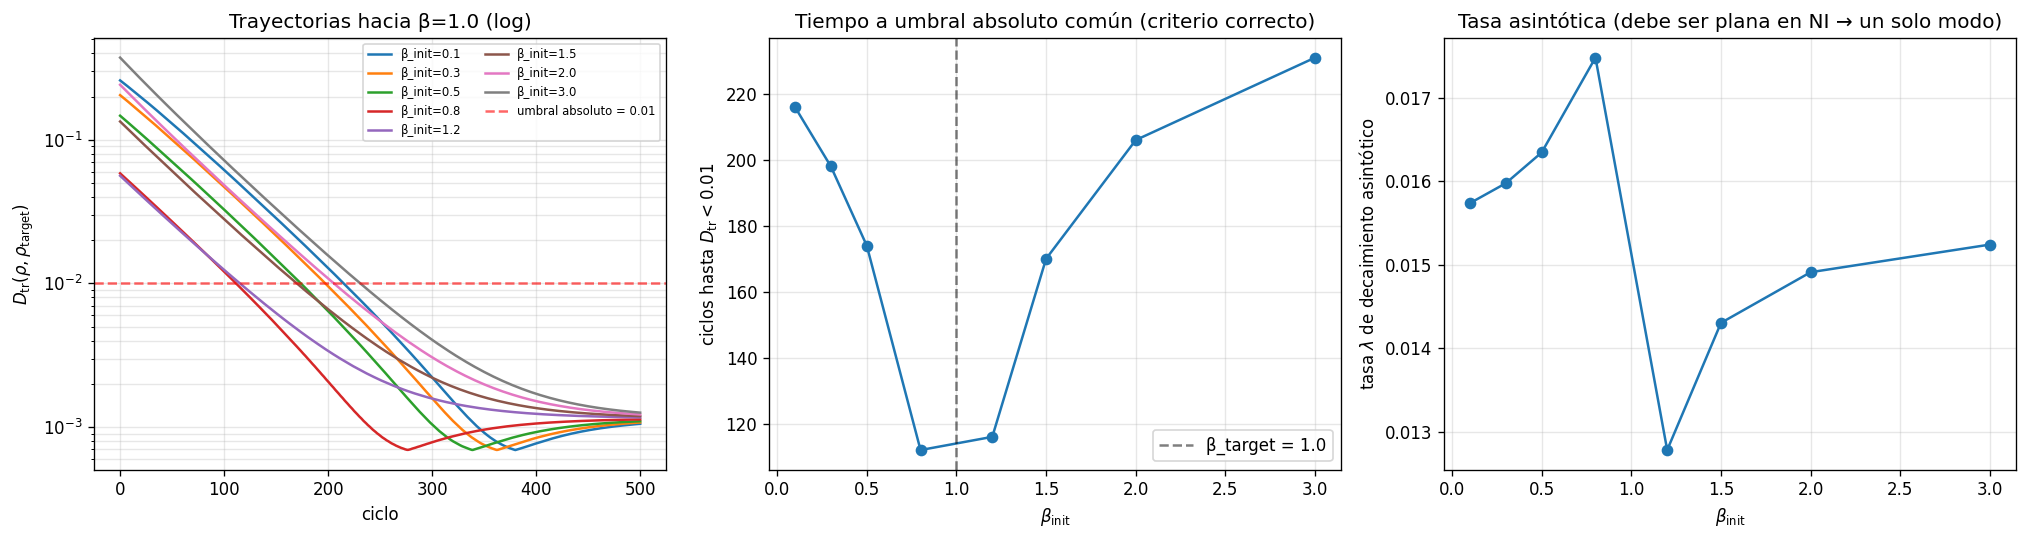

Umbral absoluto D_tr = 0.01
Chequeo Mpemba: si en el panel izquierdo no hay cruces, NO hay Mpemba.


,beta_init,D_init,n_to_abs,decay_rate
0,0.1,0.258843,216,0.015738
1,0.3,0.204462,198,0.015976
2,0.5,0.146991,174,0.016344
3,0.8,0.058382,112,0.017479
4,1.2,0.056184,116,0.012784
5,1.5,0.133981,170,0.014306
6,2.0,0.241357,206,0.014912
7,3.0,0.372951,231,0.015242


In [14]:
# A.6.2 — Mpemba baseline negativo con umbral absoluto (criterio correcto)

beta_target = 1.0
betas_init = np.array([0.1, 0.3, 0.5, 0.8, 1.2, 1.5, 2.0, 3.0])

p_mp = dict(base_nonint_params, beta=beta_target, theta=0.15, n_cycles=500)
cfg_mp = build_nonint_cfg(**p_mp)
compiled_mp = compile_protocol(cfg_mp)
Hs_mp = compiled_mp["Hs_mat"]
rho_target = gibbs_state(Hs_mp, beta_target)

# UMBRAL ABSOLUTO común a todas las condiciones iniciales
D_threshold = 0.01

rows_mp = []
trajs_mp = {}

for b_init in betas_init:
    rho_init = gibbs_state(Hs_mp, float(b_init))
    out = run_nonint_case(p_mp, rho0=rho_init, compute_fp=False)

    D_traj = np.array([trace_distance_dm(r, rho_target)
                       for r in out["res"]["rhos"]])

    below = np.where(D_traj < D_threshold)[0]
    n_to_abs = int(below[0]) if len(below) > 0 else p_mp["n_cycles"]

    # Tasa de decaimiento asintótica: ajuste lineal a log(D) en el rango medio
    seg = D_traj[50:250]
    valid = seg > 1e-12
    if valid.sum() > 20:
        xs = np.arange(len(seg))[valid]
        ys = np.log(seg[valid])
        rate = -np.polyfit(xs, ys, 1)[0]
    else:
        rate = np.nan

    rows_mp.append({
        "beta_init":  float(b_init),
        "D_init":     float(D_traj[0]),
        "n_to_abs":   n_to_abs,
        "decay_rate": float(rate),
    })
    trajs_mp[b_init] = D_traj

df_mp = pd.DataFrame(rows_mp).sort_values("beta_init")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

for b_init, D_traj in trajs_mp.items():
    axes[0].plot(D_traj, label=f"β_init={b_init}")
axes[0].axhline(D_threshold, ls="--", color="red", alpha=0.6,
                label=f"umbral absoluto = {D_threshold}")
axes[0].set_yscale("log")
axes[0].set_xlabel("ciclo"); axes[0].set_ylabel(r"$D_{\rm tr}(\rho, \rho_{\rm target})$")
axes[0].set_title(f"Trayectorias hacia β={beta_target} (log)")
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3, which="both")

axes[1].plot(df_mp["beta_init"], df_mp["n_to_abs"], "o-")
axes[1].axvline(beta_target, ls="--", color="k", alpha=0.5,
                label=f"β_target = {beta_target}")
axes[1].set_xlabel(r"$\beta_{\rm init}$")
axes[1].set_ylabel(f"ciclos hasta $D_{{\\rm tr}} < {D_threshold}$")
axes[1].set_title("Tiempo a umbral absoluto común (criterio correcto)")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(df_mp["beta_init"], df_mp["decay_rate"], "o-")
axes[2].set_xlabel(r"$\beta_{\rm init}$")
axes[2].set_ylabel(r"tasa $\lambda$ de decaimiento asintótico")
axes[2].set_title("Tasa asintótica (debe ser plana en NI → un solo modo)")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Umbral absoluto D_tr = {D_threshold}")
print(f"Chequeo Mpemba: si en el panel izquierdo no hay cruces, NO hay Mpemba.")
display(df_mp.round(6))

El resultado sigue siendo negativo: los estados inicialmente más próximos al equilibrio alcanzan antes el umbral común. La mayor dimensión de Hilbert no genera por sí sola un efecto Mpemba si la dinámica sigue factorizando. Este resultado refuerza el papel de NB02 como control negativo: para obtener relajación colectiva anómala habrá que introducir interacciones.

## A.7 Escalado exacto con el tamaño del sistema $N_S$

En esta sección usamos `fp_mode="superop"`, es decir, diagonalizamos explícitamente el superoperador del canal. Para un sistema de dimensión $d_S=2^{N_S}$, el superoperador actúa sobre matrices vectorizadas y tiene tamaño $d_S^2\times d_S^2=4^{N_S}\times4^{N_S}$. Esto permite obtener el punto fijo de forma exacta, pero solo hasta tamaños pequeños.

Este bloque responde a tres preguntas:

1. si la energía por qubit y el bias por qubit permanecen planos al crecer $N_S$, como predice la factorización del modelo no interactuante;
2. cómo escala el coste computacional clásico de construir y diagonalizar el canal;
3. a partir de qué tamaño deja de ser práctico usar el punto fijo exacto por superoperador.

,N_S,dim_H,dim_superop,E/N_S,E_beta/N_S,bias/N_S,coh/N_S,Dtr_full,Dtr_fac,I(A:Abar),t_total (s),t/ciclo (ms)
0,1,2,4,-0.231636,-0.231059,0.000578,0.001256,0.000853,0.000853,0.0,4.413900,33.490000
1,2,4,16,-0.231636,-0.231059,0.000578,0.001257,0.001151,0.001151,0.0,8.058651,30.701890
2,3,8,64,-0.231636,-0.231059,0.000578,0.001257,0.001201,0.001201,0.0,160.336166,359.859471
3,4,16,256,-0.231636,-0.231059,0.000578,0.001258,0.001524,0.001524,0.0,2710.225253,4434.342976


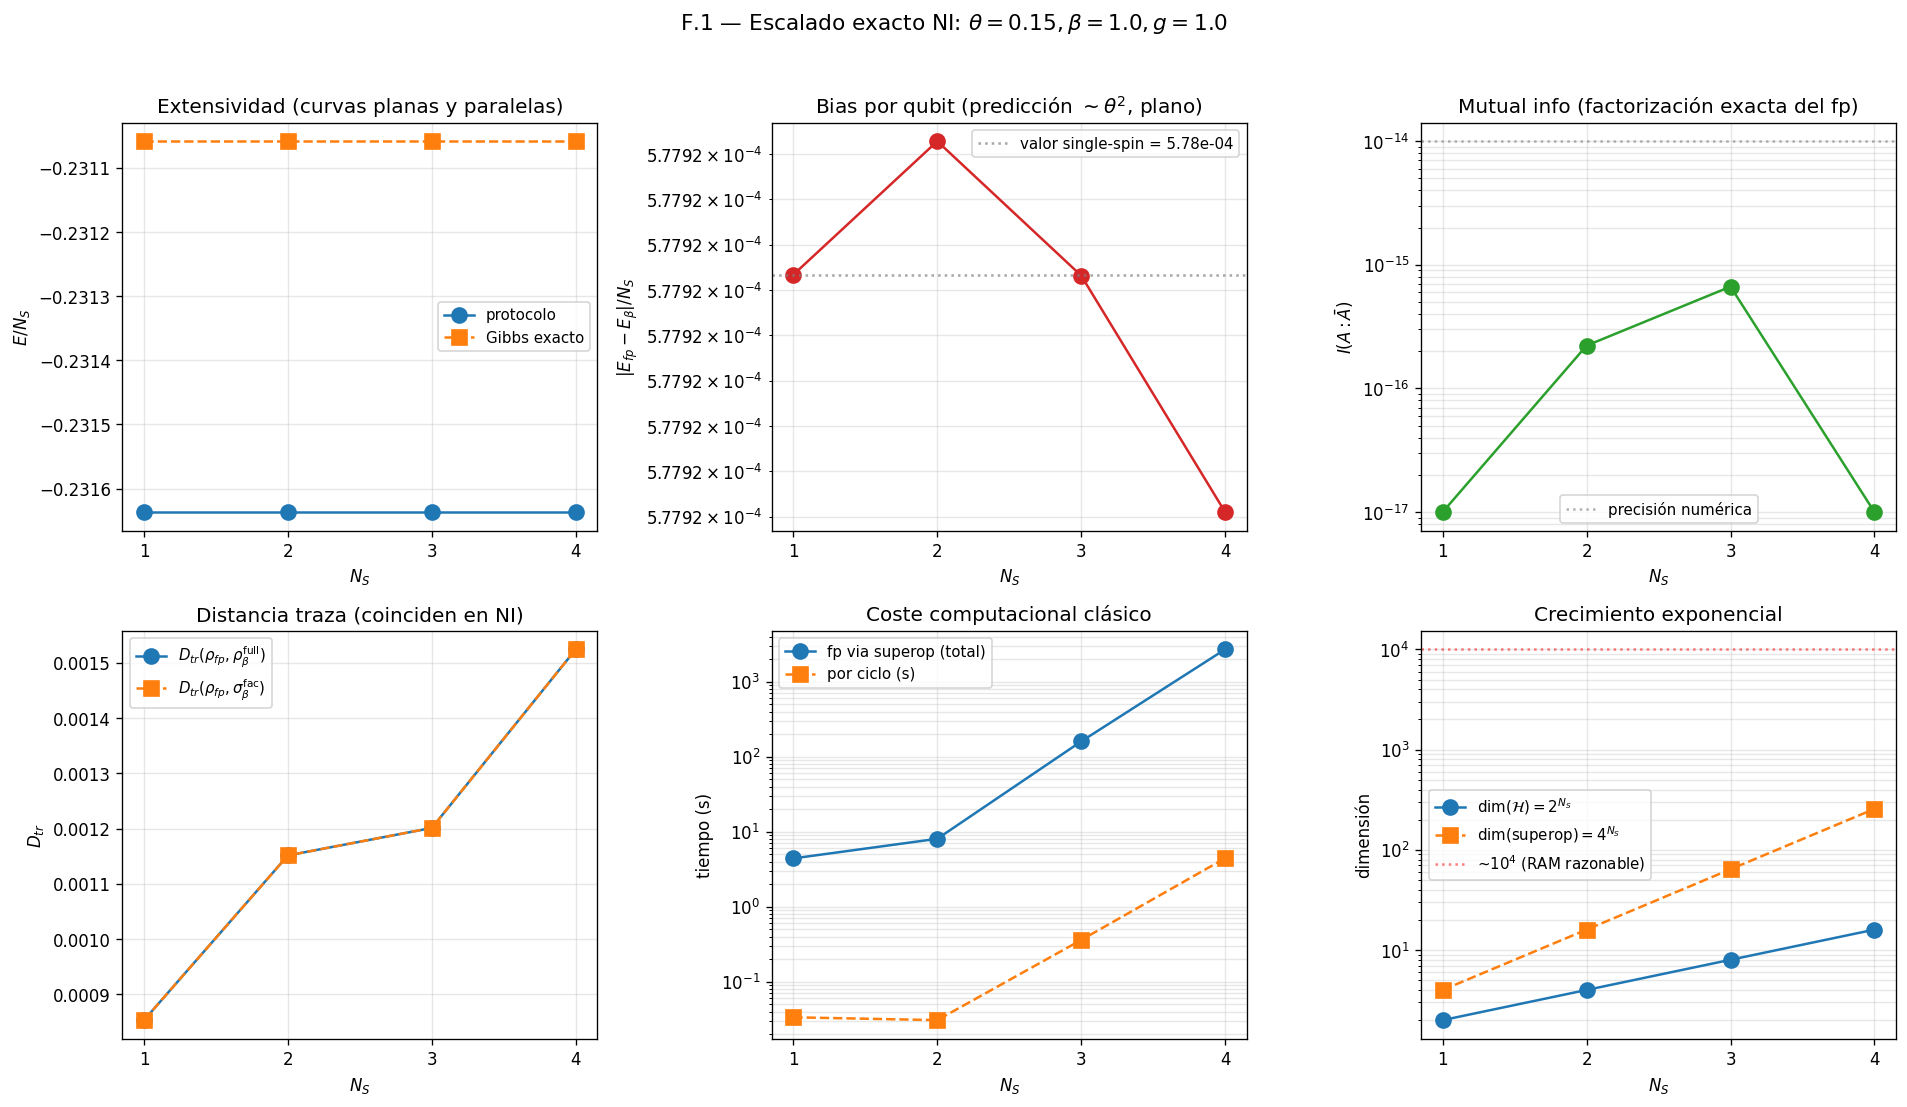

In [ ]:
# A.7— escalado con superop exacto (numpy)

import time
from tfm_shared.core import coherence_norm_in_energy_basis

N_S_list_F1 = [1, 2, 3, 4]

base_F1 = dict(base_nonint_params)
base_F1.pop("n_sys")
base_F1["n_cycles"] = 200

rows_F1 = []
trajs_F1 = {}

for N_S in N_S_list_F1:
    p = dict(base_F1, n_sys=N_S)
    rho0 = maximally_mixed(N_S)

    t0 = time.time()
    out = run_nonint_case(p, rho0=rho0, compute_fp=True, fp_mode="superop")
    t_total = time.time() - t0

    t0 = time.time()
    _ = run_nonint_case(dict(p, n_cycles=50),
                        rho0=rho0, compute_fp=False)
    t_per_cycle_ms = (time.time() - t0) / 50 * 1000

    sigma_fac = factorized_gibbs(N_S, g=p["g"], beta=p["beta"])
    Dtr_full = trace_distance_dm(out["rho_fp"], out["rho_g"])
    Dtr_fac  = trace_distance_dm(out["rho_fp"], sigma_fac)
    I_mut    = mutual_information_halves(out["rho_fp"], N_S) if N_S >= 2 else 0.0
    coh_per_q = coherence_norm_in_energy_basis(out["rho_fp"], out["Hs"]) / N_S

    rows_F1.append({
        "N_S":           N_S,
        "dim_H":         2**N_S,
        "dim_superop":   4**N_S,
        "E/N_S":         out["Efp"] / N_S,
        "E_beta/N_S":    out["Eg"] / N_S,
        "bias/N_S":      abs(out["Efp"] - out["Eg"]) / N_S,
        "coh/N_S":       coh_per_q,
        "Dtr_full":      Dtr_full,
        "Dtr_fac":       Dtr_fac,
        "I(A:Abar)":     I_mut,
        "t_total (s)":   t_total,
        "t/ciclo (ms)":  t_per_cycle_ms,
    })
    trajs_F1[N_S] = out

df_F1 = pd.DataFrame(rows_F1)
display(df_F1.round(6))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) E/N_S vs Gibbs
axes[0,0].plot(df_F1["N_S"], df_F1["E/N_S"],      "o-",  ms=9, label="protocolo", color="tab:blue")
axes[0,0].plot(df_F1["N_S"], df_F1["E_beta/N_S"], "s--", ms=9, label="Gibbs exacto", color="tab:orange")
axes[0,0].set_xlabel(r"$N_S$"); axes[0,0].set_ylabel(r"$E/N_S$")
axes[0,0].set_title("Extensividad (curvas planas y paralelas)")
axes[0,0].set_xticks(df_F1["N_S"]); axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

# (0,1) bias per qubit
axes[0,1].plot(df_F1["N_S"], df_F1["bias/N_S"], "o-", ms=9, color="tab:red")
bias_ss = df_F1["bias/N_S"].iloc[0]
axes[0,1].axhline(bias_ss, ls=":", color="gray", alpha=0.7,
                  label=f"valor single-spin = {bias_ss:.2e}")
axes[0,1].set_xlabel(r"$N_S$"); axes[0,1].set_ylabel(r"$|E_{fp}-E_\beta|/N_S$")
axes[0,1].set_title(r"Bias por qubit (predicción $\sim \theta^2$, plano)")
axes[0,1].set_yscale("log"); axes[0,1].set_xticks(df_F1["N_S"])
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3, which="both")

# (0,2) Mutual info
axes[0,2].plot(df_F1["N_S"], np.maximum(df_F1["I(A:Abar)"], 1e-17),
               "o-", ms=9, color="tab:green")
axes[0,2].axhline(1e-14, ls=":", color="gray", alpha=0.6, label="precisión numérica")
axes[0,2].set_xlabel(r"$N_S$"); axes[0,2].set_ylabel(r"$I(A:\bar A)$")
axes[0,2].set_title("Mutual info (factorización exacta del fp)")
axes[0,2].set_yscale("log"); axes[0,2].set_xticks(df_F1["N_S"])
axes[0,2].legend(fontsize=9); axes[0,2].grid(alpha=0.3, which="both")

# (1,0) Distancias traza
axes[1,0].plot(df_F1["N_S"], df_F1["Dtr_full"], "o-",  ms=9,
               label=r"$D_{tr}(\rho_{fp}, \rho_\beta^{\rm full})$")
axes[1,0].plot(df_F1["N_S"], df_F1["Dtr_fac"],  "s--", ms=9,
               label=r"$D_{tr}(\rho_{fp}, \sigma_\beta^{\rm fac})$")
axes[1,0].set_xlabel(r"$N_S$"); axes[1,0].set_ylabel(r"$D_{tr}$")
axes[1,0].set_title("Distancia traza (coinciden en NI)")
axes[1,0].set_xticks(df_F1["N_S"]); axes[1,0].legend(fontsize=9); axes[1,0].grid(alpha=0.3)

# (1,1) Coste CPU
axes[1,1].plot(df_F1["N_S"], df_F1["t_total (s)"], "o-",  ms=9, label="fp via superop (total)")
axes[1,1].plot(df_F1["N_S"], df_F1["t/ciclo (ms)"] / 1000, "s--", ms=9, label="por ciclo (s)")
axes[1,1].set_xlabel(r"$N_S$"); axes[1,1].set_ylabel("tiempo (s)")
axes[1,1].set_title("Coste computacional clásico")
axes[1,1].set_yscale("log"); axes[1,1].set_xticks(df_F1["N_S"])
axes[1,1].legend(fontsize=9); axes[1,1].grid(alpha=0.3, which="both")

# (1,2) dimensiones
axes[1,2].plot(df_F1["N_S"], df_F1["dim_H"], "o-", ms=9, label=r"$\dim(\mathcal{H}) = 2^{N_S}$")
axes[1,2].plot(df_F1["N_S"], df_F1["dim_superop"], "s--", ms=9, label=r"$\dim(\text{superop}) = 4^{N_S}$")
axes[1,2].axhline(1e4, ls=":", color="red", alpha=0.5, label=r"~$10^4$ (RAM razonable)")
axes[1,2].set_xlabel(r"$N_S$"); axes[1,2].set_ylabel("dimensión")
axes[1,2].set_title("Crecimiento exponencial")
axes[1,2].set_yscale("log"); axes[1,2].set_xticks(df_F1["N_S"])
axes[1,2].legend(fontsize=9); axes[1,2].grid(alpha=0.3, which="both")

plt.suptitle(f"F.1 — Escalado exacto NI: $\\theta={base_F1['theta']}, \\beta={base_F1['beta']}, g={base_F1['g']}$",
             y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

La energía por qubit y el bias intensivo permanecen prácticamente planos, lo que confirma que el modelo no interactuante se comporta como $N_S$ copias independientes de single spin. La mutual information se mantiene en precisión numérica, por lo que el protocolo no introduce correlaciones espurias.

La distancia traza total puede crecer con $N_S$ porque compara estados en espacios de Hilbert cada vez mayores. Por eso, para estudiar escalado físico en este notebook, la magnitud más informativa es el bias por qubit. El coste clásico, en cambio, crece rápidamente: el método exacto por superoperador es útil para validar hasta $N_S=4$, pero no es la estrategia adecuada para tamaños mayores.

## A.8 Geometría del baño en el modelo no interactuante

Este es un control exacto para $N_S=3$. Comparamos cinco geometrías de baño:

- $N_B=1$ fijo;
- $N_B=2$ fijo;
- $N_B=3$ fijo;
- $N_B=1$ rotante;
- $N_B=2$ rotante.

En el modelo no interactuante no hay transporte interno entre sitios. Por tanto, un sitio que nunca entra en contacto con un bath no tiene ningún mecanismo para thermalizar indirectamente. Las geometrías rotantes sirven para comprobar si, al hacer que todos los sitios toquen bath en promedio, se recupera la simetría espacial.

,case,N_S,N_B,schedule,E_final,E_Gibbs,|E_final-E_Gibbs|,D_final_to_Gibbs,mean_Z_final,var_Z_final,mean_bath_p1,last_bath_p1
0,$N_B=1$ fijo,3,1,"((0,),)",-0.187165,-0.693176,0.506011,0.284447,0.124776,3.113827e-02,0.044881,0.044067
1,$N_B=2$ fijo,3,2,"((0, 1),)",-0.374329,-0.693176,0.318847,0.231059,0.249553,3.113827e-02,0.044881,0.044067
2,$N_B=3$ fijo,3,3,"((0, 1, 2),)",-0.561494,-0.693176,0.131682,0.066249,0.374329,2.148824e-30,0.044881,0.044067
3,$N_B=1$ rotante,3,1,"((0,), (1,), (2,))",-0.394845,-0.693176,0.298331,0.139079,0.263230,6.481715e-06,0.045958,0.045060
4,$N_B=2$ rotante,3,2,"((0, 1), (1, 2), (2, 0))",-0.526857,-0.693176,0.166318,0.082758,0.351238,3.613350e-07,0.045273,0.044320


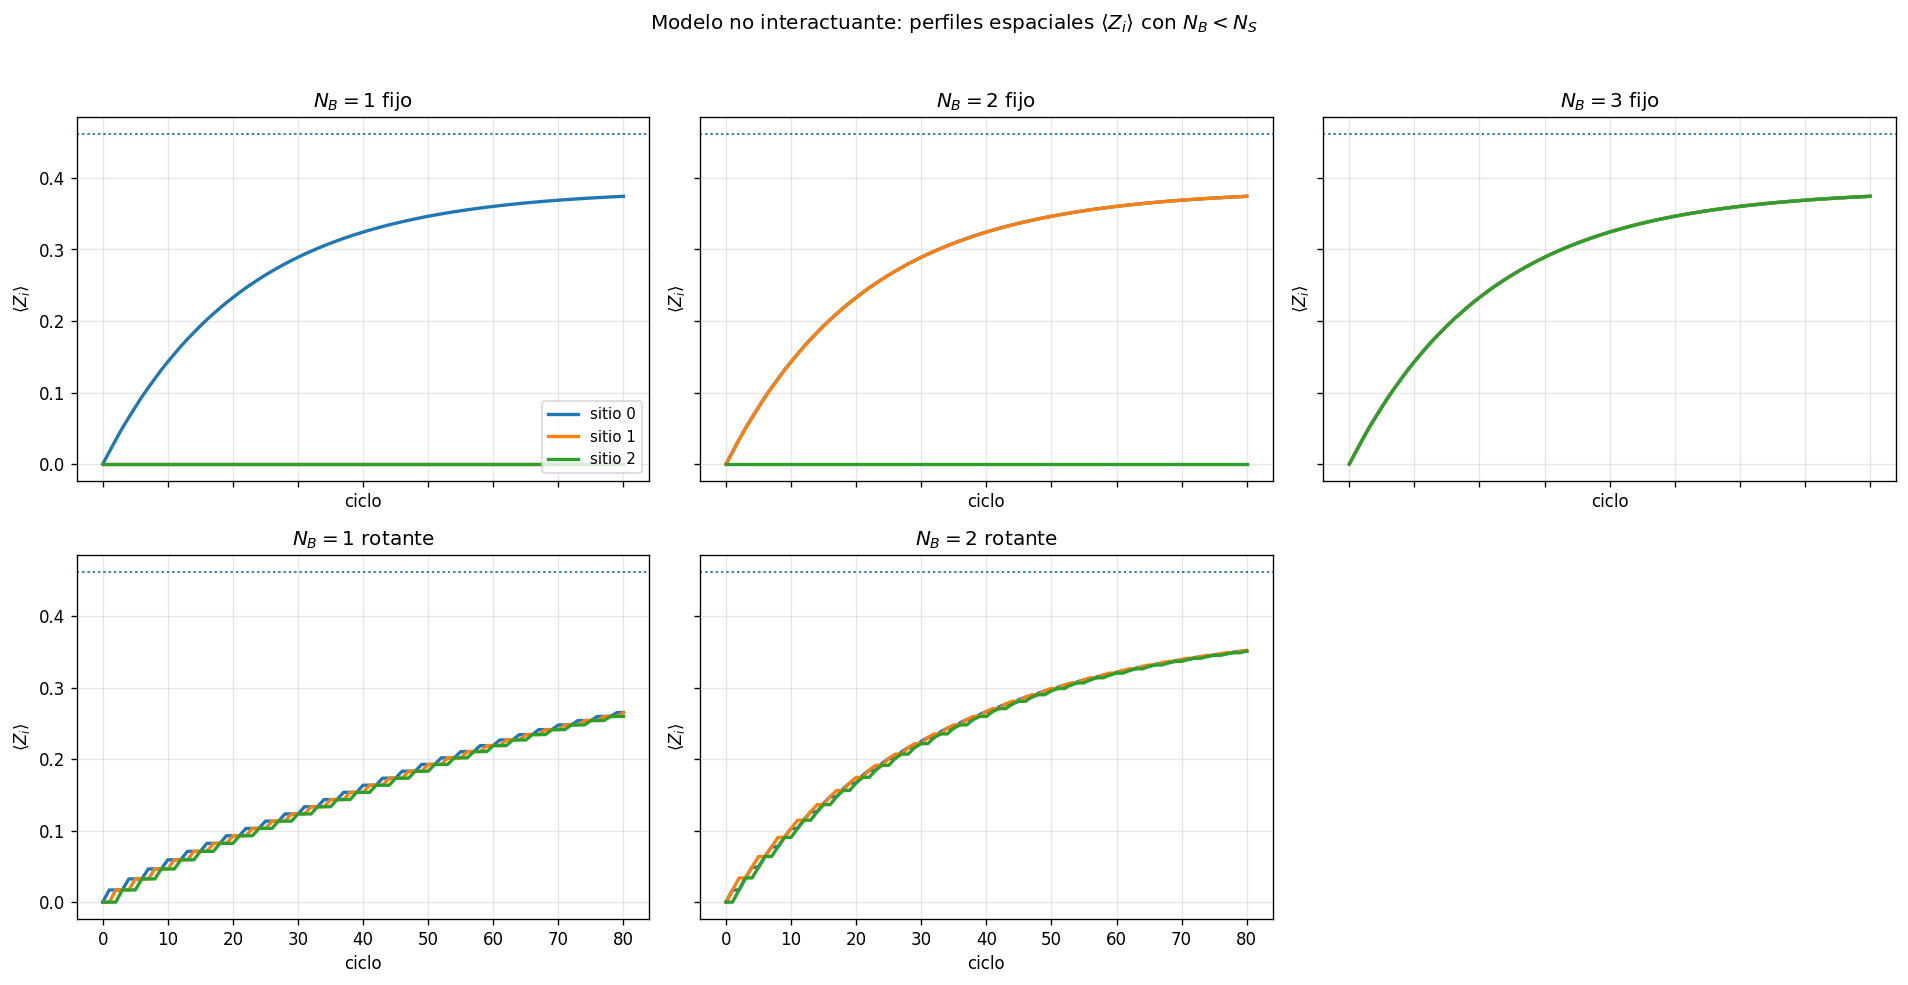

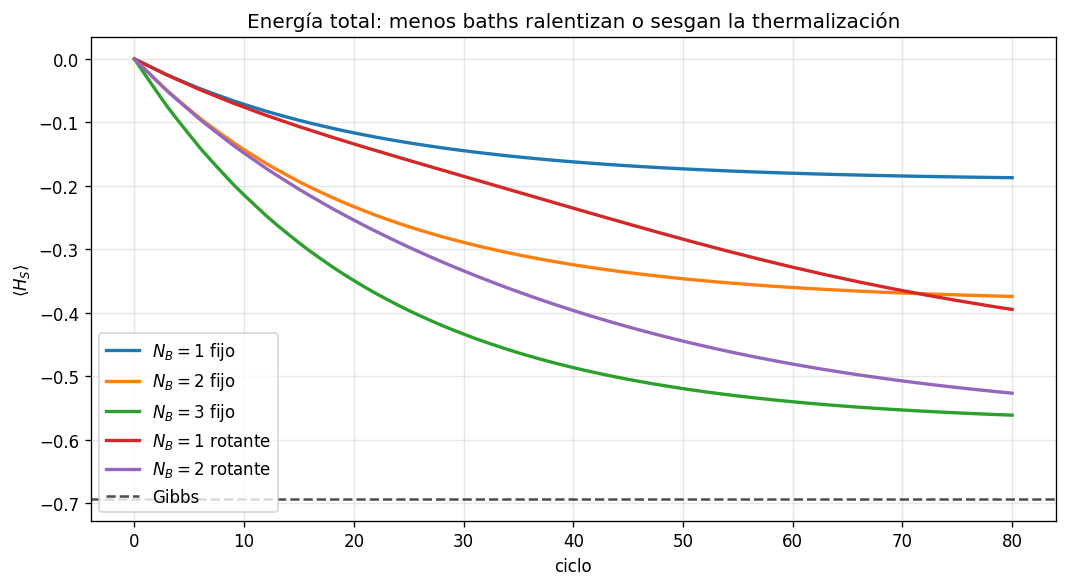

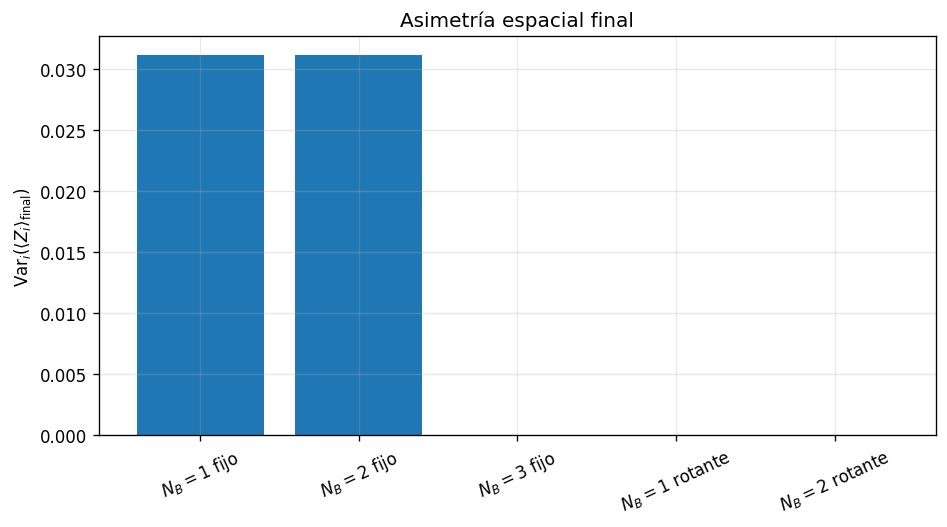

In [16]:
# A.8 — Geometría del baño en modelo no interactuante: N_S=3, N_B=1/2/3

from tfm_shared.core import (
    ProtocolConfig,
    default_bath_terms,
    noninteracting_field_terms,
    compile_protocol,
    apply_one_cycle_map,
    maximally_mixed,
    gibbs_state,
    expect,
    trace_distance_dm,
    make_op,
    qubit_pauli_expectations,
)
from tfm_single_spin.model import one_qubit_pauli_terms


def _reindex_one_qubit_terms(term_specs, new_qubit):
    """
    Reindexa términos de un operador de 1 qubit desde {0: P} a {new_qubit: P}.
    """
    out = []
    for coef, ops in term_specs:
        if len(ops) != 1:
            raise ValueError(f"Esperaba términos de 1 qubit, recibí {ops}")
        _, pauli = list(ops.items())[0]
        out.append((coef, {int(new_qubit): pauli}))
    return out


def build_nonint_cfg_custom_baths(
    base_params,
    n_sys=3,
    n_bath=1,
    bath_to_site=(0,),
):
    """
    Construye una configuración no-interactuante con N_B <= N_S.

    bath_to_site[mu] = sitio del sistema al que se acopla el bath mu.
    Ejemplo:
      n_bath=1, bath_to_site=(0,)    -> bath 0 acopla al sitio 0
      n_bath=2, bath_to_site=(0, 1) -> bath 0 a sitio 0, bath 1 a sitio 1
    """
    g = base_params.get("g", 1.0)
    h = base_params.get("h", 1.0)

    sys_A = base_params.get("sys_A", "Y")
    bath_A = base_params.get("bath_A", "Y")

    sys_terms_q0 = one_qubit_pauli_terms(sys_A)
    bath_terms_q0 = one_qubit_pauli_terms(bath_A)

    system_terms = noninteracting_field_terms(
        [g] * int(n_sys),
        pauli="Z",
        half_factor=True,
    )

    bath_terms = default_bath_terms(int(n_bath), h=h)

    coupling_specs = []
    for mu, site in enumerate(bath_to_site):
        coupling_specs.append({
            "sys_terms": _reindex_one_qubit_terms(sys_terms_q0, int(site)),
            "bath_terms": _reindex_one_qubit_terms(bath_terms_q0, int(mu)),
        })

    return ProtocolConfig(
        n_sys=int(n_sys),
        n_bath=int(n_bath),
        system_terms=system_terms,
        bath_terms=bath_terms,
        coupling_specs=coupling_specs,
        beta=base_params.get("beta", 1.0),
        h_filter=base_params.get("h", 1.0),
        theta=base_params.get("theta", 0.25),
        delta=base_params.get("delta", 0.08),
        MT=base_params.get("MT", 12),
        n_cycles=base_params.get("n_cycles", 80),
        randomize=False,   # para aislar el efecto geométrico
        randomization_lambda=0.0,
        seed=base_params.get("seed", 1234),
        rewind=base_params.get("rewind", False),
    )


def z_profile_system(rho, n_sys):
    """
    Devuelve <Z_i> para cada qubit del sistema.
    """
    vals = []
    for i in range(int(n_sys)):
        Zi = make_op(int(n_sys), [(1.0, {i: "Z"})])
        vals.append(expect(Zi, rho))
    return np.asarray(vals, dtype=float)


def run_nonint_bath_geometry_case(
    base_params,
    label,
    n_sys=3,
    n_bath=1,
    schedule=((0,),),
    n_cycles=80,
):
    """
    Ejecuta una trayectoria donde el patrón bath->site puede cambiar por ciclo.

    schedule es una lista/tupla de mapas bath_to_site.
    Ejemplos:
      ((0,),)                  -> N_B=1 fijo en sitio 0
      ((0,), (1,), (2,))       -> N_B=1 rotante
      ((0,1), (1,2), (2,0))    -> N_B=2 rotante
    """
    p = dict(base_params)
    p["n_sys"] = int(n_sys)
    p["n_bath"] = int(n_bath)
    p["n_cycles"] = int(n_cycles)

    # Compilo una vez por patrón de acoplo.
    compiled_by_map = {}
    for bath_to_site in schedule:
        bath_to_site = tuple(int(x) for x in bath_to_site)
        cfg = build_nonint_cfg_custom_baths(
            p,
            n_sys=n_sys,
            n_bath=n_bath,
            bath_to_site=bath_to_site,
        )
        compiled_by_map[bath_to_site] = compile_protocol(cfg)

    # Hamiltoniano y Gibbs objetivo son independientes de la geometría del bath.
    first_compiled = next(iter(compiled_by_map.values()))
    Hs = first_compiled["Hs_mat"]
    rho_g = gibbs_state(Hs, p.get("beta", 1.0))
    E_g = expect(Hs, rho_g)
    z_g = z_profile_system(rho_g, n_sys)

    rho = maximally_mixed(n_sys)

    rhos = [rho.copy()]
    energies = [expect(Hs, rho)]
    z_profiles = [z_profile_system(rho, n_sys)]
    bath_p1 = []

    for r in range(int(n_cycles)):
        bath_to_site = tuple(int(x) for x in schedule[r % len(schedule)])
        compiled = compiled_by_map[bath_to_site]

        step = apply_one_cycle_map(
            rho,
            compiled,
            mr=0,
            return_bath=True,
            return_joint=False,
        )

        rho = step["rho_s_next"]
        rho_b = step["rho_bath_pre_reset"]

        z_bath = qubit_pauli_expectations(rho_b, int(n_bath), pauli="Z")
        p1_bath = 0.5 * (1.0 - z_bath)

        rhos.append(rho.copy())
        energies.append(expect(Hs, rho))
        z_profiles.append(z_profile_system(rho, n_sys))
        bath_p1.append(p1_bath)

    z_profiles = np.asarray(z_profiles, dtype=float)
    bath_p1 = np.asarray(bath_p1, dtype=float)

    rho_final = rhos[-1]
    z_final = z_profiles[-1]

    summary = {
        "case": label,
        "N_S": int(n_sys),
        "N_B": int(n_bath),
        "schedule": str(schedule),
        "E_final": float(energies[-1]),
        "E_Gibbs": float(E_g),
        "|E_final-E_Gibbs|": float(abs(energies[-1] - E_g)),
        "D_final_to_Gibbs": float(trace_distance_dm(rho_final, rho_g)),
        "mean_Z_final": float(np.mean(z_final)),
        "var_Z_final": float(np.var(z_final)),
        "mean_bath_p1": float(np.mean(bath_p1)) if bath_p1.size else np.nan,
        "last_bath_p1": float(np.mean(bath_p1[-1])) if bath_p1.size else np.nan,
    }

    return {
        "label": label,
        "summary": summary,
        "energies": np.asarray(energies, dtype=float),
        "z_profiles": z_profiles,
        "bath_p1": bath_p1,
        "rho_final": rho_final,
        "rho_g": rho_g,
        "z_g": z_g,
        "E_g": E_g,
    }


# -------------------------
# Parámetros del estudio
# -------------------------

geom_params = dict(base_nonint_params)
geom_params.update({
    "n_sys": 3,
    "MT": 12,
    "theta": 0.25,
    "n_cycles": 80,
    "randomize": False,
    "randomization_lambda": 0.0,
})

n_sys_geom = 3
n_cycles_geom = 80

cases_geom = [
    {
        "label": r"$N_B=1$ fijo",
        "n_bath": 1,
        "schedule": ((0,),),
    },
    {
        "label": r"$N_B=2$ fijo",
        "n_bath": 2,
        "schedule": ((0, 1),),
    },
    {
        "label": r"$N_B=3$ fijo",
        "n_bath": 3,
        "schedule": ((0, 1, 2),),
    },
    {
        "label": r"$N_B=1$ rotante",
        "n_bath": 1,
        "schedule": ((0,), (1,), (2,)),
    },
    {
        "label": r"$N_B=2$ rotante",
        "n_bath": 2,
        "schedule": ((0, 1), (1, 2), (2, 0)),
    },
]

outs_geom = []

for case in cases_geom:
    out = run_nonint_bath_geometry_case(
        geom_params,
        label=case["label"],
        n_sys=n_sys_geom,
        n_bath=case["n_bath"],
        schedule=case["schedule"],
        n_cycles=n_cycles_geom,
    )
    outs_geom.append(out)

df_geom = pd.DataFrame([out["summary"] for out in outs_geom])
display(df_geom)


# -------------------------
# Figura 1: perfiles <Z_i>
# -------------------------

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.ravel()

cycles = np.arange(n_cycles_geom + 1)

for ax, out in zip(axes, outs_geom):
    z_profiles = out["z_profiles"]
    z_g = out["z_g"]

    for i in range(n_sys_geom):
        ax.plot(
            cycles,
            z_profiles[:, i],
            lw=2,
            label=fr"sitio {i}",
        )
        ax.axhline(
            z_g[i],
            ls=":",
            lw=1.2,
            alpha=0.6,
        )

    ax.set_title(out["label"])
    ax.set_xlabel("ciclo")
    ax.set_ylabel(r"$\langle Z_i\rangle$")
    ax.grid(alpha=0.3)

axes[-1].axis("off")
axes[0].legend(loc="lower right", fontsize=9)

fig.suptitle(
    r"Modelo no interactuante: perfiles espaciales $\langle Z_i\rangle$ con $N_B<N_S$",
    y=1.02,
)
plt.tight_layout()
plt.show()


# -------------------------
# Figura 2: energía total
# -------------------------

fig, ax = plt.subplots(figsize=(9, 5))

for out in outs_geom:
    ax.plot(
        cycles,
        out["energies"],
        lw=2,
        label=out["label"],
    )

ax.axhline(
    outs_geom[0]["E_g"],
    ls="--",
    color="k",
    alpha=0.7,
    label="Gibbs",
)

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$\langle H_S\rangle$")
ax.set_title(r"Energía total: menos baths ralentizan o sesgan la thermalización")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# -------------------------
# Figura 3: asimetría espacial final
# -------------------------

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.bar(
    df_geom["case"],
    df_geom["var_Z_final"],
)

ax.set_ylabel(r"$\mathrm{Var}_i(\langle Z_i\rangle_{\rm final})$")
ax.set_title("Asimetría espacial final")
ax.tick_params(axis="x", rotation=25)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

La geometría del bath controla qué grados de libertad thermalizan. Con baths fijos y escasos, solo se enfrían los sitios directamente acoplados; los sitios no tocados quedan atascados porque no existe transporte interno que redistribuya energía. Por eso aparece asimetría espacial cuando $N_B<N_S$ y los baths permanecen fijos.

Cuando todos los sitios tienen bath, o cuando los baths rotan entre sitios, todos los qubits son equivalentes en promedio y la asimetría final cae a cero. La rotación recupera homogeneidad, aunque puede requerir más ciclos que el caso ideal $N_B=N_S$.

Este resultado será útil como contraste con Ising: en un modelo interactuante, las interacciones internas sí pueden propagar energía y correlaciones desde sitios acoplados hacia sitios no acoplados.

## A.9 Puente exacto a Ising: aparición de correlaciones

Hasta ahora NB02 ha funcionado como control no interactuante: el Hamiltoniano factoriza, el Gibbs factoriza y el canal actúa qubit a qubit. Por eso la mutual information permanece compatible con cero y no aparecen correlaciones físicas entre partes del sistema.

Como cierre de la capa exacta, hacemos una comparación mínima con Ising 1D activando un acoplo $J>0$. Esta celda no forma parte de la capa Qiskit: es un cálculo exacto en NumPy. Su objetivo es mostrar qué cambia al romper la factorización.

En $J=0$ recuperamos el caso no interactuante, con $I(A:\bar A)\simeq 0$. Para $J>0$, el Hamiltoniano deja de ser una suma de términos locales independientes, el Gibbs ya no factoriza y aparece mutual information física entre mitades. Esta comparación sirve como puente conceptual hacia NB03: allí las correlaciones persistentes ya no serán artefactos del protocolo, sino consecuencia de las interacciones.

In [4]:
# A.9 — parámetros base para el puente NI vs Ising

base_for_scan = dict(
    base_nonint_params,
    beta=1.0,
    theta=0.15,
    delta=0.08,
    MT=30,
    n_cycles=80,
    sys_A="Y",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    rewind=False,
)

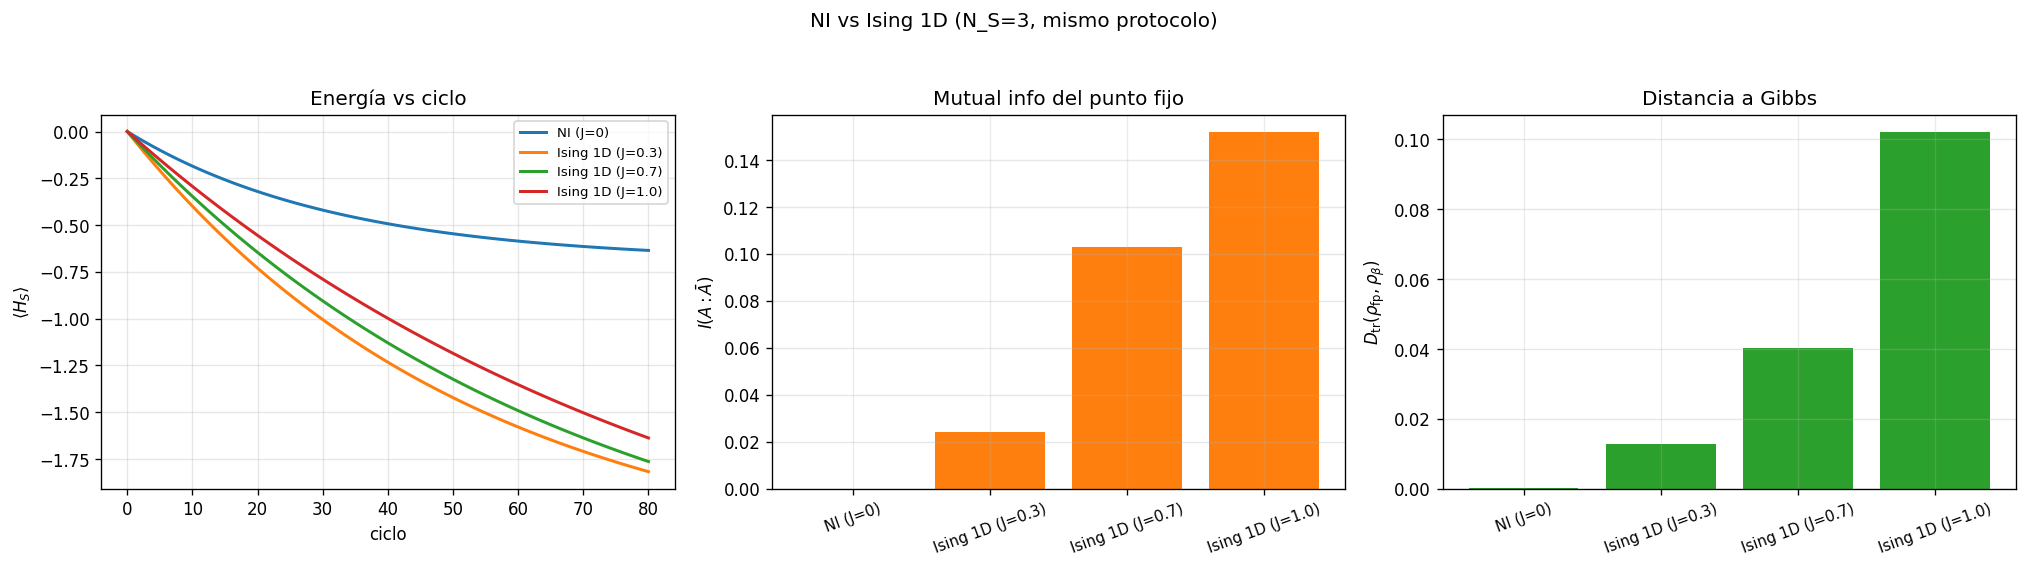

,modelo,J,E_total,E_per_qubit,"Dtr(rho, Gibbs)",I_mutual_halves
0,NI (J=0),0.0,-0.692964,-0.230988,0.000113,0.000000
1,Ising 1D (J=0.3),0.3,-2.311218,-0.770406,0.012747,0.024196
2,Ising 1D (J=0.7),0.7,-2.493629,-0.831210,0.040405,0.102917
3,Ising 1D (J=1.0),1.0,-2.595262,-0.865087,0.102012,0.151776


In [5]:
# — NI vs Ising 1D
n_sys_compare = 3
J_list = [0.0, 0.3, 0.7, 1.0]

df_compare, outs_compare = compare_ni_vs_ising1d(
    base_for_scan, n_sys=n_sys_compare, J_list=J_list,
    compute_fp=True, fp_mode="auto",
)

plot_ni_vs_ising(df_compare, outs_compare,
                 title_prefix=f"NI vs Ising 1D (N_S={n_sys_compare}, mismo protocolo)")

La comparación confirma el papel de NB02 como baseline. En el caso NI, $J=0$, la mutual information es nula y el control interno funciona. Al introducir $J>0$, aparecen correlaciones físicas y aumenta la distancia al Gibbs interactuante, porque el protocolo ya no está actuando sobre copias independientes de single spin. Este es precisamente el tipo de efecto que se estudiará de forma sistemática en NB03.

## A.10 Conclusiones de la capa exacta

La capa exacta confirma que el modelo no interactuante se comporta como $N_S$ copias independientes de single spin. El Gibbs factoriza, el bias conserva el escalado perturbativo, la mutual information es nula a precisión numérica y las resonancias temporales se heredan qubit a qubit.

Este notebook funciona como control negativo: si en NB03 aparecen correlaciones persistentes, no serán un artefacto del protocolo, sino consecuencia de las interacciones.

# B. Capa Qiskit ideal

Las secciones B, C y D son versiones reducidas de las correspondientes del notebook single-spin. Aquí no repetimos toda la metodología del backend ISA: mostramos solo lo necesario para confirmar que la implementación se traslada sin sorpresas a $N_S>1$.

In [4]:
# B.0 — chequeo Qiskit y basis nativa

if not HAVE_QISKIT:
    raise RuntimeError("Qiskit/Aer no está disponible.")

NATIVE_BASIS = ["rz", "sx", "x", "cx", "measure", "reset"]

In [5]:
# B/C/D.0 — backend bundle único para recursos, shots y ruido

backend_bundle_NI = get_nonint_backend_bundle(
    min_total_qubits=8,  # suficiente para N_S <= 4
    force_refresh=False,
)

hw_backend = backend_bundle_NI["hw_backend"]
HW_BACKEND_LABEL = backend_bundle_NI["label"]
ideal_sim = backend_bundle_NI["ideal_sim"]
noisy_sim = backend_bundle_NI["noisy_sim"]
HAVE_NOISE_MODEL = backend_bundle_NI["have_noise_model"]

print(f"Backend: {HW_BACKEND_LABEL}")
print(f"num_qubits = {hw_backend.num_qubits}")
print(f"Noise model disponible: {HAVE_NOISE_MODEL}")

Backend: FakeSherbrooke (snapshot calibraciones reales)
num_qubits = 127
Noise model disponible: True


## B.1 Validación density-matrix frente a evolución exacta

Comparamos la simulación Qiskit `density_matrix` con la evolución exacta de la capa A. El objetivo es comprobar que el orden tensorial, los resets y los acoplos locales siguen siendo correctos para $N_S>1$.

In [19]:
# B — validación Qiskit density_matrix vs numpy exacto
# Comparamos energías y trace_distance ciclo a ciclo (no las rhos completas
# porque run_qiskit_density_matrix solo guarda la rho_final, no la lista).
# Si los escalares coinciden a precisión float, las rhos coinciden también.

rows_B = []

for N_S in [1, 2, 3]:
    p = dict(base_nonint_params, n_sys=N_S, n_cycles=30)
    _, compiled_B = make_compiled_nonint(p)
    rho0_B = maximally_mixed(N_S)

    # Capa numpy (referencia)
    out_exact = run_nonint_case(p, rho0=rho0_B, compute_fp=False)

    # Capa Qiskit density_matrix
    res_dm = run_qiskit_density_matrix(
        compiled_B, n_cycles=p["n_cycles"], rho0_sys=rho0_B,
    )

    # out_exact["res"]["energies"] incluye el ciclo 0 (estado inicial),
    # así que comparamos a partir del índice 1.
    Es_exact = np.asarray(out_exact["res"]["energies"][1:], dtype=float)
    Es_dm    = np.asarray(res_dm["energies"], dtype=float)

    Ds_exact = np.asarray(out_exact["res"]["trace_dists"][1:], dtype=float) \
               if "trace_dists" in out_exact["res"] else None
    Ds_dm    = np.asarray(res_dm["trace_dists"], dtype=float)

    n_compare = min(len(Es_exact), len(Es_dm))
    err_E = float(np.max(np.abs(Es_exact[:n_compare] - Es_dm[:n_compare])))

    err_D = float("nan")
    if Ds_exact is not None:
        err_D = float(np.max(np.abs(Ds_exact[:n_compare] - Ds_dm[:n_compare])))

    # Comparación final de matriz densidad: usamos rho_final (sí está en res_dm)
    rho_final_dm    = res_dm["rho_final"]
    rho_final_exact = out_exact["res"]["rhos"][n_compare]  # ciclo n_compare
    err_rho = float(np.max(np.abs(rho_final_exact - rho_final_dm)))
    dtr_final = trace_distance_dm(rho_final_exact, rho_final_dm)

    rows_B.append({
        "N_S":              N_S,
        "n_cycles":         p["n_cycles"],
        "dim_H":            2**N_S,
        "max|E_ex - E_DM|": err_E,
        "max|D_ex - D_DM|": err_D,
        "max|ρ_final|":     err_rho,
        "Dtr final":        dtr_final,
        "pasa (<1e-10)":    "✓" if max(err_E, err_rho, dtr_final) < 1e-10 else "✗",
    })

df_B = pd.DataFrame(rows_B)
display(df_B)

max_err_global = max(df_B["max|E_ex - E_DM|"].max(),
                     df_B["max|ρ_final|"].max(),
                     df_B["Dtr final"].max())
print(f"\nError máximo global en los tres tamaños: {max_err_global:.2e}")
if max_err_global < 1e-10:
    print("→ Validación superada. Qiskit density_matrix reproduce numpy "
          "a precisión de punto flotante.")
else:
    print("→ Discrepancia detectada. Revisar la traducción numpy → Qiskit.")

,N_S,n_cycles,dim_H,max|E_ex - E_DM|,max|D_ex - D_DM|,max|ρ_final|,Dtr final,pasa (<1e-10)
0,1,30,2,3.053113e-16,NaN,6.674904e-16,4.170893e-16,✓
1,2,30,4,6.383782e-16,NaN,3.053162e-16,3.084683e-16,✓
2,3,30,8,2.220446e-16,NaN,8.517887e-17,1.495847e-16,✓



Error máximo global en los tres tamaños: 6.67e-16
→ Validación superada. Qiskit density_matrix reproduce numpy a precisión de punto flotante.


Los errores son de orden numérico, lo que valida la traducción del protocolo exacto a circuitos Qiskit ideales. Esta sección es un spot-check de implementación, no un nuevo estudio físico.

## B.2 Recursos nativos del circuito

Medimos profundidad y número de puertas de dos qubits tras transpilación. Físicamente, el modelo no interactuante factoriza qubit a qubit, por lo que una implementación ideal basada en bloques locales debería escalar de forma regular con $N_S$. Sin embargo, esta celda mide la implementación Qiskit concreta usada en el notebook, no un circuito manualmente optimizado.

El resultado sirve como diagnóstico de compilación: al aumentar $N_S$, la síntesis/transpilación de los bloques unitarios se vuelve rápidamente costosa, aunque la física subyacente sea factorizada. Por tanto, no interpretamos este coste como un límite fundamental del protocolo, sino como el coste de la construcción de circuitos usada aquí.

c:\Users\paula\miniconda3\envs\qiskit_env\lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


N_S=1: depth=68, cx=8, size=96
N_S=2: depth=2092, cx=376, size=3772
N_S=3: depth=41948, cx=7132, size=69756


,N_S,width,depth,size,cx,rz,sx,x,measure,reset
0,1,6,68,96,8,48,32,0,4,4
1,2,12,2092,3772,376,2028,1352,0,8,8
2,3,18,41948,69756,7132,37560,25040,0,12,12


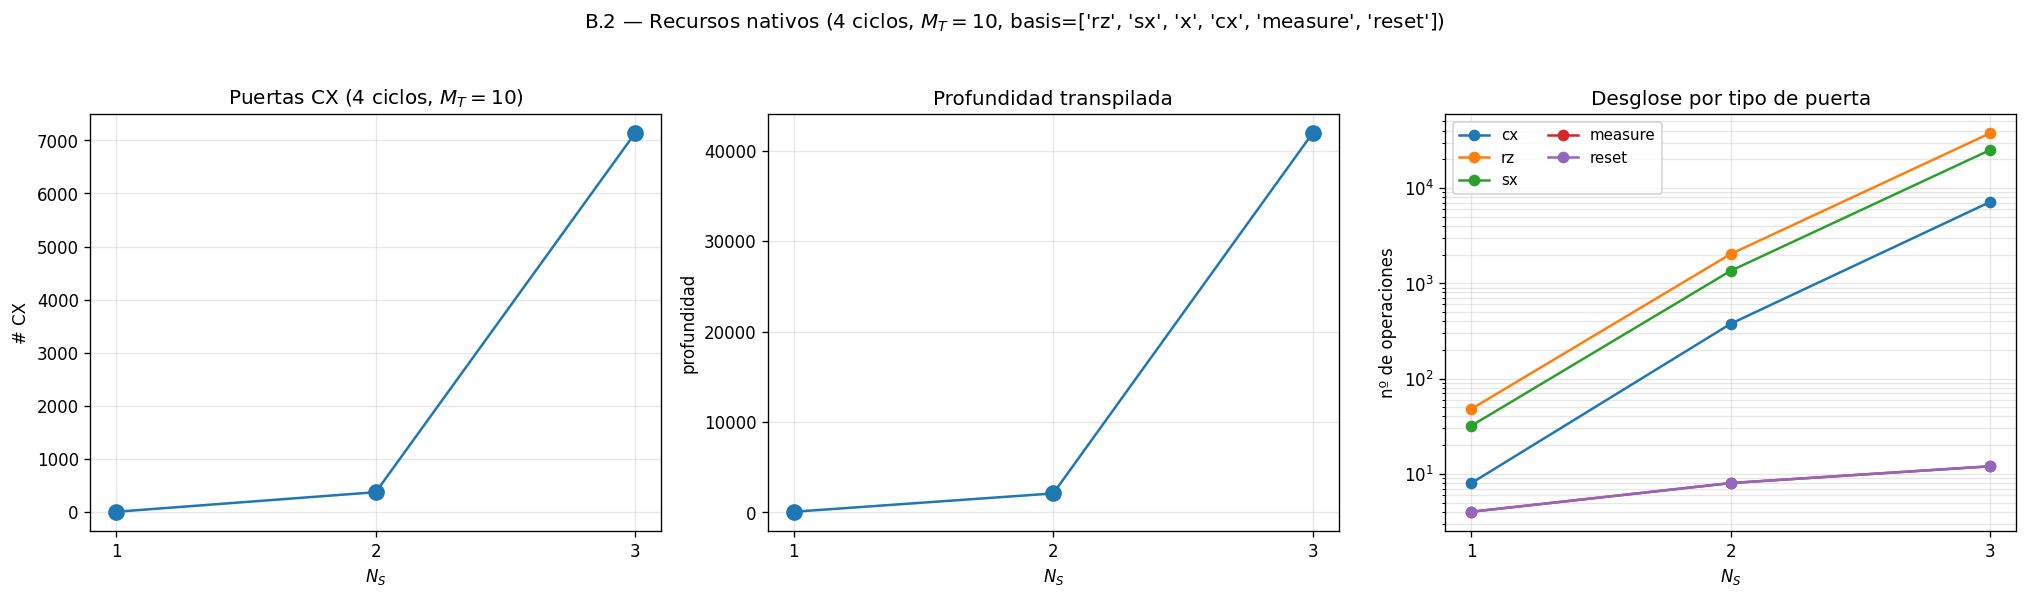

In [6]:
# ============================================================
# B.2 — recursos cuánticos tras transpilación
# ============================================================

MT_for_transpile = 10
N_S_list_B2 = [1, 2, 3]
n_cycles_B2 = 4

rows_B2 = []

for N_S in N_S_list_B2:
    p = dict(
        base_nonint_params,
        n_sys=N_S,
        MT=MT_for_transpile,
        n_cycles=n_cycles_B2,
    )

    _, compiled = make_compiled_nonint(p)

    stats = transpiled_circuit_stats(
        compiled,
        n_cycles=n_cycles_B2,
        measure_bath=True,
        basis_gates=NATIVE_BASIS,
    )

    rows_B2.append({
        "N_S":     N_S,
        "width":   stats["width"],
        "depth":   stats["depth"],
        "size":    stats["size"],
        "cx":      stats["cx"],
        "rz":      stats["rz"],
        "sx":      stats["sx"],
        "x":       stats["x"],
        "measure": stats["measure"],
        "reset":   stats["reset"],
    })

    print(
        f"N_S={N_S}: depth={stats['depth']}, "
        f"cx={stats['cx']}, size={stats['size']}"
    )

df_B2 = pd.DataFrame(rows_B2)
display(df_B2)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].plot(df_B2["N_S"], df_B2["cx"], "o-", ms=9)
axes[0].set_xlabel(r"$N_S$")
axes[0].set_ylabel("# CX")
axes[0].set_title(f"Puertas CX ({n_cycles_B2} ciclos, $M_T={MT_for_transpile}$)")
axes[0].set_xticks(df_B2["N_S"])
axes[0].grid(alpha=0.3)

axes[1].plot(df_B2["N_S"], df_B2["depth"], "o-", ms=9)
axes[1].set_xlabel(r"$N_S$")
axes[1].set_ylabel("profundidad")
axes[1].set_title("Profundidad transpilada")
axes[1].set_xticks(df_B2["N_S"])
axes[1].grid(alpha=0.3)

gate_types = ["cx", "rz", "sx", "x", "measure", "reset"]

for gt in gate_types:
    if df_B2[gt].sum() > 0:
        axes[2].plot(df_B2["N_S"], df_B2[gt], "o-", ms=6, label=gt)

axes[2].set_xlabel(r"$N_S$")
axes[2].set_ylabel("nº de operaciones")
axes[2].set_title("Desglose por tipo de puerta")
axes[2].set_xticks(df_B2["N_S"])
axes[2].set_yscale("log")
axes[2].legend(fontsize=9, ncol=2)
axes[2].grid(alpha=0.3, which="both")

plt.suptitle(
    f"B.2 — Recursos nativos ({n_cycles_B2} ciclos, "
    f"$M_T={MT_for_transpile}$, basis={NATIVE_BASIS})",
    y=1.03,
    fontsize=12,
)
plt.tight_layout()
plt.show()

El coste transpilado crece rápidamente con $N_S$. Esto no contradice la factorización física del modelo no interactuante: el crecimiento viene de la construcción Qiskit usada aquí, que transpila bloques unitarios densos en lugar de explotar manualmente la estructura local qubit-baño.

Por tanto, esta sección debe leerse como diagnóstico de implementación, no como límite fundamental del protocolo. Para tamaños mayores haría falta construir circuitos locales específicos en vez de delegar toda la descomposición al transpilador.

### B.2.1 Efecto del nivel de optimización del transpilador

El circuito lógico pasa por el transpilador antes de ejecutarse en un backend concreto. El transpilador descompone a puertas nativas, inserta routing compatible con el coupling map y simplifica puertas redundantes.

Comparamos `optimization_level = 0, 1, 3`:

- `0`: descomposición y routing básicos, útil como referencia bruta;
- `1`: optimización ligera, opción estándar;
- `3`: optimización agresiva, más lenta pero normalmente con menos profundidad y menos puertas de dos qubits.

La figura mide coste de implementación, no nueva física. El resultado relevante es que la optimización reduce mucho los recursos, especialmente para $N_S=2,3$, pero el coste sigue creciendo rápidamente con $N_S$. Para tamaños mayores haría falta explotar de forma más explícita la estructura local del modelo, no simplemente transpilar bloques globales.

In [ ]:
# — profundidad del circuito ISA vs N_S con 3 niveles de optimización

from qiskit import transpile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import gc

MT_for_transpile = 10       # reducido desde 30
N_S_list_F2b = [1, 2, 3, 4]

#N_S_list_F2b = [1, 2, 3, 4, 5, 6]
opt_levels = [0, 1, 3]
n_cycles_F2b = 3

rows_F2b = []

for N_S in N_S_list_F2b:
    p = dict(base_nonint_params, n_sys=N_S, MT=MT_for_transpile)
    _, compiled = make_compiled_nonint(p)
    
    qc = build_protocol_circuit(compiled, n_cycles=n_cycles_F2b,
                            measure_bath=True, bath_measure_basis="Z")

    for lvl in opt_levels:
        # Transpilar con distintos niveles, con backend de FakeSherbrooke
        pm = generate_preset_pass_manager(optimization_level=lvl, backend=hw_backend)
        qc_t = pm.run(qc)

        ops = dict(qc_t.count_ops())
        rows_F2b.append({
            "N_S":   N_S,
            "opt":   lvl,
            "depth": qc_t.depth(),
            "size":  qc_t.size(),
            "cx":    ops.get("ecr", ops.get("cx", 0)),   # ecr es la 2q nativa de Sherbrooke
            "rz":    ops.get("rz", 0),
            "sx":    ops.get("sx", 0),
        })
        
        print(f"  N_S={N_S}, opt={lvl}: depth={qc_t.depth()}, "
              f"2Q={ops.get('ecr', ops.get('cx', 0))}")

        del qc_t, pm
        gc.collect()
        
    del qc
    gc.collect()

df_F2b = pd.DataFrame(rows_F2b)
display(df_F2b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izq: depth vs N_S, tres niveles de opt
colors = {0: "tab:red", 1: "tab:orange", 3: "tab:green"}
labels = {0: "Level 0 (sin optimizar)",
          1: "Level 1 (default)",
          3: "Level 3 (agresivo)"}

for lvl in opt_levels:
    sub = df_F2b[df_F2b["opt"] == lvl]
    axes[0].plot(sub["N_S"], sub["depth"], "o-", ms=9, lw=2,
                 color=colors[lvl], label=labels[lvl])

axes[0].set_xlabel(r"$N_S$", fontsize=12)
axes[0].set_ylabel("profundidad del circuito", fontsize=12)
axes[0].set_title("F.2b — Depth vs $N_S$ con distintos niveles de transpilación",
                  fontsize=11)
axes[0].set_xticks(N_S_list_F2b)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Panel der: CX count con los tres niveles
for lvl in opt_levels:
    sub = df_F2b[df_F2b["opt"] == lvl]
    axes[1].plot(sub["N_S"], sub["cx"], "s-", ms=9, lw=2,
                 color=colors[lvl], label=labels[lvl])

axes[1].set_xlabel(r"$N_S$", fontsize=12)
axes[1].set_ylabel("nº puertas 2Q (ecr/cx)", fontsize=12)
axes[1].set_title("F.2b — Puertas de dos qubits vs $N_S$", fontsize=11)
axes[1].set_xticks(N_S_list_F2b)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle(f"Efecto del transpile level (backend: {HW_BACKEND_LABEL}, {n_cycles_F2b} ciclos)",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# Reducciones
for N_S in [2, 4]:
    d0 = df_F2b[(df_F2b["N_S"] == N_S) & (df_F2b["opt"] == 0)]["depth"].values[0]
    d3 = df_F2b[(df_F2b["N_S"] == N_S) & (df_F2b["opt"] == 3)]["depth"].values[0]
    cx0 = df_F2b[(df_F2b["N_S"] == N_S) & (df_F2b["opt"] == 0)]["cx"].values[0]
    cx3 = df_F2b[(df_F2b["N_S"] == N_S) & (df_F2b["opt"] == 3)]["cx"].values[0]
    print(f"N_S={N_S}: depth {d0}→{d3} ({100*(1-d3/d0):.0f}% reducción); "
          f"CX {cx0}→{cx3} ({100*(1-cx3/cx0):.0f}% reducción)")

  N_S=1, opt=0: depth=54, 2Q=6
  N_S=1, opt=1: depth=54, 2Q=6
  N_S=1, opt=3: depth=54, 2Q=6
  N_S=2, opt=0: depth=5894, 2Q=744
  N_S=2, opt=1: depth=2684, 2Q=660
  N_S=2, opt=3: depth=2282, 2Q=471
  N_S=3, opt=0: depth=115058, 2Q=15378
  N_S=3, opt=1: depth=52070, 2Q=13338
  N_S=3, opt=3: depth=46305, 2Q=11156
  N_S=4, opt=0: depth=1910392, 2Q=261126


# C. Capa shot-based ISA

Esta sección generaliza la capa shot-based de NB01 a $N_S>1$. No repetimos toda la metodología del backend ISA: mostramos solo lo necesario para confirmar que la implementación se traslada sin sorpresas al modelo no interactuante.

Hay tres diferencias respecto a single spin:

1. El estado inicial mixto $I/d$ se implementa como mezcla clásica sobre $2^{N_S}$ bitstrings.
2. Los counts del baño se separan en $N_S$ subregistros, uno por auxiliar.
3. La energía se reconstruye sumando $\langle Z_i\rangle$ qubit a qubit.

Mantenemos la sección reducida: backend cascade, trayectoria shot-based de energía y baño, tabla compacta de recursos y señal por auxiliar. Los mapas extensos en $(\theta,\mathrm{shots})$ y los escalados $1/\sqrt{N}$ ya están validados en NB01.

## C.0 Backend cascade reducido

Usamos el mismo esquema que en NB01: si está disponible, usamos un backend falso con calibraciones realistas; si no, caemos a un backend sintético. Esta celda solo prepara simuladores ideal/noisy y el pass manager para las pruebas shot-based reducidas.

In [6]:
# ============================================================
# C.0 — setup shot-based ISA con backend tipo hardware
# ============================================================
#
# Usamos el mismo backend bundle que en el resto de notebooks:
# - FakeSherbrooke si está disponible;
# - GenericBackendV2 solo como fallback.
#
# En C usamos sim_mode="ideal", así que no activamos ruido,
# pero sí mantenemos el mismo backend/coupling map/transpilación
# que se usará después en D para ruido calibrado.

qk_params_good_NI = dict(
    base_nonint_params,
    n_sys=2,
    beta=1.0,
    theta=0.20,
    delta=0.08,
    MT=8,
    n_cycles=6,
    sys_A="Y",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    rewind=False,
)

_, compiled_C_NI = make_compiled_nonint(qk_params_good_NI)

backend_bundle_NI = get_nonint_backend_bundle(
    min_total_qubits=2 * qk_params_good_NI["n_sys"],
    force_refresh=True,
)

hw_backend = backend_bundle_NI["hw_backend"]
HW_BACKEND_LABEL = backend_bundle_NI["label"]
ideal_sim = backend_bundle_NI["ideal_sim"]
noisy_sim = backend_bundle_NI["noisy_sim"]
HAVE_NOISE_MODEL = backend_bundle_NI["have_noise_model"]

print(
    f"C setup: N_S={qk_params_good_NI['n_sys']}, "
    f"MT={qk_params_good_NI['MT']}, ciclos={qk_params_good_NI['n_cycles']}"
)
print(f"Backend ISA: {HW_BACKEND_LABEL}")
print(f"num_qubits = {hw_backend.num_qubits}")
print(f"Noise model disponible: {HAVE_NOISE_MODEL}")

C setup: N_S=2, MT=8, ciclos=6
Backend ISA: FakeSherbrooke (snapshot calibraciones reales)
num_qubits = 127
Noise model disponible: True


## C.1 Señal agregada del baño antes del reset

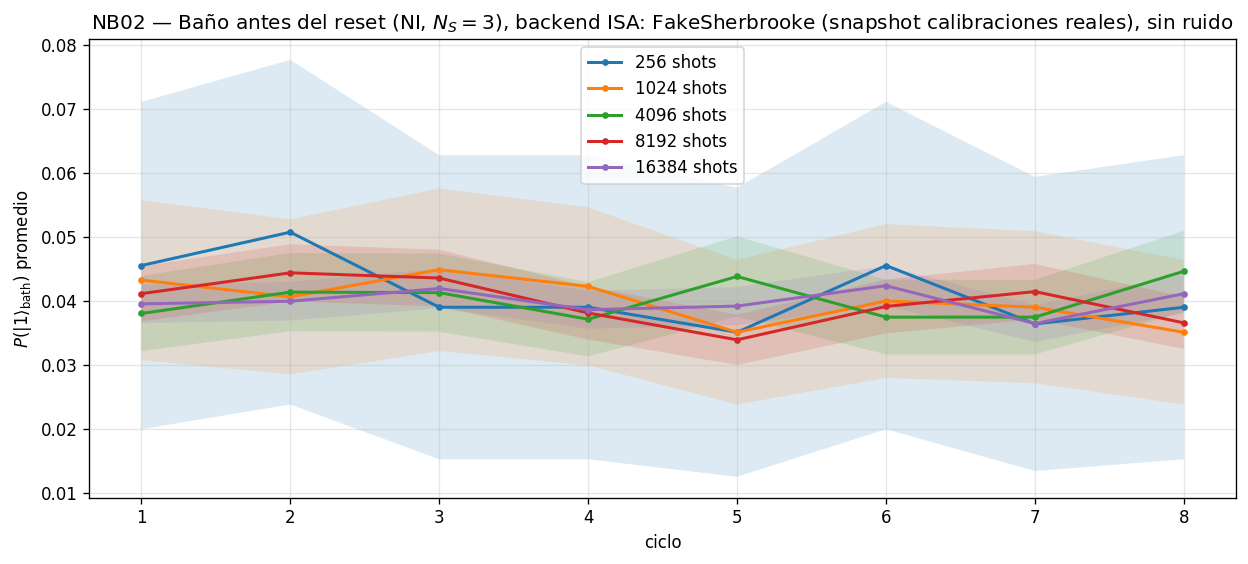

In [ ]:
# C.1 (NI) — Baño antes del reset, shot-based ideal
shots_list_C_NI = [256, 1024, 4096, 8192, 16384]
n_cycles_C_NI = qk_params_good_NI["n_cycles"]

bath_runs_C_NI = {}
for shots in shots_list_C_NI:
    bath_runs_C_NI[shots] = run_isa_dynamic_shots_nonint(
        compiled_C_NI,
        n_cycles=n_cycles_C_NI,
        shots=shots,
        init_mode="mm",
        sim_mode="ideal",
        seed_base=100 + shots,
        backend_bundle=backend_bundle_NI,
    )

cycles_C_NI = np.arange(1, n_cycles_C_NI + 1)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for shots in shots_list_C_NI:
    res = bath_runs_C_NI[shots]
    p1 = res["bath_p1_per_cycle"]
    sig = np.sqrt(np.maximum(p1 * (1 - p1), 0) / shots)
    lo, hi = np.clip(p1 - 1.96 * sig, 0, 1), np.clip(p1 + 1.96 * sig, 0, 1)
    ax.plot(cycles_C_NI, p1, marker="o", ms=3, lw=1.8, label=f"{shots} shots")
    ax.fill_between(cycles_C_NI, lo, hi, alpha=0.15)

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$P(|1\rangle_{\rm bath})$ promedio")
ax.set_title(f"NB02 — Baño antes del reset (NI, $N_S={qk_params_good_NI['n_sys']}$), "
             f"backend ISA: {HW_BACKEND_LABEL_NI}, sin ruido")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## C.2 Trayectorias shot-based: energía y señal agregada del baño

In [24]:
# C.1 — helpers shot-based generalizados a N qubits
ISA_CIRCUIT_CACHE_NI = {}

def mixture_plan_NI(init_mode, shots, n_sys, rng=None):
    """Estado inicial hardware-like para N qubits.
    'mm' -> muestrea uniformemente sobre 2^N_S bitstrings."""
    if init_mode == "mm":
        rng = rng if rng is not None else np.random.default_rng(0)
        samples = rng.integers(0, 2**n_sys, size=shots)
        unique, counts = np.unique(samples, return_counts=True)
        plan = []
        for val, n in zip(unique, counts):
            label = format(int(val), f"0{n_sys}b")
            plan.append((label, int(n)))
        return plan
    elif init_mode == "0":
        return [("0" * n_sys, shots)]
    elif init_mode in ("+", "plus"):
        return [("plus", shots)]
    else:
        raise ValueError(f"init_mode no reconocido: {init_mode}")


def build_dynamic_protocol_circuit_NI(
    compiled, n_cycles, init_label, final_basis="Z",
):
    """Circuito dinámico con un registro clásico que separa baño/sistema.

    Layout: c[0:n_cycles*N_B] = bits del baño por ciclo, c[n_cycles*N_B:] = sistema final."""
    cfg = compiled["cfg"]
    n_sys, n_bath = cfg.n_sys, cfg.n_bath

    q_sys  = QuantumRegister(n_sys, "s")
    q_bath = QuantumRegister(n_bath, "b")

    n_bath_bits  = n_cycles * n_bath
    n_final_bits = n_sys if final_basis is not None else 0
    c = ClassicalRegister(n_bath_bits + n_final_bits, "c")

    qc = QuantumCircuit(q_sys, q_bath, c)

    if init_label == "0" * n_sys:
        pass
    elif init_label == "plus":
        for i in range(n_sys):
            qc.h(q_sys[i])
    elif len(init_label) == n_sys and set(init_label).issubset({"0", "1"}):
        for i, bit in enumerate(init_label[::-1]):
            if bit == "1":
                qc.x(q_sys[i])
    else:
        raise ValueError(f"init_label no reconocido: {init_label}")

    for r in range(n_cycles):
        c_bath_slice = [c[r * n_bath + mu] for mu in range(n_bath)]
        append_one_cycle_to_circuit(
            qc, compiled, q_sys, q_bath,
            c_bath=c_bath_slice,
            measure_bath=True,
            bath_measure_basis="Z",
        )

    if final_basis is not None:
        for i in range(n_sys):
            append_measure_in_basis(qc, q_sys[i], c[n_bath_bits + i], basis=final_basis)

    return qc


def get_isa_dynamic_circuit_NI(
    compiled, n_cycles, init_label, final_basis="Z", optimization_level=OPT_LEVEL_ISA,
):
    cfg = compiled["cfg"]
    key = (HW_BACKEND_LABEL, cfg.n_sys, cfg.theta, cfg.delta, cfg.MT, cfg.beta,
           n_cycles, init_label, final_basis, optimization_level)
    if key not in ISA_CIRCUIT_CACHE_NI:
        qc = build_dynamic_protocol_circuit_NI(
            compiled, n_cycles=n_cycles, init_label=init_label, final_basis=final_basis,
        )
        pm = generate_preset_pass_manager(
            optimization_level=optimization_level, backend=hw_backend,
        )
        ISA_CIRCUIT_CACHE_NI[key] = pm.run(qc)
    return ISA_CIRCUIT_CACHE_NI[key]


def parse_dynamic_counts_NI(counts, n_cycles, n_sys, n_bath, final_basis="Z"):
    """Devuelve P(|1>) por ciclo y por auxiliar, además del Z final por qubit."""
    n_bath_bits = n_cycles * n_bath
    n_total = sum(counts.values())

    bath_counts = np.zeros((n_cycles, n_bath), dtype=float)
    sys_p1 = np.zeros(n_sys, dtype=float)

    for bitstr, ncount in counts.items():
        bs = bitstr.replace(" ", "")
        bs_rev = bs[::-1]
        for r in range(n_cycles):
            for mu in range(n_bath):
                if bs_rev[r * n_bath + mu] == "1":
                    bath_counts[r, mu] += ncount
        if final_basis is not None:
            for i in range(n_sys):
                if bs_rev[n_bath_bits + i] == "1":
                    sys_p1[i] += ncount

    bath_p1 = bath_counts / n_total
    sys_p1  = sys_p1 / n_total
    return {"bath_p1_per_aux": bath_p1, "sys_p1_per_qubit": sys_p1, "n_total": n_total}


def energy_NI_from_z_per_qubit(compiled, sys_p1):
    """E = -(g/2) sum_i <Z_i>, con <Z_i> = 1 - 2 P(|1>_i)."""
    g = compiled["cfg"].system_terms[0][0] * (-2.0)
    z_per_q = 1.0 - 2.0 * np.asarray(sys_p1, dtype=float)
    return -0.5 * g * float(np.sum(z_per_q)), float(g)


def run_isa_dynamic_shots_NI(
    compiled, n_cycles, shots=4096, init_mode="mm", sim_mode="ideal",
    final_basis="Z", seed_base=1234,
):
    cfg = compiled["cfg"]
    rng = np.random.default_rng(seed_base)
    plan = mixture_plan_NI(init_mode, shots, cfg.n_sys, rng=rng)

    sim = ideal_sim if sim_mode == "ideal" else noisy_sim
    if sim is None:
        raise RuntimeError("simulador no disponible para sim_mode=" + sim_mode)

    bath_agg = np.zeros((n_cycles, cfg.n_bath), dtype=float)
    sys_agg  = np.zeros(cfg.n_sys, dtype=float)

    for i, (init_label, n_sh) in enumerate(plan):
        if n_sh <= 0: continue
        qc_isa = get_isa_dynamic_circuit_NI(
            compiled, n_cycles=n_cycles, init_label=init_label, final_basis=final_basis,
        )
        result = sim.run(qc_isa, shots=n_sh, seed_simulator=seed_base + 97*i + 13*n_cycles).result()
        counts = result.get_counts()
        parsed = parse_dynamic_counts_NI(counts, n_cycles, cfg.n_sys, cfg.n_bath, final_basis)

        w = n_sh / shots
        bath_agg += w * parsed["bath_p1_per_aux"]
        sys_agg  += w * parsed["sys_p1_per_qubit"]

    bath_p1_per_cycle = np.mean(bath_agg, axis=1)
    E_final, g = energy_NI_from_z_per_qubit(compiled, sys_agg)
    var_per_qubit = sys_agg * (1.0 - sys_agg) / max(shots, 1)
    E_sigma = float(g * 0.5 * np.sqrt(np.sum(var_per_qubit)))

    return {
        "bath_p1_per_cycle":  bath_p1_per_cycle,
        "bath_p1_per_aux":    bath_agg,
        "sys_p1_per_qubit":   sys_agg,
        "E_final":            float(E_final),
        "E_sigma":            float(E_sigma),
        "shots":              shots,
        "n_cycles":           n_cycles,
    }


def run_energy_vs_cycles_shots_NI(
    compiled, max_cycles, shots=4096, init_mode="mm", sim_mode="ideal", seed_base=1234,
):
    rows = []
    for ncyc in range(1, max_cycles + 1):
        r = run_isa_dynamic_shots_NI(
            compiled, n_cycles=ncyc, shots=shots,
            init_mode=init_mode, sim_mode=sim_mode,
            seed_base=seed_base + 1000*ncyc,
        )
        rows.append({
            "cycle":   ncyc,
            "E_final": r["E_final"],
            "E_sigma": r["E_sigma"],
            "bath_last": float(r["bath_p1_per_cycle"][-1]),
        })
    return pd.DataFrame(rows)

print("Helpers C cargados (versiones NI para N qubits).")

Helpers C cargados (versiones NI para N qubits).


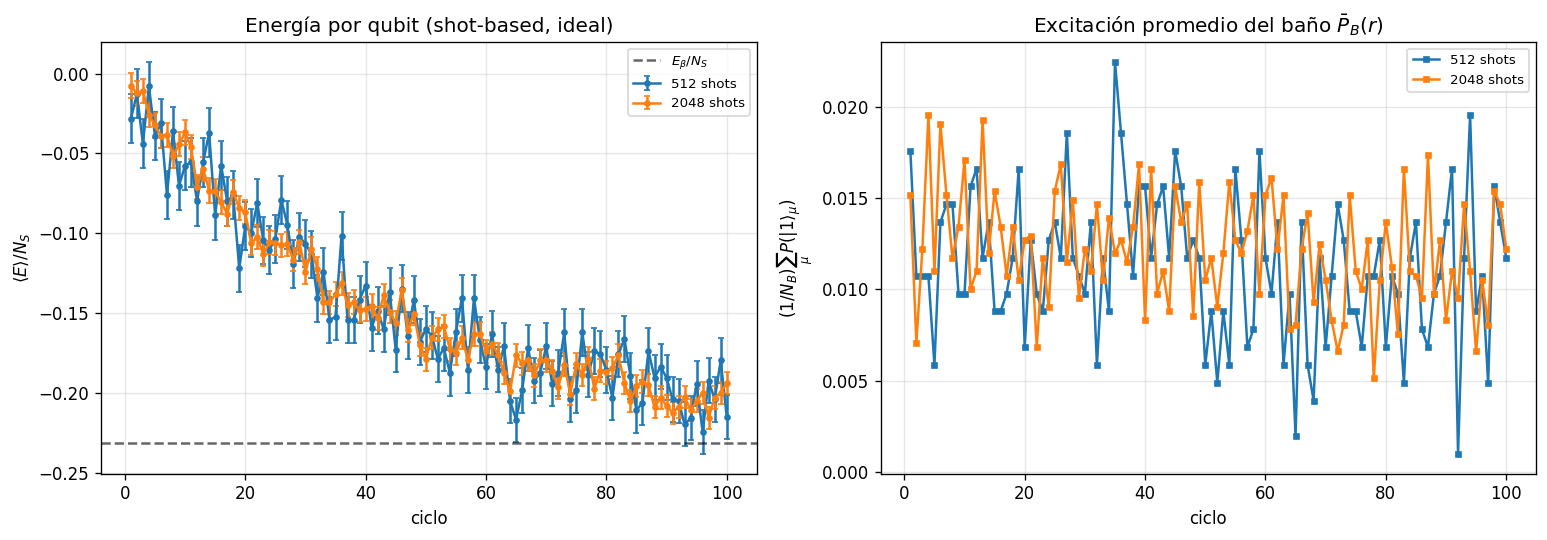

,cycle,E_final,E_sigma,bath_last,bath_agg_next_cycle,dE,pert_pred_dE
0,1,-0.015137,0.007811,0.011963,0.015137,NaN,-0.030273
1,2,-0.024902,0.007806,0.010742,0.007080,-0.009766,-0.014160
2,3,-0.021484,0.007810,0.012207,0.012207,0.003418,-0.024414
3,4,-0.051270,0.007800,0.016846,0.019531,-0.029785,-0.039062
4,5,-0.064941,0.007795,0.014160,0.010986,-0.013672,-0.021973
5,6,-0.078125,0.007789,0.017334,0.019043,-0.013184,-0.038086
6,7,-0.076660,0.007790,0.011230,0.015137,0.001465,-0.030273
7,8,-0.103516,0.007767,0.013672,0.011719,-0.026855,-0.023438


In [ ]:
# ============================================================
# C.2 — energía y baño agregado vs ciclos
#       versión larga opcional, ideal, dos presupuestos de shots
# ============================================================
#
# Aviso: max_cycles=100 puede ser pesado porque construye/simula circuitos
# dinámicos para muchos ciclos. Esta celda es demostrativa; para ejecución rápida
# usar una versión reducida con n_cycles=6-12.

c_params = dict(
    base_nonint_params,
    n_sys=2,          # mantener N_S=2 para estabilidad
    theta=0.20,
    MT=15,
    n_cycles=100,
    sys_A="Y",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    rewind=False,
)

_, compiled_C = make_compiled_nonint(c_params)

N_S_C = c_params["n_sys"]
max_cycles_C = c_params["n_cycles"]
shots_list_C = [512, 2048]

# Usamos el backend ISA común del notebook.
# Debe estar definido antes en C.0 con get_nonint_backend_bundle(...).
if "backend_bundle_NI" not in globals():
    backend_bundle_NI = get_nonint_backend_bundle(
        min_total_qubits=2 * N_S_C,
        force_refresh=False,
    )

backend_bundle_C = backend_bundle_NI

print(f"Backend C.2: {backend_bundle_C['label']}")
print(f"Noise model disponible: {backend_bundle_C['have_noise_model']}")
print("C.2 usa sim_mode='ideal'.")

energy_runs = {}
bath_runs = {}

for shots in shots_list_C:
    print(f"C.2 larga: shots={shots}", flush=True)

    df_E = run_energy_vs_cycles_shots_nonint(
        compiled_C,
        max_cycles=max_cycles_C,
        shots=shots,
        init_mode="mm",
        sim_mode="ideal",
        seed_base=2000 + shots,
        optimization_level=1,
        backend_bundle=backend_bundle_C,
    )

    # Señal del baño para todos los ciclos del circuito completo.
    # Es pesada, pero reproduce la estructura de la celda antigua.
    bath_full = run_isa_dynamic_shots_nonint(
        compiled_C,
        n_cycles=max_cycles_C,
        shots=shots,
        init_mode="mm",
        sim_mode="ideal",
        seed_base=3000 + shots,
        optimization_level=1,
        backend_bundle=backend_bundle_C,
    )

    energy_runs[shots] = df_E
    bath_runs[shots] = bath_full

rho_g = gibbs_state(compiled_C["Hs_mat"], c_params["beta"])
E_gibbs_C = float(np.real(np.trace(rho_g @ compiled_C["Hs_mat"])))

cycles_C = np.arange(1, max_cycles_C + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Energía por qubit
for shots in shots_list_C:
    df_ = energy_runs[shots]

    axes[0].errorbar(
        df_["cycle"],
        df_["E_final"] / N_S_C,
        yerr=1.96 * df_["E_sigma"] / N_S_C,
        fmt="o-",
        ms=3,
        capsize=2,
        lw=1.5,
        label=f"{shots} shots",
    )

axes[0].axhline(
    E_gibbs_C / N_S_C,
    ls="--",
    color="k",
    alpha=0.6,
    label=r"$E_\beta/N_S$",
)
axes[0].set_title("Energía por qubit (shot-based, ideal)")
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$\langle E\rangle/N_S$")
axes[0].legend(fontsize=8)

# Excitación agregada del baño
for shots in shots_list_C:
    bp1 = bath_runs[shots]["bath_p1_per_cycle"]

    axes[1].plot(
        cycles_C,
        bp1,
        "s-",
        ms=3,
        lw=1.5,
        label=f"{shots} shots",
    )

axes[1].set_title(r"Excitación promedio del baño $\overline{P}_B(r)$")
axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$(1/N_B)\sum_\mu P(|1\rangle_\mu)$")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

df_show = energy_runs[shots_list_C[-1]].copy()
df_show["bath_agg_next_cycle"] = bath_runs[shots_list_C[-1]]["bath_p1_per_cycle"]
df_show["dE"] = df_show["E_final"].diff()
df_show["pert_pred_dE"] = -c_params["h"] * c_params["n_sys"] * df_show["bath_agg_next_cycle"]

display(df_show.round(6).head(8))

Esta figura es la validación shot-based más directa. La energía por qubit se desplaza en la dirección correcta, aunque con fluctuaciones estadísticas visibles, y la excitación promedio del baño permanece pequeña pero resoluble.

## C.3 Tabla compacta: energía, baño y recursos

In [ ]:
# C.3 — Tabla compacta: energía Z, baño agregado y recursos

from tfm_nonint.model import (
    make_compiled_nonint,
    get_nonint_backend_bundle,
    get_isa_dynamic_circuit_nonint,
    run_isa_dynamic_shots_nonint,
)

from tfm_shared.core import gibbs_state, expect

shots_NI = 2048
n_cycles_NI = 8
MT_NI = 12
theta_NI = 0.25

rows_NI = []

for n_sys in [1, 2, 3]:
    p = dict(
        base_nonint_params,
        n_sys=n_sys,
        MT=MT_NI,
        theta=theta_NI,
        n_cycles=n_cycles_NI,
    )

    cfg, compiled = make_compiled_nonint(p)

    backend_bundle = get_nonint_backend_bundle(
        min_total_qubits=2 * n_sys,
    )

    out = run_isa_dynamic_shots_nonint(
        compiled,
        n_cycles=n_cycles_NI,
        shots=shots_NI,
        init_mode="mm",
        sim_mode="ideal",
        final_basis="Z",
        seed_base=1000 + n_sys,
        optimization_level=1,
        backend_bundle=backend_bundle,
    )

    qc_isa = get_isa_dynamic_circuit_nonint(
        compiled,
        n_cycles=n_cycles_NI,
        init_label="0" * n_sys,
        final_basis="Z",
        optimization_level=1,
        backend_bundle=backend_bundle,
    )
    ops = dict(qc_isa.count_ops())

    rho_g = gibbs_state(compiled["Hs_mat"], p["beta"])
    E_gibbs = expect(compiled["Hs_mat"], rho_g)

    rows_NI.append({
        "N_S": n_sys,
        "N_total_qubits": 2 * n_sys,
        "E_shots_final": out["E_final"],
        "E_sigma_1shot": out["E_sigma"],
        "E_Gibbs": E_gibbs,
        "|E_shots-E_Gibbs|": abs(out["E_final"] - E_gibbs),
        "bath_p1_last": float(out["bath_p1_per_cycle"][-1]),
        "bath_p1_mean": float(np.mean(out["bath_p1_per_cycle"])),
        "depth": qc_isa.depth(),
        "size": qc_isa.size(),
        "cx": ops.get("cx", 0),
        "ecr": ops.get("ecr", 0),
        "rz": ops.get("rz", 0),
        "sx": ops.get("sx", 0),
        "x": ops.get("x", 0),
        "measure": ops.get("measure", 0),
        "reset": ops.get("reset", 0),
        "backend": out["backend_label"],
    })

df_NI_qiskit_summary = pd.DataFrame(rows_NI)
display(df_NI_qiskit_summary)

,N_S,N_total_qubits,E_shots_final,E_sigma_1shot,E_Gibbs,|E_shots-E_Gibbs|,bath_p1_last,bath_p1_mean,depth,size,cx,ecr,rz,sx,x,measure,reset,backend
0,1,2,-0.067871,0.005473,-0.231059,0.163187,0.018555,0.021545,144,210,0,16,97,80,0,9,8,FakeSherbrooke (snapshot calibraciones reales)
1,2,4,-0.125488,0.007750,-0.462117,0.336629,0.025635,0.021545,7188,11642,0,1760,5555,4005,288,18,16,FakeSherbrooke (snapshot calibraciones reales)
2,3,6,-0.194824,0.009486,-0.693176,0.498352,0.020345,0.021220,133277,224937,0,34856,106970,78732,4328,27,24,FakeSherbrooke (snapshot calibraciones reales)


La tabla resume la validación shot-based para tamaños pequeños. No pretende optimizar la preparación, sino verificar que la lectura de energía, la señal agregada del baño y los recursos transpilados se comportan de forma consistente al pasar a $N_S>1$.

## C.4 Señal del baño por auxiliar

Además de la media $\bar P_B$, conviene mirar si todos los auxiliares se comportan igual. En el modelo no interactuante, por simetría, no debería aparecer un perfil espacial fuerte.

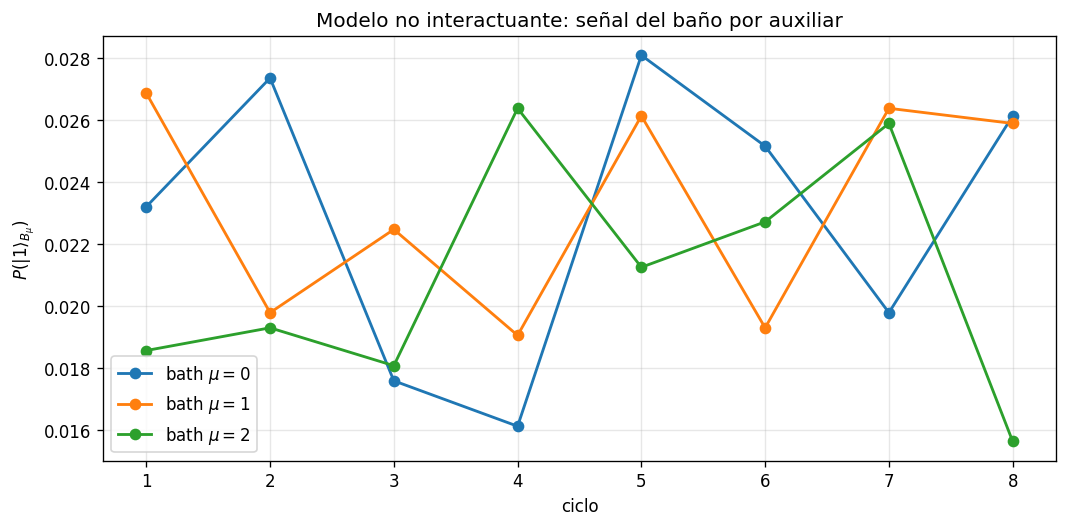

Varianza espacial media de P_B: 1.1940797170003254e-05


In [5]:
# C.X — Señal del baño por auxiliar para N_S=3

p = dict(
    base_nonint_params,
    n_sys=3,
    MT=MT_NI,
    theta=theta_NI,
    n_cycles=n_cycles_NI,
)

cfg, compiled = make_compiled_nonint(p)
backend_bundle = get_nonint_backend_bundle(min_total_qubits=2 * p["n_sys"])

out_aux = run_isa_dynamic_shots_nonint(
    compiled,
    n_cycles=n_cycles_NI,
    shots=4096,
    init_mode="mm",
    sim_mode="ideal",
    final_basis="Z",
    seed_base=2222,
    optimization_level=1,
    backend_bundle=backend_bundle,
)

bath_aux = out_aux["bath_p1_per_aux"]

fig, ax = plt.subplots(figsize=(9, 4.5))

for mu in range(bath_aux.shape[1]):
    ax.plot(
        np.arange(1, n_cycles_NI + 1),
        bath_aux[:, mu],
        marker="o",
        lw=1.7,
        label=fr"bath $\mu={mu}$",
    )

ax.set_xlabel("ciclo")
ax.set_ylabel(r"$P(|1\rangle_{B_\mu})$")
ax.set_title("Modelo no interactuante: señal del baño por auxiliar")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Varianza espacial media de P_B:",
      float(np.mean(np.var(bath_aux, axis=1))))

La señal $P(|1\rangle_{B_\mu})$ es pequeña pero homogénea entre auxiliares equivalentes. Esto confirma que la implementación no introduce un sesgo espacial artificial entre qubits independientes.

# D. Capa con ruido reducida

Esta sección reproduce de forma mínima la capa de ruido de NB01. No buscamos un mapa completo de robustez, sino un spot-check: comparar trayectorias ideal y noisy para confirmar que la señal térmica no desaparece de forma inesperada al pasar a $N_S>1$.

Usamos un tamaño pequeño, $N_S=2$, pocos ciclos y un número moderado de shots. El análisis detallado de ruido queda en NB01.

## D.1 Ideal vs ruido calibrado

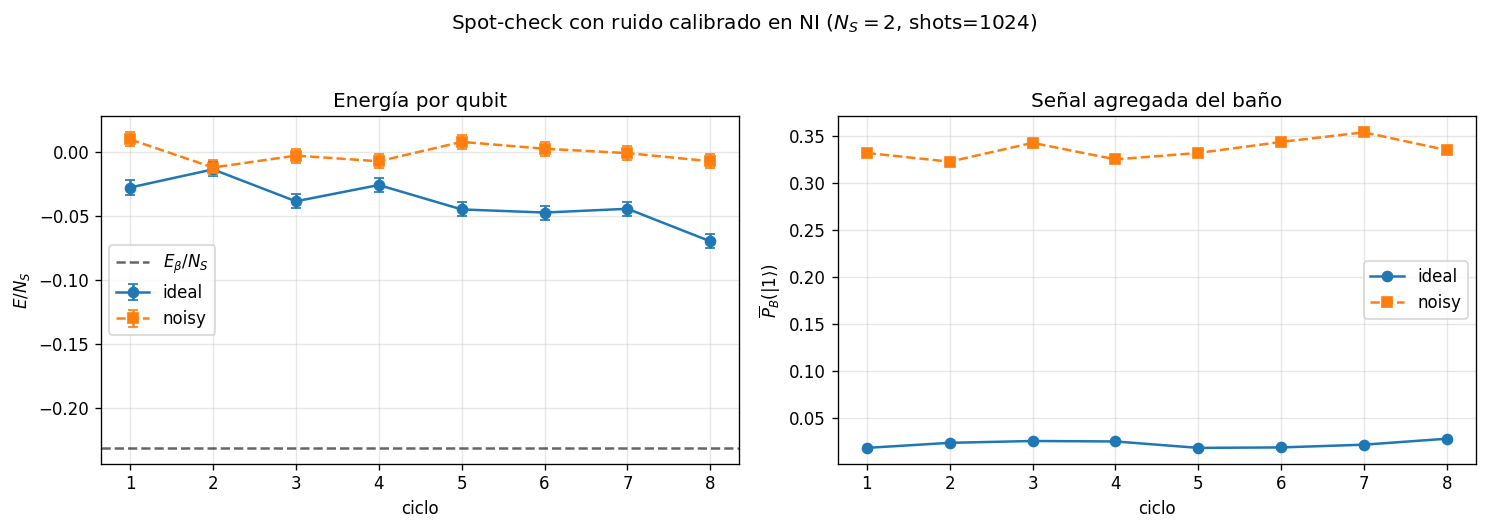

,modo,E_final_per_q,bath_last,abs_E_bias_per_q
0,ideal,-0.069824,0.027832,0.161234
1,noisy,-0.007324,0.334473,0.223734


In [5]:
# ============================================================
# D.1 — spot-check ideal vs ruido calibrado en NI
# ============================================================

N_S_D = 2
shots_D = 1024
max_cycles_D = 8

p_D = dict(
    base_nonint_params,
    n_sys=N_S_D,
    beta=1.0,
    theta=0.25,
    delta=0.08,
    MT=15,
    n_cycles=max_cycles_D,
    sys_A="ZYmix",
    bath_A="Y",
    randomize=False,
    randomization_lambda=0.0,
    rewind=False,
)

_, compiled_D = make_compiled_nonint(p_D)

backend_bundle_D = get_nonint_backend_bundle(
    min_total_qubits=2 * N_S_D,
)

rho_g_D = gibbs_state(compiled_D["Hs_mat"], p_D["beta"])
E_beta_D = float(np.real(np.trace(rho_g_D @ compiled_D["Hs_mat"])))
E_beta_per_q_D = E_beta_D / N_S_D

df_D_ideal = run_energy_vs_cycles_shots_nonint(
    compiled_D,
    max_cycles=max_cycles_D,
    shots=shots_D,
    init_mode="mm",
    sim_mode="ideal",
    seed_base=5000,
    backend_bundle=backend_bundle_D,
)

try:
    df_D_noisy = run_energy_vs_cycles_shots_nonint(
        compiled_D,
        max_cycles=max_cycles_D,
        shots=shots_D,
        init_mode="mm",
        sim_mode="noisy",
        seed_base=8000,
        backend_bundle=backend_bundle_D,
    )
except Exception as exc:
    df_D_noisy = None
    print("No se pudo ejecutar noisy; se muestra solo ideal.")
    print(type(exc).__name__, exc)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

axes[0].errorbar(
    df_D_ideal["cycle"],
    df_D_ideal["E_final"] / N_S_D,
    yerr=df_D_ideal["E_sigma"] / N_S_D,
    fmt="o-",
    capsize=3,
    label="ideal",
)

if df_D_noisy is not None:
    axes[0].errorbar(
        df_D_noisy["cycle"],
        df_D_noisy["E_final"] / N_S_D,
        yerr=df_D_noisy["E_sigma"] / N_S_D,
        fmt="s--",
        capsize=3,
        label="noisy",
    )

axes[0].axhline(
    E_beta_per_q_D,
    ls="--",
    color="k",
    alpha=0.6,
    label=r"$E_\beta/N_S$",
)
axes[0].set_xlabel("ciclo")
axes[0].set_ylabel(r"$E/N_S$")
axes[0].set_title("Energía por qubit")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    df_D_ideal["cycle"],
    df_D_ideal["bath_last"],
    "o-",
    label="ideal",
)

if df_D_noisy is not None:
    axes[1].plot(
        df_D_noisy["cycle"],
        df_D_noisy["bath_last"],
        "s--",
        label="noisy",
    )

axes[1].set_xlabel("ciclo")
axes[1].set_ylabel(r"$\overline{P}_B(|1\rangle)$")
axes[1].set_title("Señal agregada del baño")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(
    rf"Spot-check con ruido calibrado en NI ($N_S={N_S_D}$, shots={shots_D})",
    y=1.04,
)
plt.tight_layout()
plt.show()

if df_D_noisy is not None:
    display(
        pd.DataFrame({
            "modo": ["ideal", "noisy"],
            "E_final_per_q": [
                df_D_ideal["E_final"].iloc[-1] / N_S_D,
                df_D_noisy["E_final"].iloc[-1] / N_S_D,
            ],
            "bath_last": [
                df_D_ideal["bath_last"].iloc[-1],
                df_D_noisy["bath_last"].iloc[-1],
            ],
            "abs_E_bias_per_q": [
                abs(df_D_ideal["E_final"].iloc[-1] / N_S_D - E_beta_per_q_D),
                abs(df_D_noisy["E_final"].iloc[-1] / N_S_D - E_beta_per_q_D),
            ],
        }).round(6)
    )

El ruido calibrado degrada claramente la señal: la energía noisy deja de acercarse al valor térmico y la excitación medida en el baño aumenta de forma artificial. Esto no indica una nueva física del modelo NI, sino que, con circuitos dinámicos y resets, el ruido instrumental compite directamente con la señal térmica. El resultado cumple la función de D.1: mostrar que la capa con ruido se puede ejecutar y que el ruido empeora la preparación de forma cualitativamente esperada.

### D.2 Frontera NISQ con ruido del backend

Repetimos F.3 pero con `sim_mode="noisy"` (ruido calibrado del FakeSherbrooke). 
El ruido de puertas se acumula por cada CX aplicado, y dado que F.2 mostró 
que el número de CX crece con $N_S$, **el error por ruido crecerá con $N_S$**. 
A partir de cierto $N_S$, el ruido dominará sobre el sesgo del protocolo y 
perderemos la señal física.

Esta sección determina la **frontera NISQ** del protocolo: cuál es el $N_S$ 
máximo viable con el hardware simulado actual.


[D.2] N_S=1

[D.2] N_S=2

[D.2] N_S=3
  N_S=3 falló completamente: QiskitError: 'ERROR:  [Experiment 0] bad allocation ,  ERROR: bad allocation'


,N_S,mode,shots,max_cycles,MT,theta,E_final_per_q,E_beta_per_q,E_sigma_per_q,bias_per_q,bath_last,depth,cx,size,status
0,1,ideal,512,6,8,0.25,-0.027344,-0.231059,0.011032,0.203715,0.017578,108.0,0.0,158.0,ok
1,1,noisy,512,6,8,0.25,0.015625,-0.231059,0.011043,0.246684,0.046875,108.0,0.0,158.0,ok
2,2,ideal,512,6,8,0.25,-0.044922,-0.231059,0.007779,0.186137,0.020508,5439.0,0.0,8797.0,ok
3,2,noisy,512,6,8,0.25,0.003906,-0.231059,0.007812,0.234965,0.298828,5439.0,0.0,8797.0,ok
4,3,failed,512,6,8,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,failed: QiskitError


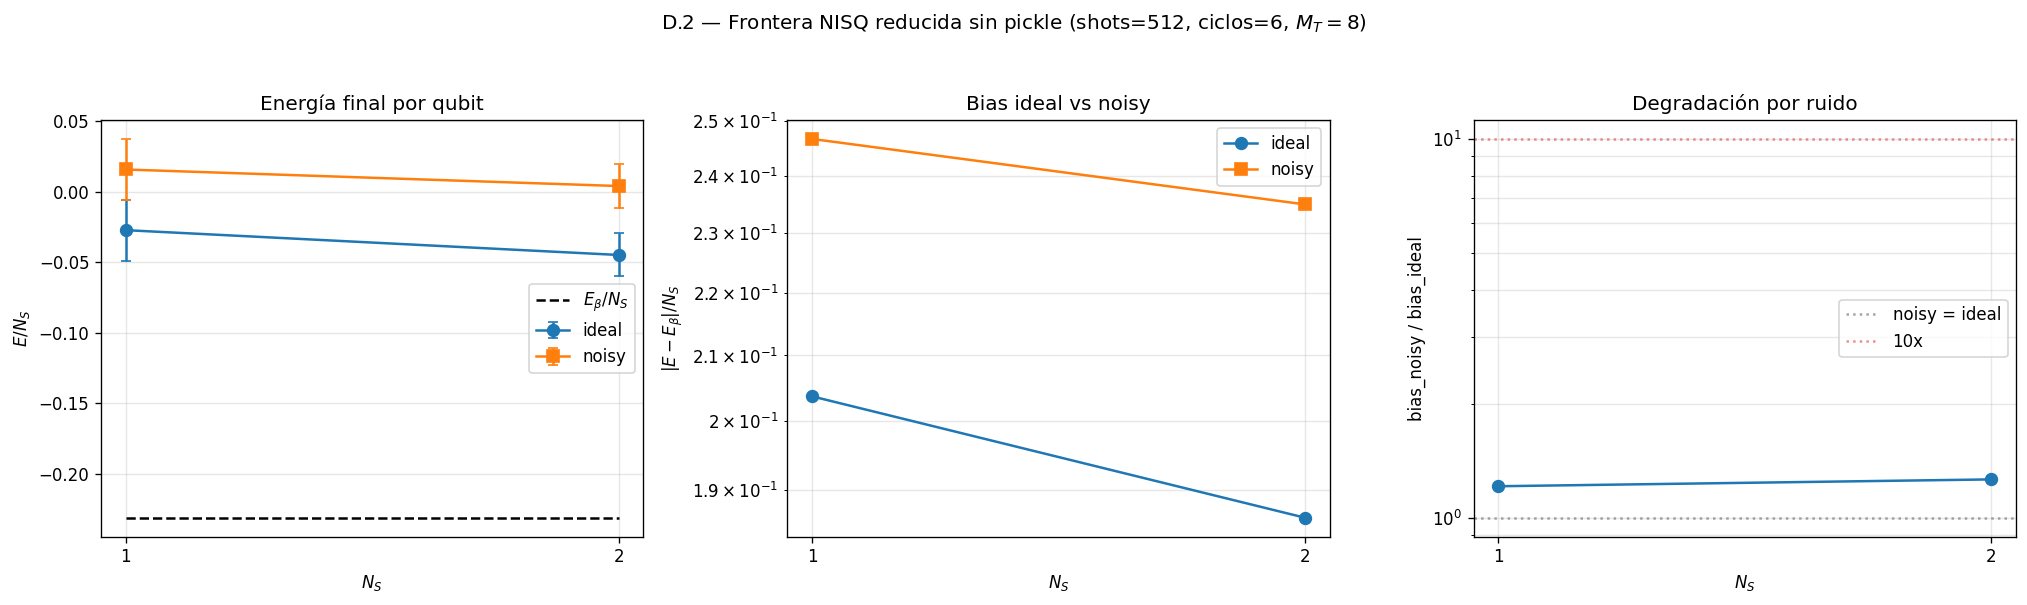

In [ ]:
# ============================================================
# D.2 — frontera NISQ reducida sin pickle
# ============================================================
#
# Objetivo:
#   Comparar ideal vs noisy para varios N_S pequeños, sin cargar datos externos.
#   Esto NO es un mapa exhaustivo: es un spot-check de escalado con ruido.
#
# Requisitos previos:
#   - base_nonint_params
#   - make_compiled_nonint
#   - get_nonint_backend_bundle
#   - run_energy_vs_cycles_shots_nonint
#   - get_isa_dynamic_circuit_nonint
#   - gibbs_state

N_S_list_D2 = [1, 2, 3]
shots_D2 = 512
max_cycles_D2 = 6
MT_D2 = 8
theta_D2 = 0.25

rows_D2 = []

for N_S in N_S_list_D2:
    print(f"\n[D.2] N_S={N_S}", flush=True)

    p_D2 = dict(
        base_nonint_params,
        n_sys=N_S,
        beta=1.0,
        theta=theta_D2,
        delta=0.08,
        MT=MT_D2,
        n_cycles=max_cycles_D2,
        sys_A="ZYmix",
        bath_A="Y",
        randomize=False,
        randomization_lambda=0.0,
        rewind=False,
    )

    try:
        _, compiled_D2 = make_compiled_nonint(p_D2)

        backend_bundle_D2 = backend_bundle_NI

        rho_g_D2 = gibbs_state(compiled_D2["Hs_mat"], p_D2["beta"])
        E_beta_D2 = float(np.real(np.trace(rho_g_D2 @ compiled_D2["Hs_mat"])))
        E_beta_per_q_D2 = E_beta_D2 / N_S

        # Recurso transpilado de una trayectoria representativa
        try:
            qc_isa_D2 = get_isa_dynamic_circuit_nonint(
                compiled_D2,
                n_cycles=max_cycles_D2,
                init_label="0" * N_S,
                final_basis="Z",
                optimization_level=1,
                backend_bundle=backend_bundle_D2,
            )
            depth_D2 = qc_isa_D2.depth()
            ops_D2 = qc_isa_D2.count_ops()
            cx_D2 = int(ops_D2.get("cx", 0))
            size_D2 = qc_isa_D2.size()
        except Exception as exc_resources:
            print(f"  Recursos no disponibles: {type(exc_resources).__name__}: {exc_resources}")
            depth_D2 = np.nan
            cx_D2 = np.nan
            size_D2 = np.nan

        # Ideal
        df_ideal_D2 = run_energy_vs_cycles_shots_nonint(
            compiled_D2,
            max_cycles=max_cycles_D2,
            shots=shots_D2,
            init_mode="mm",
            sim_mode="ideal",
            seed_base=10_000 + 100 * N_S,
            backend_bundle=backend_bundle_D2,
        )

        E_final_ideal = float(df_ideal_D2["E_final"].iloc[-1])
        E_sigma_ideal = float(df_ideal_D2["E_sigma"].iloc[-1])
        bath_last_ideal = float(df_ideal_D2["bath_last"].iloc[-1])
        bias_ideal_per_q = abs(E_final_ideal / N_S - E_beta_per_q_D2)

        rows_D2.append({
            "N_S": N_S,
            "mode": "ideal",
            "shots": shots_D2,
            "max_cycles": max_cycles_D2,
            "MT": MT_D2,
            "theta": theta_D2,
            "E_final_per_q": E_final_ideal / N_S,
            "E_beta_per_q": E_beta_per_q_D2,
            "E_sigma_per_q": E_sigma_ideal / N_S,
            "bias_per_q": bias_ideal_per_q,
            "bath_last": bath_last_ideal,
            "depth": depth_D2,
            "cx": cx_D2,
            "size": size_D2,
            "status": "ok",
        })

        # Noisy
        if backend_bundle_D2.get("have_noise_model", False):
            try:
                df_noisy_D2 = run_energy_vs_cycles_shots_nonint(
                    compiled_D2,
                    max_cycles=max_cycles_D2,
                    shots=shots_D2,
                    init_mode="mm",
                    sim_mode="noisy",
                    seed_base=20_000 + 100 * N_S,
                    backend_bundle=backend_bundle_D2,
                )

                E_final_noisy = float(df_noisy_D2["E_final"].iloc[-1])
                E_sigma_noisy = float(df_noisy_D2["E_sigma"].iloc[-1])
                bath_last_noisy = float(df_noisy_D2["bath_last"].iloc[-1])
                bias_noisy_per_q = abs(E_final_noisy / N_S - E_beta_per_q_D2)

                rows_D2.append({
                    "N_S": N_S,
                    "mode": "noisy",
                    "shots": shots_D2,
                    "max_cycles": max_cycles_D2,
                    "MT": MT_D2,
                    "theta": theta_D2,
                    "E_final_per_q": E_final_noisy / N_S,
                    "E_beta_per_q": E_beta_per_q_D2,
                    "E_sigma_per_q": E_sigma_noisy / N_S,
                    "bias_per_q": bias_noisy_per_q,
                    "bath_last": bath_last_noisy,
                    "depth": depth_D2,
                    "cx": cx_D2,
                    "size": size_D2,
                    "status": "ok",
                })

            except Exception as exc_noisy:
                print(f"  Noisy falló para N_S={N_S}: {type(exc_noisy).__name__}: {exc_noisy}")
                rows_D2.append({
                    "N_S": N_S,
                    "mode": "noisy",
                    "shots": shots_D2,
                    "max_cycles": max_cycles_D2,
                    "MT": MT_D2,
                    "theta": theta_D2,
                    "E_final_per_q": np.nan,
                    "E_beta_per_q": E_beta_per_q_D2,
                    "E_sigma_per_q": np.nan,
                    "bias_per_q": np.nan,
                    "bath_last": np.nan,
                    "depth": depth_D2,
                    "cx": cx_D2,
                    "size": size_D2,
                    "status": f"failed: {type(exc_noisy).__name__}",
                })
        else:
            print("  No hay noise model disponible; se omite noisy.")

    except Exception as exc:
        print(f"  N_S={N_S} falló completamente: {type(exc).__name__}: {exc}")
        rows_D2.append({
            "N_S": N_S,
            "mode": "failed",
            "shots": shots_D2,
            "max_cycles": max_cycles_D2,
            "MT": MT_D2,
            "theta": theta_D2,
            "E_final_per_q": np.nan,
            "E_beta_per_q": np.nan,
            "E_sigma_per_q": np.nan,
            "bias_per_q": np.nan,
            "bath_last": np.nan,
            "depth": np.nan,
            "cx": np.nan,
            "size": np.nan,
            "status": f"failed: {type(exc).__name__}",
        })

df_D2 = pd.DataFrame(rows_D2)
display(df_D2.round(6))

df_plot_D2 = df_D2[df_D2["mode"].isin(["ideal", "noisy"])].copy()

if len(df_plot_D2) == 0:
    print("No hay datos válidos para graficar.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    # Panel 1: energía por qubit
    for mode, marker in [("ideal", "o"), ("noisy", "s")]:
        sub = df_plot_D2[df_plot_D2["mode"] == mode]
        if len(sub) == 0:
            continue

        axes[0].errorbar(
            sub["N_S"],
            sub["E_final_per_q"],
            yerr=1.96 * sub["E_sigma_per_q"],
            fmt=f"{marker}-",
            ms=7,
            capsize=3,
            label=mode,
        )

    E_beta_by_N = (
        df_plot_D2.groupby("N_S")["E_beta_per_q"]
        .first()
        .sort_index()
    )
    axes[0].plot(
        E_beta_by_N.index,
        E_beta_by_N.values,
        "k--",
        label=r"$E_\beta/N_S$",
    )

    axes[0].set_xlabel(r"$N_S$")
    axes[0].set_ylabel(r"$E/N_S$")
    axes[0].set_title("Energía final por qubit")
    axes[0].set_xticks(sorted(df_plot_D2["N_S"].unique()))
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Panel 2: bias por qubit
    for mode, marker in [("ideal", "o"), ("noisy", "s")]:
        sub = df_plot_D2[df_plot_D2["mode"] == mode]
        if len(sub) == 0:
            continue

        axes[1].plot(
            sub["N_S"],
            sub["bias_per_q"],
            f"{marker}-",
            ms=7,
            label=mode,
        )

    axes[1].set_xlabel(r"$N_S$")
    axes[1].set_ylabel(r"$|E-E_\beta|/N_S$")
    axes[1].set_title("Bias ideal vs noisy")
    axes[1].set_yscale("log")
    axes[1].set_xticks(sorted(df_plot_D2["N_S"].unique()))
    axes[1].legend()
    axes[1].grid(alpha=0.3, which="both")

    # Panel 3: degradación noisy / ideal
    df_wide = (
        df_plot_D2
        .pivot_table(index="N_S", columns="mode", values="bias_per_q", aggfunc="first")
        .sort_index()
    )

    if {"ideal", "noisy"}.issubset(set(df_wide.columns)):
        ratio = df_wide["noisy"] / np.maximum(df_wide["ideal"], 1e-12)

        axes[2].plot(ratio.index, ratio.values, "o-", ms=7)
        axes[2].axhline(1, ls=":", color="gray", alpha=0.7, label="noisy = ideal")
        axes[2].axhline(10, ls=":", color="tab:red", alpha=0.5, label="10x")
        axes[2].set_yscale("log")
        axes[2].set_ylabel("bias_noisy / bias_ideal")
        axes[2].legend()
    else:
        axes[2].text(
            0.5,
            0.5,
            "No hay datos noisy\npara calcular ratio",
            ha="center",
            va="center",
            transform=axes[2].transAxes,
        )

    axes[2].set_xlabel(r"$N_S$")
    axes[2].set_title("Degradación por ruido")
    axes[2].set_xticks(sorted(df_plot_D2["N_S"].unique()))
    axes[2].grid(alpha=0.3, which="both")

    plt.suptitle(
        rf"D.2 — Frontera NISQ reducida sin pickle "
        rf"(shots={shots_D2}, ciclos={max_cycles_D2}, $M_T={MT_D2}$)",
        y=1.04,
    )
    plt.tight_layout()
    plt.show()

La frontera NISQ compara la preparación ideal y la preparación con ruido calibrado en los tamaños que pudieron simularse localmente. La lectura principal es la separación entre ambas curvas: cuando el bias noisy se separa del ideal, el ruido físico empieza a dominar sobre el sesgo intrínseco del protocolo.

El comportamiento esperado se mantiene: $E/N_S$ es intensivo, el bias ideal por qubit cambia poco con $N_S$, y el ruido aumenta la degradación al crecer el circuito. Esta sección queda como diagnóstico opcional porque depende de un barrido precomputado; el análisis principal de ruido reducido es D.1.

# E. Conclusiones del notebook

NB02 funciona como control no interactuante del protocolo. El Hamiltoniano factoriza, el Gibbs factoriza y el canal actúa qubit a qubit.

Los resultados principales son:

1. La capa exacta reproduce el Gibbs factorizado $\sigma_\beta = (\sigma_\beta^{(1)})^{\otimes N_S}$ con el mismo sesgo perturbativo observado en single spin.
2. La mutual information entre mitades permanece compatible con cero, confirmando que el protocolo no introduce correlaciones espurias en el modelo NI.
3. Las resonancias temporales y la dependencia con la ventana de evolución se heredan qubit a qubit de NB01.
4. La geometría del bath controla qué sitios thermalizan: sin interacciones internas, un sitio que no toca bath no puede enfriarse indirectamente.
5. La validación Qiskit ideal reproduce la evolución exacta a precisión numérica para $N_S>1$.
6. La capa shot-based ISA generaliza correctamente la mezcla inicial sobre $2^{N_S}$ bitstrings, la lectura del baño por auxiliar y la reconstrucción de la energía por qubit.
7. El ruido calibrado degrada la señal, pero no introduce física nueva: la diferencia ideal/noisy se interpreta como limitación instrumental, no como efecto colectivo.
8. La comparación exacta con Ising 1D muestra la frontera conceptual: al activar $J>0$, el Gibbs deja de factorizar y aparece mutual information física.

Este notebook fija el baseline para NB03. Cualquier correlación persistente, dependencia geométrica no trivial o relajación colectiva en Ising deberá atribuirse a las interacciones del Hamiltoniano, no al protocolo ni a la implementación Qiskit.